# Energy-Efficient Neural Networks via Adaptive Sparsification
## PAMAP2 Physical Activity Monitoring — Adaptive Sparse ResNet-1D (ASR-1D)

Pipeline: raw .dat files -> cleaning -> subject-wise split -> windowing ->
tf.data -> ASR-1D (learnable adaptive gates) vs Dense baseline -> training
with sparsity annealing -> evaluation (accuracy, macro-F1, FLOPs/param
savings, sparsity ratio, GPU inference latency).

Tested against TensorFlow 2.15+, RTX 3080 / RTX 5080 (mixed_float16).

Fully self-contained: point CFG.local_zip_path at a PAMAP2 zip you've
already downloaded and this script extracts it automatically (handles a
nested zip inside the outer zip too) and locates the Protocol/ (and
Optional/) folders on its own — no manual unzip/path-hunting needed. If no
local zip is found and CFG.auto_download=True, it fetches PAMAP2 from UCI
instead. Subsequent runs detect already-extracted files and skip all of this.

## Revision notes -- v2.1 (post-review, confirmatory rerun)

Changes from v2, made after checking the 3-seed run against the same standard applied to the PTB-XL notebook:

1. **Seeds 3 -> 5** in the confirmatory statistics cell (Module 7), matching the PTB-XL side's seed count.
2. **Static Pruning fine-tune budget raised** (12 -> 20 epochs, patience 4 -> 8) and a **per-seed collapse flag** added: if Static macro-F1 falls more than 15% below Dense at the same target ratio, the run is flagged instead of silently accepted. The original v2 single run showed Static F1=0.45 vs Dense F1=0.67 at the same 50% target ratio where other runs recovered to ~0.72-0.75 -- that swing needs to be explained or eliminated, not averaged over.
3. **Real GPU energy now measured per seed** (`measure_inference_energy`, reused from Module 1/2) for ASR, Dense, Static and the physically-pruned deploy model, instead of once on whichever models happened to be left in memory.
4. **A locked decision gate** at the end of Module 7, mirroring the PTB-XL notebook's final decision gate: Static is the primary (compute-matched) comparator, and the gate prints PASS/FAIL on accuracy, latency and energy plus a plain instruction for how to frame the result in the thesis -- so PAMAP2 gets the same audit trail PTB-XL already has, rather than a table with no stated interpretation rule.

Everything else (data loading, architecture, gate mechanism, sweep-based validation-only sparsity selection) is unchanged from v2. Run top to bottom in a fresh kernel; Module 7 is the slowest cell (5 full seeds x 4 models, each with an energy-measurement pass).

In [1]:
import sys
print(sys.executable)
import tensorflow as tf
print(tf.__version__)

/home/uswa/Downloads/Uswa/envs/pamap2/bin/python


I0000 00:00:1788523238.053704  201563 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


2.21.0


In [2]:
import os
import json
import glob
import time
import shutil
import zipfile
import copy
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.utils.class_weight import compute_class_weight
from dataclasses import dataclass, field
from typing import List, Tuple, Dict

In [3]:
# ===================================================================
# Module 10 (groundwork): IEEE publication-quality figure defaults.
# Applies globally to every plot in this notebook (existing AND new) — dpi, fonts, grid style.
# ===================================================================
plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.size": 10,
    "font.family": "serif",
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "legend.fontsize": 8,
    "lines.linewidth": 1.3,
    "axes.grid": True,
    "grid.alpha": 0.3,
})


## 0.1 Architecture note — what "adaptive" means in THIS notebook

**Read this before citing PAMAP2 results as validating the same ASR-1D architecture as PTB-XL.**

The `AdaptiveSparseGate` used here is a **learned, per-channel scalar gate**, trained jointly
with the task loss (`L = L_CE + λ·L_sparse`) and annealed from soft to (mostly) hard over
training. Once training finishes, each gate's value is **fixed** — every test input uses the
same set of active channels. This is a well-established technique in the structured-pruning
literature (comparable to Network Slimming / learned channel gating), and it IS genuinely
"adaptive" in the sense that the *network decides for itself, during training, which channels
to keep* — no manual pruning rule is imposed.

It is **not** the same as *input-conditional* adaptivity (e.g. a `DifficultyEstimator`
sub-network that changes how much compute a specific test sample gets, at inference time,
based on that sample's estimated difficulty). If the PTB-XL side of the thesis implements that
stronger, per-input form of adaptivity, this PAMAP2 pipeline should be described as validating
the **channel-sparsification mechanism and the joint-loss training strategy** on a second
dataset — not as a like-for-like replication of a DifficultyEstimator-based architecture.
State this distinction explicitly in the thesis methodology/limitations section to avoid an
avoidable challenge in the viva.

This notebook also runs a proper **three-way comparison** — Dense vs Static Pruning (one-shot
magnitude pruning, no learned gate — Section 10.7) vs ASR-1D (Section 6-10.6) — matching the
comparison structure described for PTB-XL, at a matched compression ratio between Static and
ASR-1D so the two pruning strategies are compared fairly.

## 0. Config

In [4]:
@dataclass
class Config:
    local_zip_path: str = os.path.expanduser("~/Downloads/pamap2+physical+activity+monitoring (1).zip")
    auto_download: bool = False                            # True only if you want it fetched from UCI instead
    download_root: str = "./pamap2_raw"                    # where the zip gets extracted to
    data_dir: str = "./pamap2_raw/PAMAP2_Dataset/Protocol"  # folder with subjectXXX.dat (auto-resolved after extraction)
    include_optional_dir: str = None                      # e.g. ".../PAMAP2_Dataset/Optional" or None (auto-resolved)
    subjects_all: List[int] = field(default_factory=lambda: [101,102,103,104,105,106,107,108,109])
    test_subjects: List[int] = field(default_factory=lambda: [105, 106])   # held-out test subjects
    val_subjects: List[int] = field(default_factory=lambda: [107, 108])    # 2 subjects -> less noisy val signal
    window_size: int = 200        # 2.0s @ 100Hz
    stride: int = 100             # 50% overlap
    min_label_purity: float = 0.8 # window kept only if dominant label covers >=80% of samples
    drop_activity_ids: Tuple[int, ...] = (0,)   # 0 = transient, always dropped
    min_samples_per_activity: int = 200         # drop only genuinely negligible classes (post-window count)
    batch_size: int = 128
    epochs: int = 60
    base_filters: int = 32
    num_blocks: Tuple[int, ...] = (2, 2, 2, 2)
    lr: float = 1e-3
    weight_decay: float = 5e-4            # bumped up from 1e-4 - train hit 99% acc in 2 epochs, needs more regularization
    dropout_conv: float = 0.2             # SpatialDropout1D inside residual blocks (both models, fair comparison)
    dropout_head: float = 0.5             # classifier head dropout (was 0.3)
    use_augmentation: bool = True         # jitter/scale/shift augmentation on train windows only
    jitter_std: float = 0.03              # gaussian noise std (data is z-normalized, so this is in std-units)
    scale_range: Tuple[float, float] = (0.9, 1.1)
    sparsity_lambda_max: float = 2e-2     # raised from 3e-3 — combined with the weight-decay-exclusion
                                           # fix in compile_model(), this gives the sparsity penalty a real
                                           # chance to move gate logits (previously logits never moved off
                                           # their neutral start across 3 separate runs: 0.0% learned sparsity
                                           # every time). Re-check gate value std after training; if gates
                                           # are still ~0.5 everywhere, raise this further (e.g. 5e-2).
    sparsity_anneal_epochs: int = 15      # gates fully anneal by this epoch REGARDLESS of cfg.epochs / early stopping
    gate_logit_init: float = 0.0          # neutral start (gate~=0.5) so penalty and task loss can genuinely compete
    gate_temp_start: float = 4.0          # softer start than before (was 2.0)
    gate_temp_end: float = 0.15           # lowered from 0.5 — sharper end-of-training gate decisions
                                           # instead of leaving gates soft/undecided
    prune_sweep_levels: Tuple[float, ...] = (0.1, 0.2, 0.3, 0.4, 0.5)  # hard-prune ratios to evaluate post-training
    static_prune_fallback_ratio: float = 0.3   # used for the Static Pruning baseline if ASR-1D's sweep
                                                # didn't accept any level (so there's no "chosen" ratio to match)
    finetune_lr: float = 1e-4             # lower LR for post-prune fine-tuning (recovers most of the accuracy drop)
    finetune_epochs: int = 20             # raised from 12 (v2.1) -- the 12-epoch budget let one
                                           # confirmatory run's Static Pruning baseline stop before
                                           # recovering (macro F1 0.45 vs ~0.72-0.75 in other runs at
                                           # the same target ratio); more budget + more patience
                                           # reduces the chance of reporting an under-recovered fluke.
    finetune_patience: int = 8            # raised from a hardcoded 4 in build_static_pruning_baseline
    static_collapse_relative_drop: float = 0.15  # if Static macro-F1 falls more than this fraction
                                           # below Dense macro-F1, flag the run instead of silently
                                           # accepting a possibly under-recovered baseline
    checkpoint_dir: str = "./checkpoints"
    early_stop_patience: int = 15
    seed: int = 42

CFG = Config()
np.random.seed(CFG.seed)
tf.random.set_seed(CFG.seed)

# Mixed precision for RTX 3080 / 5080 tensor cores
keras.mixed_precision.set_global_policy("mixed_float16")

gpus = tf.config.list_physical_devices("GPU")
for g in gpus:
    tf.config.experimental.set_memory_growth(g, True)
print("GPUs visible:", gpus)

GPUs visible: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


## 1. Raw PAMAP2 loading

Column layout per PAMAP2 documentation (54 columns per row):
0 timestamp | 1 activityID | 2 heart_rate |
3-19  hand IMU (17 cols)  | 20-36 chest IMU (17 cols) | 37-53 ankle IMU (17 cols)
Each 17-col IMU block = temp(1), acc16(3), acc6(3), gyro(3), mag(3), orientation(4, INVALID - always drop)

In [5]:
IMU_SENSOR_COLS = ["temp", "acc16_x", "acc16_y", "acc16_z",
                    "acc6_x", "acc6_y", "acc6_z",
                    "gyro_x", "gyro_y", "gyro_z",
                    "mag_x", "mag_y", "mag_z",
                    "orient_a", "orient_b", "orient_c", "orient_d"]

def _build_column_names() -> List[str]:
    cols = ["timestamp", "activity_id", "heart_rate"]
    for loc in ["hand", "chest", "ankle"]:
        cols += [f"{loc}_{c}" for c in IMU_SENSOR_COLS]
    assert len(cols) == 54
    return cols

COLUMN_NAMES = _build_column_names()

# Columns we actually keep as model input features (drop orientation - invalid/unused, per PAMAP2 docs)
FEATURE_COLS = ["heart_rate"] + [
    f"{loc}_{c}" for loc in ["hand", "chest", "ankle"]
    for c in IMU_SENSOR_COLS if not c.startswith("orient")
]  # 1 + 3*13 = 40 channels

ACTIVITY_NAMES = {
    1: "lying", 2: "sitting", 3: "standing", 4: "walking", 5: "running",
    6: "cycling", 7: "nordic_walking", 9: "watching_tv", 10: "computer_work",
    11: "car_driving", 12: "ascending_stairs", 13: "descending_stairs",
    16: "vacuum_cleaning", 17: "ironing", 18: "folding_laundry",
    19: "house_cleaning", 20: "playing_soccer", 24: "rope_jumping",
}


def _download_progress_hook(count, block_size, total_size):
    downloaded = count * block_size
    pct = min(100, downloaded * 100 / total_size) if total_size > 0 else 0
    mb_done = downloaded / (1024 * 1024)
    mb_total = total_size / (1024 * 1024) if total_size > 0 else 0
    print(f"\rDownloading PAMAP2: {pct:5.1f}%  ({mb_done:6.1f} / {mb_total:6.1f} MB)", end="", flush=True)


# UCI has moved hosting paths over the years; try each mirror in order.
PAMAP2_URLS = [
    "https://archive.ics.uci.edu/static/public/231/pamap2+physical+activity+monitoring.zip",
    "http://archive.ics.uci.edu/ml/machine-learning-databases/00231/PAMAP2_Dataset.zip",
    "https://archive.ics.uci.edu/ml/machine-learning-databases/00231/PAMAP2_Dataset.zip",
]


def _extract_zip_recursive(zip_path: str, extract_to: str):
    """Extracts a zip, and if the extracted contents themselves contain another .zip
    (some UCI mirrors nest PAMAP2_Dataset.zip inside the outer download), extracts that too."""
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(extract_to)
    nested_zips = glob.glob(os.path.join(extract_to, "**", "*.zip"), recursive=True)
    for nz in nested_zips:
        print(f"Found nested zip {nz}, extracting...")
        with zipfile.ZipFile(nz, "r") as zf:
            zf.extractall(os.path.dirname(nz))


def _resolve_protocol_dir(root: str, cfg: "Config") -> bool:
    """Searches under `root` for a 'Protocol' folder containing subject*.dat and, if found,
    updates cfg.data_dir (and cfg.include_optional_dir) in place. Returns True if found."""
    candidates = [
        d for d in glob.glob(os.path.join(root, "**", "Protocol"), recursive=True)
        if glob.glob(os.path.join(d, "subject*.dat"))
    ]
    if not candidates:
        return False
    cfg.data_dir = candidates[0]
    optional_candidates = glob.glob(os.path.join(root, "**", "Optional"), recursive=True)
    if optional_candidates and cfg.include_optional_dir is None:
        cfg.include_optional_dir = optional_candidates[0]
    return True


def ensure_pamap2_ready(cfg: "Config") -> None:
    """Makes sure cfg.data_dir points at a real 'Protocol' folder with subjectXXX.dat files.
    Resolution order:
      1) cfg.data_dir already has the files -> no-op
      2) cfg.local_zip_path exists on disk -> extract it (handles a zip you already downloaded)
      3) cfg.auto_download=True -> fetch PAMAP2 from UCI mirrors, then extract
      4) otherwise -> raise a clear error
    """
    if glob.glob(os.path.join(cfg.data_dir, "subject*.dat")):
        print(f"Found existing PAMAP2 data at {cfg.data_dir}, using it directly.")
        return

    # --- Option 2: extract a zip the user already downloaded locally ---
    if cfg.local_zip_path and os.path.exists(cfg.local_zip_path):
        print(f"Found local zip at {cfg.local_zip_path}, extracting...")
        os.makedirs(cfg.download_root, exist_ok=True)
        _extract_zip_recursive(cfg.local_zip_path, cfg.download_root)
        if _resolve_protocol_dir(cfg.download_root, cfg):
            print(f"PAMAP2 ready at: {cfg.data_dir}")
            if cfg.include_optional_dir:
                print(f"Optional activities data at: {cfg.include_optional_dir}")
            return
        raise FileNotFoundError(
            f"Extracted {cfg.local_zip_path} into {cfg.download_root} but couldn't find a "
            f"'Protocol' folder with subject*.dat files inside. Please check the extracted "
            f"contents under {cfg.download_root} and set cfg.data_dir manually."
        )

    # --- Option 3: download from UCI ---
    if not cfg.auto_download:
        raise FileNotFoundError(
            f"No data at {cfg.data_dir}, no local zip found at {cfg.local_zip_path}, and "
            f"auto_download=False. Either fix cfg.local_zip_path to point at your downloaded "
            f"zip, or set cfg.auto_download=True, or download manually from "
            f"https://archive.ics.uci.edu/dataset/231/pamap2+physical+activity+monitoring"
        )

    os.makedirs(cfg.download_root, exist_ok=True)
    zip_path = os.path.join(cfg.download_root, "PAMAP2_Dataset.zip")

    if not os.path.exists(zip_path):
        last_err = None
        for url in PAMAP2_URLS:
            try:
                print(f"Fetching {url}")
                urllib.request.urlretrieve(url, zip_path, reporthook=_download_progress_hook)
                print()  # newline after progress bar
                break
            except Exception as e:
                last_err = e
                print(f"\n[warn] failed from {url}: {e}")
                if os.path.exists(zip_path):
                    os.remove(zip_path)
        else:
            raise RuntimeError(
                f"Could not download PAMAP2 from any mirror. Last error: {last_err}\n"
                f"Please download manually from "
                f"https://archive.ics.uci.edu/dataset/231/pamap2+physical+activity+monitoring "
                f"and unzip it into {cfg.download_root}"
            )
    else:
        print(f"Zip already present at {zip_path}, skipping re-download.")

    print("Extracting...")
    _extract_zip_recursive(zip_path, cfg.download_root)

    if not _resolve_protocol_dir(cfg.download_root, cfg):
        raise FileNotFoundError(
            f"Extracted PAMAP2 but couldn't locate a 'Protocol' folder under {cfg.download_root}. "
            f"Check the extracted contents manually."
        )

    print(f"PAMAP2 ready at: {cfg.data_dir}")
    if cfg.include_optional_dir:
        print(f"Optional activities data at: {cfg.include_optional_dir}")


def load_subject_file(path: str) -> pd.DataFrame:
    df = pd.read_csv(path, sep=r"\s+", header=None, names=COLUMN_NAMES)
    subject_id = int(os.path.basename(path).replace("subject", "").replace(".dat", ""))
    df["subject_id"] = subject_id
    return df


def load_all_subjects(cfg: Config) -> pd.DataFrame:
    frames = []
    found_subjects = []
    for sid in cfg.subjects_all:
        p = os.path.join(cfg.data_dir, f"subject{sid}.dat")
        if os.path.exists(p):
            frames.append(load_subject_file(p))
            found_subjects.append(sid)
        else:
            print(f"[warn] missing {p}, skipping")
        if cfg.include_optional_dir:
            p_opt = os.path.join(cfg.include_optional_dir, f"subject{sid}.dat")
            if os.path.exists(p_opt):
                frames.append(load_subject_file(p_opt))
    if not frames:
        raise FileNotFoundError(
            f"No PAMAP2 .dat files found in {cfg.data_dir}. "
            f"Download from https://archive.ics.uci.edu/dataset/231 and unzip so that "
            f"subjectXXX.dat files sit inside that folder."
        )
    print(f"Subject files found: {found_subjects}")
    missing = sorted(set(cfg.subjects_all) - set(found_subjects))
    if missing:
        print(f"Subject files MISSING: {missing}")
    df = pd.concat(frames, ignore_index=True)
    return df

## 2. Cleaning
- drop activity_id == 0 (transient / unlabeled)
- heart rate sampled at ~9Hz -> forward/backward fill then linear-interpolate to align with 100Hz IMU
- orientation columns already excluded via FEATURE_COLS
- drop rows with any remaining NaNs in the IMU columns (sensor dropout)

In [6]:
def clean_dataframe(df: pd.DataFrame, cfg: Config) -> pd.DataFrame:
    df = df[~df["activity_id"].isin(cfg.drop_activity_ids)].copy()
    df = df.sort_values(["subject_id", "timestamp"]).reset_index(drop=True)

    # heart rate: interpolate per-subject (it's the only irregularly sampled channel)
    df["heart_rate"] = (
        df.groupby("subject_id")["heart_rate"]
        .apply(lambda s: s.interpolate(method="linear", limit_direction="both"))
        .reset_index(level=0, drop=True)
    )

    # drop rows where IMU sensors have NaN dropout (small fraction typically)
    imu_check_cols = [c for c in FEATURE_COLS if c != "heart_rate"]
    df = df.dropna(subset=imu_check_cols).reset_index(drop=True)
    df["heart_rate"] = df["heart_rate"].fillna(df["heart_rate"].mean())

    return df

## 3. Subject-wise windowing (sliding window + majority-vote labeling)
Splitting by subject (not randomly) avoids leakage between train/val/test —
critical since consecutive samples from the same subject are highly correlated.

In [7]:
def make_windows_for_subject(sub_df: pd.DataFrame, cfg: Config):
    feats = sub_df[FEATURE_COLS].to_numpy(dtype=np.float32)
    labels = sub_df["activity_id"].to_numpy()
    n = len(sub_df)
    X, y = [], []
    for start in range(0, n - cfg.window_size + 1, cfg.stride):
        end = start + cfg.window_size
        window_labels = labels[start:end]
        vals, counts = np.unique(window_labels, return_counts=True)
        dominant_idx = np.argmax(counts)
        purity = counts[dominant_idx] / cfg.window_size
        if purity >= cfg.min_label_purity:
            X.append(feats[start:end])
            y.append(vals[dominant_idx])
    return X, y


def build_windowed_dataset(df: pd.DataFrame, cfg: Config):
    X_all, y_all, g_all = [], [], []
    for sid, sub_df in df.groupby("subject_id"):
        Xs, ys = make_windows_for_subject(sub_df, cfg)
        X_all.extend(Xs)
        y_all.extend(ys)
        g_all.extend([sid] * len(Xs))
    X = np.stack(X_all).astype(np.float32)          # (N, window, C)
    y = np.array(y_all)
    groups = np.array(g_all)
    return X, y, groups

## 4. Label remapping + subject-wise split + per-channel normalization
Normalization stats computed on TRAIN split only, applied to val/test — avoids leakage.

In [8]:
def remap_labels(y: np.ndarray, min_count: int):
    vals, counts = np.unique(y, return_counts=True)
    print("Window counts per raw activity_id before filtering:")
    for v, c in sorted(zip(vals, counts), key=lambda t: -t[1]):
        name = ACTIVITY_NAMES.get(int(v), str(v))
        flag = "" if c >= min_count else "  <-- BELOW min_samples_per_activity, will be DROPPED"
        print(f"  activity_id={v:>3} ({name:<18}): {c:>6} windows{flag}")
    keep = vals[counts >= min_count]
    mask = np.isin(y, keep)
    label2idx = {v: i for i, v in enumerate(sorted(keep))}
    y_mapped = np.array([label2idx[v] for v in y[mask]])
    idx2name = {i: ACTIVITY_NAMES.get(v, str(v)) for v, i in label2idx.items()}
    return mask, y_mapped, label2idx, idx2name


def subject_split(X, y, groups, cfg: Config):
    present_subjects = sorted(set(groups.tolist()))
    print(f"Subjects present after windowing/label filtering: {present_subjects}")

    test_mask = np.isin(groups, cfg.test_subjects)
    val_mask = np.isin(groups, cfg.val_subjects)
    train_mask = ~(test_mask | val_mask)

    n_train, n_val, n_test = train_mask.sum(), val_mask.sum(), test_mask.sum()
    print(f"Split sizes -> train: {n_train}, val: {n_val}, test: {n_test}")

    if n_train == 0:
        train_subjects_expected = sorted(set(cfg.subjects_all) - set(cfg.test_subjects) - set(cfg.val_subjects))
        raise ValueError(
            f"Train split is EMPTY. Expected train subjects {train_subjects_expected}, but only these "
            f"subjects are present in the data: {present_subjects}. This usually means some subjectXXX.dat "
            f"files are missing from cfg.data_dir (check the 'MISSING' warning above), or cfg.test_subjects/"
            f"cfg.val_subjects overlap with all the subjects you actually have. Fix by either adding the "
            f"missing .dat files, or adjusting cfg.test_subjects / cfg.val_subjects to subjects that are "
            f"NOT in {present_subjects} minus the ones you want held out."
        )
    if n_val == 0:
        print("[warn] Val split is empty — training will proceed but validation metrics/callbacks (EarlyStopping, "
              "ReduceLROnPlateau, ModelCheckpoint on val_acc) will fail. Consider adjusting cfg.val_subjects.")
    if n_test == 0:
        print("[warn] Test split is empty — final evaluation will fail. Consider adjusting cfg.test_subjects.")

    return (X[train_mask], y[train_mask]), (X[val_mask], y[val_mask]), (X[test_mask], y[test_mask])


def normalize_channels(X_train, X_val, X_test):
    mean = X_train.reshape(-1, X_train.shape[-1]).mean(axis=0)
    std = X_train.reshape(-1, X_train.shape[-1]).std(axis=0) + 1e-8
    norm = lambda X: (X - mean) / std
    return norm(X_train), norm(X_val), norm(X_test), mean, std

## 5. Full data prep entry point

In [9]:
def prepare_pamap2(cfg: Config):
    ensure_pamap2_ready(cfg)   # a-to-z: extracts local zip (or downloads) if not already local

    print("Loading raw subject files...")
    raw = load_all_subjects(cfg)
    print(f"Raw rows: {len(raw):,}  subjects: {raw['subject_id'].nunique()}")

    present_subjects = sorted(raw["subject_id"].unique().tolist())
    configured_holdout = set(cfg.test_subjects) | set(cfg.val_subjects)
    if not configured_holdout.issubset(present_subjects):
        missing_holdout = sorted(configured_holdout - set(present_subjects))
        print(f"[warn] configured test/val subjects {missing_holdout} are not present in the data "
              f"({present_subjects}). Auto-selecting hold-out subjects from what's available instead.")
        if len(present_subjects) >= 3:
            cfg.test_subjects = present_subjects[-2:]
            cfg.val_subjects = [present_subjects[-3]]
        elif len(present_subjects) == 2:
            cfg.test_subjects = [present_subjects[-1]]
            cfg.val_subjects = [present_subjects[-1]]  # degenerate but keeps pipeline running
        else:
            raise ValueError(
                f"Only {len(present_subjects)} subject(s) present ({present_subjects}) — need at least 3 "
                f"distinct subjects for a train/val/test subject-wise split. Please check your PAMAP2 zip; "
                f"it should contain 9 subjects (101-109)."
            )
        print(f"Using test_subjects={cfg.test_subjects}, val_subjects={cfg.val_subjects}, "
              f"train_subjects={sorted(set(present_subjects) - set(cfg.test_subjects) - set(cfg.val_subjects))}")

    clean = clean_dataframe(raw, cfg)
    print(f"After cleaning: {len(clean):,} rows")

    X, y_raw, groups = build_windowed_dataset(clean, cfg)
    print(f"Windows built: {X.shape}")

    mask, y_mapped_all, label2idx, idx2name = remap_labels(y_raw, cfg.min_samples_per_activity)
    X, groups = X[mask], groups[mask]
    y = y_mapped_all
    print(f"Kept {len(label2idx)} activity classes: {idx2name}")

    (Xtr, ytr), (Xval, yval), (Xte, yte) = subject_split(X, y, groups, cfg)
    Xtr, Xval, Xte, mean, std = normalize_channels(Xtr, Xval, Xte)

    print(f"Train: {Xtr.shape}  Val: {Xval.shape}  Test: {Xte.shape}")
    return (Xtr, ytr), (Xval, yval), (Xte, yte), label2idx, idx2name


def augment_window(x, y, cfg: Config):
    # Gaussian jitter (sensor noise) - data is already z-normalized so std-units apply directly
    x = x + tf.random.normal(tf.shape(x), stddev=cfg.jitter_std, dtype=x.dtype)
    # Random per-window magnitude scaling (simulates sensor gain / placement variation)
    scale = tf.random.uniform([], cfg.scale_range[0], cfg.scale_range[1], dtype=x.dtype)
    x = x * scale
    return x, y


def make_tf_dataset(X, y, cfg: Config, training: bool):
    ds = tf.data.Dataset.from_tensor_slices((X, y))
    if training:
        ds = ds.shuffle(buffer_size=min(len(X), 20000), seed=cfg.seed, reshuffle_each_iteration=True)
        if cfg.use_augmentation:
            ds = ds.map(lambda x, y: augment_window(x, y, cfg), num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(cfg.batch_size)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

## 6. Adaptive Sparse Gate — the core "adaptive sparsification" mechanism

Each gate learns one importance logit per channel. During the forward pass
it's turned into a soft mask via a temperature-controlled sigmoid
(annealed hard over training, like Gumbel-Sigmoid / concrete dropout), so
gates start soft/differentiable and gradually become near-binary —
channels the network doesn't need get pushed toward zero and can be
physically pruned at inference. An L1 penalty on the mask values drives
sparsity; the penalty weight itself is annealed up over training
(`sparsity_lambda` schedule) so the network first learns to classify, then
is pushed toward sparsity, rather than being sparsified prematurely.

In [10]:
class AdaptiveSparseGate(layers.Layer):
    def __init__(self, channels: int, name=None, logit_init: float = 0.0):
        super().__init__(name=name)
        self.channels = channels
        self.logit_init = logit_init
        self.temperature = tf.Variable(2.0, trainable=False, dtype=tf.float32, name="gate_temp")
        self.sparsity_lambda = tf.Variable(0.0, trainable=False, dtype=tf.float32, name="sparsity_lambda")

    def build(self, input_shape):
        # NOTE: previously initialized at +2.0 ("heavily open"). Once temperature anneals down,
        # sigmoid(logit/temp) saturates near 1.0 and its gradient vanishes there — so gates that
        # started open could never be pushed closed, regardless of how long training ran. Starting
        # at 0.0 (gate ~= 0.5, genuinely undecided) lets the sparsity penalty and the classification
        # loss actually compete to decide which channels matter.
        self.logits = self.add_weight(
            shape=(self.channels,), initializer=keras.initializers.Constant(self.logit_init),
            trainable=True, name="gate_logits"
        )

    def call(self, x, training=None):
        logits_f32 = tf.cast(self.logits, tf.float32)
        gate = tf.sigmoid(logits_f32 / self.temperature)          # (C,) in [0,1]
        self.add_loss(self.sparsity_lambda * tf.reduce_mean(gate))  # L1-style sparsity pressure
        gate = tf.cast(gate, x.dtype)
        return x * gate[tf.newaxis, tf.newaxis, :]

    def current_gate_values(self, temperature=None):
        temp = self.temperature if temperature is None else tf.cast(temperature, tf.float32)
        return tf.sigmoid(tf.cast(self.logits, tf.float32) / temp).numpy()

    def hard_prune(self, keep_mask: np.ndarray):
        """Permanently zero out (via a large negative logit) the channels where keep_mask is False.
        Reversible only by re-running training; used for the post-hoc sparsity sweep."""
        current = self.logits.numpy().copy()
        current[~keep_mask] = -30.0  # sigmoid(-30/temp) ~= 0 for any reasonable temp
        self.logits.assign(current)

    def set_logits(self, values: np.ndarray):
        self.logits.assign(values)


class GateScheduleCallback(keras.callbacks.Callback):
    """Anneals gate temperature (soft->hard) and sparsity penalty (0->max) over a FIXED number of
    epochs (cfg.sparsity_anneal_epochs), independent of cfg.epochs or early stopping. Previously this
    was scaled by epoch/cfg.epochs, so if EarlyStopping cut training short (as it did — stopping around
    epoch 15 of a nominal 60), the gates never got past ~25% annealed and stayed effectively dense."""
    def __init__(self, gates: List[AdaptiveSparseGate], cfg: Config):
        super().__init__()
        self.gates = gates
        self.cfg = cfg

    def on_epoch_begin(self, epoch, logs=None):
        frac = min(1.0, epoch / max(1, self.cfg.sparsity_anneal_epochs - 1))
        temp = self.cfg.gate_temp_start + frac * (self.cfg.gate_temp_end - self.cfg.gate_temp_start)
        lam = frac * self.cfg.sparsity_lambda_max
        for g in self.gates:
            g.temperature.assign(temp)
            g.sparsity_lambda.assign(lam)


In [11]:
class SqueezeExcitation1D(layers.Layer):
    """Squeeze-and-Excitation block for 1D convolutions.
    
    Learns channel-wise attention: important channels are amplified, unimportant suppressed.
    Parameter count: 2 * (channels * channels/reduction_ratio) ≈ 2 * channels^2 / reduction_ratio
    
    For reduction_ratio=16 and channels=64: ~512 params (negligible vs conv weights ~4k-50k)
    """
    def __init__(self, channels: int, reduction_ratio: int = 16, name=None):
        super().__init__(name=name)
        self.channels = channels
        self.reduction_ratio = reduction_ratio
        self.reduction_dim = max(1, channels // reduction_ratio)
    
    def build(self, input_shape):
        # Squeeze: global average pooling (done in call)
        # Excitation: FC layers
        self.fc1 = layers.Dense(
            self.reduction_dim, 
            activation="relu", 
            name=f"{self.name}_fc1" if self.name else "se_fc1"
        )
        self.fc2 = layers.Dense(
            self.channels, 
            activation="sigmoid", 
            name=f"{self.name}_fc2" if self.name else "se_fc2"
        )
    
    def call(self, x, training=None):
        # x: (batch, length, channels)
        # Squeeze: global average pooling over temporal dimension
        scale = tf.reduce_mean(x, axis=1)  # (batch, channels)
        
        # Excitation: two FC layers
        scale = self.fc1(scale)  # (batch, reduction_dim)
        scale = self.fc2(scale)  # (batch, channels), sigmoid in [0,1]
        
        # Re-excitation: scale each channel
        return x * scale[:, tf.newaxis, :]  # (batch, length, channels)


## 7. ASR-1D model (Adaptive Sparse ResNet-1D) vs Dense baseline

In [12]:
def asr1d_block(x, filters, stride, gate_registry: List[AdaptiveSparseGate], block_name, cfg: Config):
    shortcut = x
    y = layers.Conv1D(filters, kernel_size=7, strides=stride, padding="same", use_bias=False,
                       name=f"{block_name}_conv1")(x)
    y = layers.BatchNormalization(name=f"{block_name}_bn1")(y)
    gate1 = AdaptiveSparseGate(filters, name=f"{block_name}_gate1", logit_init=cfg.gate_logit_init)
    y = gate1(y)
    gate_registry.append(gate1)
    y = layers.Activation("relu", name=f"{block_name}_relu1")(y)
    if cfg.dropout_conv > 0:
        y = layers.SpatialDropout1D(cfg.dropout_conv, name=f"{block_name}_sdrop1")(y)

    y = layers.Conv1D(filters, kernel_size=7, strides=1, padding="same", use_bias=False,
                       name=f"{block_name}_conv2")(y)
    y = layers.BatchNormalization(name=f"{block_name}_bn2")(y)
    gate2 = AdaptiveSparseGate(filters, name=f"{block_name}_gate2", logit_init=cfg.gate_logit_init)
    y = gate2(y)
    gate_registry.append(gate2)

    if stride != 1 or shortcut.shape[-1] != filters:
        shortcut = layers.Conv1D(filters, kernel_size=1, strides=stride, padding="same",
                                  use_bias=False, name=f"{block_name}_proj")(shortcut)
        shortcut = layers.BatchNormalization(name=f"{block_name}_proj_bn")(shortcut)

    out = layers.Add(name=f"{block_name}_add")([y, shortcut])
    
    # NEW: Add Squeeze-Excitation attention after residual connection
    se = SqueezeExcitation1D(filters, reduction_ratio=16, name=f"{block_name}_se")
    out = se(out)
    
    out = layers.Activation("relu", name=f"{block_name}_relu2")(out)
    return out


def build_asr1d_model(input_shape, num_classes, cfg: Config):
    gate_registry: List[AdaptiveSparseGate] = []

    inputs = keras.Input(shape=input_shape, name="signal_input")

    # ---------------- Stem ----------------
    x = layers.Conv1D(
        cfg.base_filters,
        kernel_size=7,
        strides=1,
        padding="same",
        use_bias=False,
        name="stem_conv"
    )(inputs)

    x = layers.BatchNormalization(name="stem_bn")(x)

    stem_gate = AdaptiveSparseGate(
        cfg.base_filters,
        name="stem_gate",
        logit_init=cfg.gate_logit_init
    )
    x = stem_gate(x)
    gate_registry.append(stem_gate)

    # Stem SE Attention
    stem_se = SqueezeExcitation1D(
        cfg.base_filters,
        reduction_ratio=16,
        name="stem_se"
    )
    x = stem_se(x)

    x = layers.Activation(
        "relu",
        name="stem_relu"
    )(x)

    # ---------------- Residual Stages ----------------
    filters = cfg.base_filters

    for stage_idx, n_blocks in enumerate(cfg.num_blocks):
        for b in range(n_blocks):
            stride = 2 if (b == 0 and stage_idx > 0) else 1

            x = asr1d_block(
                x,
                filters,
                stride,
                gate_registry,
                block_name=f"stage{stage_idx}_block{b}",
                cfg=cfg
            )

        filters *= 2

    # ---------------- Classification Head ----------------
    x = layers.GlobalAveragePooling1D(name="gap")(x)
    x = layers.Dropout(cfg.dropout_head, name="head_dropout")(x)

    outputs = layers.Dense(
        num_classes,
        activation="softmax",
        dtype="float32",
        name="predictions"
    )(x)

    model = keras.Model(inputs, outputs, name="ASR1D")

    return model, gate_registry

## 8. Training utilities (class weights, compile, callbacks)

In [13]:
def get_class_weights(y_train):
    classes = np.unique(y_train)
    weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
    return {int(c): float(w) for c, w in zip(classes, weights)}


def compile_model(model, cfg: Config):
    optimizer = keras.optimizers.AdamW(learning_rate=cfg.lr, weight_decay=cfg.weight_decay)
    # Exclude gate logits from weight decay — weight decay pulls ALL trainable weights toward
    # zero, which directly fights the sparsity_lambda push trying to move gate logits away from
    # their neutral 0.0 start. Without this exclusion the two forces cancel out and gates never
    # learn to close, regardless of how long training runs (this matched the 0.0% learned
    # sparsity observed across three separate training runs before this fix).
    try:
        optimizer.exclude_from_weight_decay(var_names=["gate_logits"])
    except AttributeError:
        pass  # older Keras/TF optimizer API — weight decay will still apply to gate logits
    model.compile(
        optimizer=optimizer,
        loss=keras.losses.SparseCategoricalCrossentropy(),
        metrics=[keras.metrics.SparseCategoricalAccuracy(name="acc")],
    )
    return model


def get_callbacks(cfg: Config, gate_registry: List[AdaptiveSparseGate] = None, ckpt_path="best_model.weights.h5"):
    # For the gated model, don't let EarlyStopping fire before the sparsity schedule has finished
    # annealing (otherwise training stops while gates are still soft/dense, as happened before).
    start_from_epoch = cfg.sparsity_anneal_epochs if gate_registry else 0
    cbs = [
        keras.callbacks.EarlyStopping(monitor="val_acc", mode="max", patience=cfg.early_stop_patience,
                                       restore_best_weights=True, start_from_epoch=start_from_epoch),
        keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=4,
    cooldown=2,
    min_lr=1e-6,
    verbose=1,
),
        keras.callbacks.ModelCheckpoint(ckpt_path, monitor="val_acc", mode="max",
                                         save_best_only=True, save_weights_only=True),
    ]
    if gate_registry:
        cbs.append(GateScheduleCallback(gate_registry, cfg))
    return cbs

## 9. Efficiency metrics: params, sparsity ratio, effective FLOPs, latency

In [14]:
def count_params(model) -> int:
    return int(sum(np.prod(w.shape) for w in model.trainable_weights))


def compute_gate_sparsity(gate_registry: List[AdaptiveSparseGate], threshold=0.1) -> Dict:
    total_channels, active_channels = 0, 0
    per_layer = {}
    for g in gate_registry:
        vals = g.current_gate_values()
        active = int(np.sum(vals > threshold))
        per_layer[g.name] = {"total": len(vals), "active": active, "sparsity": 1 - active / len(vals)}
        total_channels += len(vals)
        active_channels += active
    overall_sparsity = 1 - active_channels / total_channels
    return {"per_layer": per_layer, "overall_sparsity": overall_sparsity,
            "total_channels": total_channels, "active_channels": active_channels}


def compute_model_flops(model) -> int:
    """Total multiply-add FLOPs across all Conv1D, Dense, and SE layers.
    
    SE block FLOPs: 
      - Squeeze (GAP): negligible
      - FC1: 2 * batch * channels * (channels / reduction_ratio)
      - FC2: 2 * batch * channels * (channels / reduction_ratio)
      - Multiply: batch * length * channels
    
    For typical config (channels=64, length=125, batch=1, reduction=16):
      SE FLOPs ≈ 2 * 125 * 64 * 4 + 2 * 125 * 64 * 4 + 125 * 64
             ≈ 128k FLOPs per sample (vs ~1M for typical conv block)
    
    NOTE: uses layer.input.shape / layer.output.shape (Keras 3 API) instead of the removed
    layer.input_shape / layer.output_shape attributes from Keras 2."""
    total_flops = 0
    for layer in model.layers:
        if isinstance(layer, layers.Conv1D):
            k = layer.kernel_size[0]
            in_ch = layer.input.shape[-1]
            out_len = layer.output.shape[1]
            out_ch = layer.output.shape[-1]
            total_flops += 2 * out_len * k * in_ch * out_ch
        elif isinstance(layer, layers.Dense):
            in_dim = layer.input.shape[-1]
            out_dim = layer.output.shape[-1]
            total_flops += 2 * in_dim * out_dim
        elif isinstance(layer, SqueezeExcitation1D):
            # SE block: Dense FC1 + Dense FC2 + element-wise multiply
            channels = layer.channels
            reduction_dim = layer.reduction_dim
            # Assume this layer sees (batch, length, channels) input
            seq_len = layer.input.shape[1]
            # FC1: (batch, channels) -> (batch, reduction_dim)
            fc1_flops = 2 * channels * reduction_dim
            # FC2: (batch, reduction_dim) -> (batch, channels)
            fc2_flops = 2 * reduction_dim * channels
            # Element-wise multiply: (batch, length, channels)
            multiply_flops = seq_len * channels
            total_flops += fc1_flops + fc2_flops + multiply_flops
    return int(total_flops)


def benchmark_latency(model, input_shape, batch_size=1, n_runs=100):
    dummy = tf.random.normal((batch_size,) + input_shape)
    _ = model(dummy, training=False)  # warmup
    start = time.perf_counter()
    for _ in range(n_runs):
        _ = model(dummy, training=False)
    elapsed = time.perf_counter() - start
    return (elapsed / n_runs) * 1000.0  # ms per inference


def benchmark_throughput(model, input_shape, batch_size=64, n_runs=50):
    """Per-sample latency measured via batched throughput rather than single-sample calls.
    batch_size=1 GPU latency is dominated by fixed kernel-launch/memory-transfer overhead, not
    actual compute — it can make a genuinely smaller model look slower (as seen in the last run).
    Batched throughput is the metric that actually reflects the compute-side savings from pruning,
    and is also more representative of real deployment (batched sensor windows), not just a single
    isolated inference call."""
    dummy = tf.random.normal((batch_size,) + input_shape)
    _ = model(dummy, training=False)  # warmup
    start = time.perf_counter()
    for _ in range(n_runs):
        _ = model(dummy, training=False)
    elapsed = time.perf_counter() - start
    return (elapsed / (n_runs * batch_size)) * 1000.0  # ms per sample, throughput-based


## 10. Evaluation

In [15]:
def evaluate_model(model, X_test, y_test, idx2name: Dict[int, str], batch_size=256):
    y_prob = model.predict(X_test, batch_size=batch_size, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)
    # Use the FULL class list from idx2name (not just classes present in this split) so this
    # doesn't crash or silently miscount when a held-out subject set doesn't contain every activity.
    all_labels = sorted(idx2name.keys())
    target_names = [idx2name[i] for i in all_labels]
    macro_f1 = f1_score(y_test, y_pred, labels=all_labels, average="macro", zero_division=0)
    print(f"Macro F1: {macro_f1:.4f}")
    print(classification_report(y_test, y_pred, labels=all_labels, target_names=target_names,
                                 digits=3, zero_division=0))
    report_dict = classification_report(y_test, y_pred, labels=all_labels, target_names=target_names,
                                         digits=3, output_dict=True, zero_division=0)
    cm = confusion_matrix(y_test, y_pred, labels=all_labels)
    return {"macro_f1": macro_f1, "y_pred": y_pred, "confusion_matrix": cm, "report_dict": report_dict}


def _quiet_eval(model, X_test, y_test, batch_size=256):
    y_prob = model.predict(X_test, batch_size=batch_size, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)
    acc = float(np.mean(y_pred == y_test))
    macro_f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)
    return acc, macro_f1

## 10.1 Thesis-valid experimental protocol

**Critical rule:** the test subjects are never used to choose sparsity, thresholds, hyperparameters, or fine-tuning duration.

1. Train on training subjects.
2. Select sparsity/compression using validation macro-F1 only.
3. Freeze the selected configuration.
4. Evaluate once on held-out test subjects.

The Dense and ASR-1D backbones are architecture-matched: both include the same ResNet-1D + Squeeze-and-Excitation blocks; the adaptive model differs only by the learned channel gates and sparsity regularization.

A physical deployment model must pass a numerical equivalence check at 0% pruning before any efficiency result is considered valid.


In [16]:
def dense_block(x, filters, stride, block_name, cfg: Config):
    """Architecture-matched dense counterpart of asr1d_block: identical Conv/BN/SE topology, no gates."""
    shortcut = x
    y = layers.Conv1D(filters, 7, strides=stride, padding="same", use_bias=False,
                      name=f"{block_name}_conv1")(x)
    y = layers.BatchNormalization(name=f"{block_name}_bn1")(y)
    y = layers.Activation("relu", name=f"{block_name}_relu1")(y)
    if cfg.dropout_conv > 0:
        y = layers.SpatialDropout1D(cfg.dropout_conv, name=f"{block_name}_sdrop1")(y)
    y = layers.Conv1D(filters, 7, strides=1, padding="same", use_bias=False,
                      name=f"{block_name}_conv2")(y)
    y = layers.BatchNormalization(name=f"{block_name}_bn2")(y)
    if stride != 1 or shortcut.shape[-1] != filters:
        shortcut = layers.Conv1D(filters, 1, strides=stride, padding="same", use_bias=False,
                                 name=f"{block_name}_proj")(shortcut)
        shortcut = layers.BatchNormalization(name=f"{block_name}_proj_bn")(shortcut)
    out = layers.Add(name=f"{block_name}_add")([y, shortcut])
    out = SqueezeExcitation1D(filters, reduction_ratio=16, name=f"{block_name}_se")(out)
    return layers.Activation("relu", name=f"{block_name}_relu2")(out)


def build_dense_baseline(input_shape, num_classes, cfg: Config):
    inputs = keras.Input(shape=input_shape, name="signal_input")
    x = layers.Conv1D(cfg.base_filters, 7, strides=1, padding="same", use_bias=False, name="stem_conv")(inputs)
    x = layers.BatchNormalization(name="stem_bn")(x)
    x = SqueezeExcitation1D(cfg.base_filters, reduction_ratio=16, name="stem_se")(x)
    x = layers.Activation("relu", name="stem_relu")(x)
    filters = cfg.base_filters
    for stage_idx, n_blocks in enumerate(cfg.num_blocks):
        for b in range(n_blocks):
            stride = 2 if (b == 0 and stage_idx > 0) else 1
            x = dense_block(x, filters, stride, f"stage{stage_idx}_block{b}", cfg)
        filters *= 2
    x = layers.GlobalAveragePooling1D(name="gap")(x)
    x = layers.Dropout(cfg.dropout_head, name="head_dropout")(x)
    outputs = layers.Dense(num_classes, activation="softmax", dtype="float32", name="predictions")(x)
    return keras.Model(inputs, outputs, name="DenseResNet1D_SE")


def assert_subject_disjoint(groups, cfg: Config):
    train_subjects = set(np.unique(groups[~(np.isin(groups, cfg.test_subjects) | np.isin(groups, cfg.val_subjects))]).tolist())
    val_subjects = set(cfg.val_subjects)
    test_subjects = set(cfg.test_subjects)
    assert train_subjects.isdisjoint(val_subjects)
    assert train_subjects.isdisjoint(test_subjects)
    assert val_subjects.isdisjoint(test_subjects)
    return train_subjects, val_subjects, test_subjects


def make_channel_prune_masks(gate_registry, target_ratio: float, round_to: int = 8):
    """Select channels using learned gate scores only. No magnitude signal is mixed into the proposed method."""
    masks = {}
    all_mid = [g for g in gate_registry if g.name.endswith("_gate1")]
    for g in all_mid:
        vals = g.current_gate_values()
        n = len(vals)
        n_keep = max(1, int(round((1.0 - target_ratio) * n)))
        keep_idx = np.argsort(-vals)[:n_keep]
        keep_idx = round_keep_indices(np.sort(keep_idx), vals, round_to=round_to)
        mask = np.zeros(n, dtype=bool); mask[keep_idx] = True
        masks[g.name] = mask
    return masks


def _snapshot_gate_logits(gate_registry):
    return {g.name: g.logits.numpy().copy() for g in gate_registry}


def _restore_gate_logits(gate_registry, snap):
    for g in gate_registry:
        g.set_logits(snap[g.name])


def sparsity_sweep(asr_model, gate_registry, train_ds, val_ds, X_val, y_val, cfg: Config, levels):
    """VALIDATION-ONLY model selection. Returns candidate gate snapshots; never touches the test set."""
    original_weights = asr_model.get_weights()
    original_logits = _snapshot_gate_logits(gate_registry)
    rows, states = [], {}
    for ratio in levels:
        asr_model.set_weights(original_weights)
        _restore_gate_logits(gate_registry, original_logits)
        masks = make_channel_prune_masks(gate_registry, ratio)
        for g in gate_registry:
            if g.name in masks:
                g.hard_prune(masks[g.name])
        # Fine-tune with hard-pruned channels fixed near zero.
        ft_opt = keras.optimizers.AdamW(learning_rate=cfg.finetune_lr, weight_decay=cfg.weight_decay)
        asr_model.compile(optimizer=ft_opt,
                          loss=keras.losses.SparseCategoricalCrossentropy(),
                          metrics=[keras.metrics.SparseCategoricalAccuracy(name="acc")])
        asr_model.fit(train_ds, validation_data=val_ds, epochs=cfg.finetune_epochs, verbose=0,
                      callbacks=[keras.callbacks.EarlyStopping(monitor="val_acc", mode="max", patience=4,
                                                               restore_best_weights=True)])
        val_acc, val_f1 = _quiet_eval(asr_model, X_val, y_val)
        actual = 1.0 - sum(int(m.sum()) for m in masks.values()) / sum(len(m) for m in masks.values())
        rows.append({"target_ratio": float(ratio), "actual_sparsity": float(actual),
                     "val_acc": float(val_acc), "macro_f1": float(val_f1)})
        states[float(ratio)] = {"weights": copy.deepcopy(asr_model.get_weights()),
                                "logits": _snapshot_gate_logits(gate_registry)}
        print(f"target={ratio:.0%} actual={actual:.1%} val_acc={val_acc:.4f} val_macro_f1={val_f1:.4f}")
    asr_model.set_weights(original_weights)
    _restore_gate_logits(gate_registry, original_logits)
    return rows, states


def apply_best_sparsity(asr_model, gate_registry, sweep_results, states,
                        unpruned_val_macro_f1: float, max_f1_drop: float = 0.02):
    """Choose the highest validation sparsity within the allowed validation-F1 drop."""
    eligible = [r for r in sweep_results if r["macro_f1"] >= unpruned_val_macro_f1 - max_f1_drop]
    if not eligible:
        print("No validation-approved sparsity level met the F1-drop criterion.")
        return None
    chosen = max(eligible, key=lambda r: (r["actual_sparsity"], r["macro_f1"]))
    state = states[float(chosen["target_ratio"])]
    asr_model.set_weights(state["weights"])
    _restore_gate_logits(gate_registry, state["logits"])
    print(f"Selected on VALIDATION only: target={chosen['target_ratio']:.0%}, actual={chosen['actual_sparsity']:.1%}, val_F1={chosen['macro_f1']:.4f}")
    return chosen


## 10.5 Post-hoc structured pruning + fine-tune sweep

Two upgrades over a naive "mask and test" sweep, both standard in the structured-pruning
literature (e.g. Li et al., "Pruning Filters for Efficient ConvNets"):

1. **Better importance ranking.** The learned gate value alone barely differentiated between
   channels in practice (they stayed near their neutral 0.5 starting point). So the ranking
   combines the gate value with the L2 norm of that channel's own conv filter weights — a
   classic magnitude-based importance signal — giving a much more informative ranking even
   when the gate signal alone is weak.
2. **Fine-tune after pruning, before evaluating.** Zeroing channels and testing immediately
   (no fine-tuning) is why even 10% pruning tanked macro-F1 by ~0.07 previously — that is not
   how pruning is meant to be evaluated. The correct protocol is prune -> fine-tune (a few
   epochs at a low LR, with the pruned channels frozen shut) -> evaluate. This recovers most
   of the accuracy lost to pruning and gives an honest efficiency/accuracy trade-off curve.

## 10.6 Physical structural pruning — turning masked sparsity into real params/latency savings

Everything above *masks* pruned channels (multiplies by ~0) but keeps the full dense tensors —
so params/latency don't move. This section makes it real: it rebuilds each block's `conv1` with
fewer output filters (only the kept mid-block channels) and slices `conv2`'s input dimension to
match, then transplants the trained weights across. Only the **mid-block width** (each block's
`gate1`) is physically pruned — the block's *output* width (`gate2`) and the stem are left at
full size, because those feed the residual `Add()` and would otherwise require cascading
every downstream layer's shape too. This still captures most of the achievable savings (the
mid-block expansion is where most parameters live) while keeping the surgery contained and safe.

In [17]:
def round_keep_indices(
    idx: np.ndarray,
    importance_vals: np.ndarray,
    round_to: int = 8
) -> np.ndarray:
    if round_to <= 1:
        return np.sort(idx)

    n = len(idx)
    total = len(importance_vals)

    target = min(
        int(np.ceil(max(1, n) / round_to) * round_to),
        total
    )

    if target > n:
        remaining = np.setdiff1d(np.arange(total), idx)
        remaining = remaining[
            np.argsort(-importance_vals[remaining])
        ]

        idx = np.concatenate(
            [idx, remaining[: target - n]]
        )

    return np.sort(idx)


def get_block_keep_indices(
    gate_registry,
    threshold: float = 1e-6,
    round_to: int = 8
):
    keep = {}

    for g in gate_registry:
        if not g.name.endswith("_gate1"):
            continue

        vals = g.current_gate_values()

        idx = np.where(vals > threshold)[0]

        if len(idx) == 0:
            idx = np.array(
                [int(np.argmax(vals))]
            )

        keep[g.name[:-6]] = round_keep_indices(
            idx,
            vals,
            round_to
        )

    return keep


def build_pruned_deploy_model(
    input_shape,
    num_classes,
    cfg: Config,
    keep_indices
):
    """
    Gate-free physically narrower deployment model
    with the SAME SE topology as the source ASR model.
    """

    inputs = keras.Input(
        shape=input_shape,
        name="signal_input"
    )

    # ---------------------------------------------------------
    # Stem
    # ---------------------------------------------------------
    x = layers.Conv1D(
        cfg.base_filters,
        7,
        strides=1,
        padding="same",
        use_bias=False,
        name="stem_conv"
    )(inputs)

    x = layers.BatchNormalization(
        name="stem_bn"
    )(x)

    x = SqueezeExcitation1D(
        cfg.base_filters,
        16,
        name="stem_se"
    )(x)

    x = layers.Activation(
        "relu",
        name="stem_relu"
    )(x)

    # ---------------------------------------------------------
    # Residual stages
    # ---------------------------------------------------------
    filters = cfg.base_filters

    for stage_idx, n_blocks in enumerate(cfg.num_blocks):

        for b in range(n_blocks):

            stride = (
                2
                if (b == 0 and stage_idx > 0)
                else 1
            )

            name = f"stage{stage_idx}_block{b}"

            mid = len(
                keep_indices.get(
                    name,
                    np.arange(filters)
                )
            )

            shortcut = x

            y = layers.Conv1D(
                mid,
                7,
                strides=stride,
                padding="same",
                use_bias=False,
                name=f"{name}_conv1"
            )(x)

            y = layers.BatchNormalization(
                name=f"{name}_bn1"
            )(y)

            y = layers.Activation(
                "relu",
                name=f"{name}_relu1"
            )(y)

            y = layers.Conv1D(
                filters,
                7,
                padding="same",
                use_bias=False,
                name=f"{name}_conv2"
            )(y)

            y = layers.BatchNormalization(
                name=f"{name}_bn2"
            )(y)

            if (
                stride != 1
                or shortcut.shape[-1] != filters
            ):
                shortcut = layers.Conv1D(
                    filters,
                    1,
                    strides=stride,
                    padding="same",
                    use_bias=False,
                    name=f"{name}_proj"
                )(shortcut)

                shortcut = layers.BatchNormalization(
                    name=f"{name}_proj_bn"
                )(shortcut)

            x = layers.Add(
                name=f"{name}_add"
            )([y, shortcut])

            x = SqueezeExcitation1D(
                filters,
                16,
                name=f"{name}_se"
            )(x)

            x = layers.Activation(
                "relu",
                name=f"{name}_relu2"
            )(x)

        filters *= 2

    # ---------------------------------------------------------
    # Classification head
    # ---------------------------------------------------------
    x = layers.GlobalAveragePooling1D(
        name="gap"
    )(x)

    x = layers.Dropout(
        cfg.dropout_head,
        name="head_dropout"
    )(x)

    outputs = layers.Dense(
        num_classes,
        activation="softmax",
        dtype="float32",
        name="predictions"
    )(x)

    return keras.Model(
        inputs,
        outputs,
        name="ASR1D_Physical_SE"
    )


def _copy_se_weights(
    source_model,
    target_model,
    layer_name
):
    src = source_model.get_layer(layer_name)
    tgt = target_model.get_layer(layer_name)

    tgt.set_weights(
        src.get_weights()
    )


def transplant_pruned_weights(
    source_model,
    target_model,
    cfg,
    keep_indices,
    gates_by_name=None
):
    gates_by_name = gates_by_name or {}

    def fold_bn(
        weights,
        idx,
        gate_name=None
    ):
        gamma, beta, mean, var = [
            np.asarray(w)[idx].copy()
            for w in weights
        ]

        if (
            gate_name
            and gate_name in gates_by_name
        ):
            gv = (
                gates_by_name[
                    gate_name
                ]
                .current_gate_values()[idx]
            )

            gamma *= gv
            beta *= gv

        return [
            gamma,
            beta,
            mean,
            var
        ]

    # ---------------------------------------------------------
    # Stem
    # ---------------------------------------------------------
    target_model.get_layer(
        "stem_conv"
    ).set_weights(
        source_model.get_layer(
            "stem_conv"
        ).get_weights()
    )

    sw = source_model.get_layer(
        "stem_bn"
    ).get_weights()

    idx = np.arange(
        len(sw[0])
    )

    target_model.get_layer(
        "stem_bn"
    ).set_weights(
        fold_bn(
            sw,
            idx,
            "stem_gate"
        )
    )

    _copy_se_weights(
        source_model,
        target_model,
        "stem_se"
    )

    # ---------------------------------------------------------
    # Residual blocks
    # ---------------------------------------------------------
    for stage_idx, n_blocks in enumerate(cfg.num_blocks):

        for b in range(n_blocks):

            name = (
                f"stage{stage_idx}_block{b}"
            )

            idx = keep_indices[name]

            # Conv1
            k1 = (
                source_model
                .get_layer(
                    f"{name}_conv1"
                )
                .get_weights()[0]
            )

            target_model.get_layer(
                f"{name}_conv1"
            ).set_weights(
                [k1[:, :, idx]]
            )

            # BN1 + Gate1 folding
            bn1 = (
                source_model
                .get_layer(
                    f"{name}_bn1"
                )
                .get_weights()
            )

            target_model.get_layer(
                f"{name}_bn1"
            ).set_weights(
                fold_bn(
                    bn1,
                    idx,
                    f"{name}_gate1"
                )
            )

            # Conv2 input-channel slicing
            k2 = (
                source_model
                .get_layer(
                    f"{name}_conv2"
                )
                .get_weights()[0]
            )

            target_model.get_layer(
                f"{name}_conv2"
            ).set_weights(
                [k2[:, idx, :]]
            )

            # BN2 + Gate2 folding
            bn2 = (
                source_model
                .get_layer(
                    f"{name}_bn2"
                )
                .get_weights()
            )

            allidx = np.arange(
                len(bn2[0])
            )

            target_model.get_layer(
                f"{name}_bn2"
            ).set_weights(
                fold_bn(
                    bn2,
                    allidx,
                    f"{name}_gate2"
                )
            )

            # Projection shortcut
            for suffix in [
                "proj",
                "proj_bn"
            ]:
                lname = (
                    f"{name}_{suffix}"
                )

                try:
                    target_model.get_layer(
                        lname
                    ).set_weights(
                        source_model
                        .get_layer(
                            lname
                        )
                        .get_weights()
                    )
                except ValueError:
                    pass

            # SE block
            _copy_se_weights(
                source_model,
                target_model,
                f"{name}_se"
            )

    # ---------------------------------------------------------
    # Classifier
    # ---------------------------------------------------------
    target_model.get_layer(
        "predictions"
    ).set_weights(
        source_model
        .get_layer(
            "predictions"
        )
        .get_weights()
    )


def verify_zero_prune_equivalence(
    asr_model,
    cfg,
    input_shape,
    num_classes,
    X_check,
    atol=1e-2,
    rtol=1e-3
):
    """
    Validity test for physical conversion.

    Builds a gate-free model with zero channels removed
    and checks that its predictions remain numerically
    and categorically equivalent to the gated source model.
    """

    full_keep = {
        f"stage{s}_block{b}":
            np.arange(
                cfg.base_filters
                * (2 ** s)
            )
        for s, n in enumerate(
            cfg.num_blocks
        )
        for b in range(n)
    }

    deploy = build_pruned_deploy_model(
        input_shape,
        num_classes,
        cfg,
        full_keep
    )

    transplant_pruned_weights(
        asr_model,
        deploy,
        cfg,
        full_keep,
        {
            g.name: g
            for g
            in asr_model._gate_registry
        }
    )

    a = (
        asr_model(
            X_check,
            training=False
        )
        .numpy()
    )

    b = (
        deploy(
            X_check,
            training=False
        )
        .numpy()
    )

    max_diff = float(
        np.max(
            np.abs(a - b)
        )
    )

    mean_diff = float(
        np.mean(
            np.abs(a - b)
        )
    )

    class_agreement = float(
        np.mean(
            np.argmax(
                a,
                axis=1
            )
            ==
            np.argmax(
                b,
                axis=1
            )
        )
    )

    print(
        "0%-prune equivalence: "
        f"max_abs_diff={max_diff:.6g}, "
        f"mean_abs_diff={mean_diff:.6g}, "
        f"class_agreement={class_agreement:.4f}"
    )

    assert np.allclose(
        a,
        b,
        atol=atol,
        rtol=rtol
    ), (
        "Physical conversion predictions "
        "differ too much. "
        f"max_diff={max_diff:.6g}"
    )

    assert (
        class_agreement >= 0.99
    ), (
        "Class agreement too low: "
        f"{class_agreement:.4f}"
    )

    return (
        deploy,
        max_diff
    )


def build_and_verify_pruned_model(
    asr_model,
    gate_registry,
    cfg,
    input_shape,
    num_classes,
    X_test,
    y_test,
    idx2name,
    unpruned_results
):
    """
    Builds the final physically-pruned ASR model,
    evaluates it, and returns efficiency metrics.
    """

    # Attach registry for equivalence helper
    asr_model._gate_registry = (
        gate_registry
    )

    # ---------------------------------------------------------
    # Zero-prune structural equivalence check
    # ---------------------------------------------------------
    verify_zero_prune_equivalence(
        asr_model,
        cfg,
        input_shape,
        num_classes,
        X_test[:64]
    )

    # ---------------------------------------------------------
    # Determine physically retained channels
    # ---------------------------------------------------------
    keep_indices = (
        get_block_keep_indices(
            gate_registry
        )
    )

    # ---------------------------------------------------------
    # Build narrowed deployment network
    # ---------------------------------------------------------
    deploy = (
        build_pruned_deploy_model(
            input_shape,
            num_classes,
            cfg,
            keep_indices
        )
    )

    # ---------------------------------------------------------
    # Transfer learned weights
    # ---------------------------------------------------------
    transplant_pruned_weights(
        asr_model,
        deploy,
        cfg,
        keep_indices,
        {
            g.name: g
            for g
            in gate_registry
        }
    )

    # ---------------------------------------------------------
    # Test evaluation
    # ---------------------------------------------------------
    deploy_results = (
        evaluate_model(
            deploy,
            X_test,
            y_test,
            idx2name
        )
    )

    # ---------------------------------------------------------
    # Efficiency metrics
    # ---------------------------------------------------------
    deploy_params = count_params(
        deploy
    )

    deploy_latency = (
        benchmark_latency(
            deploy,
            input_shape
        )
    )

    deploy_thr = (
        benchmark_throughput(
            deploy,
            input_shape
        )
    )

    deploy_flops = (
        compute_model_flops(
            deploy
        )
    )

    return (
        deploy,
        deploy_results,
        deploy_params,
        deploy_latency,
        deploy_thr,
        deploy_flops
    )

## 10.7 Static Pruning baseline — one-shot magnitude pruning, NO learned gates

This is the piece needed to make the comparison a proper **three-way** experiment
(Dense vs Static Pruning vs Adaptive Sparsification / ASR-1D) — matching the same research
design as the PTB-XL side of the thesis, rather than just a two-way Dense-vs-ASR-1D comparison.

Unlike ASR-1D, this has no learned gate, no joint sparsity loss, and no per-channel importance
learned during training. It is the classic baseline from the structured-pruning literature
(e.g. Li et al., "Pruning Filters for Efficient ConvNets"): train a plain Dense model fully,
THEN rank channels purely by their trained conv-filter L2 norm (a fixed, post-hoc magnitude
criterion), prune the lowest-magnitude channels in one shot, fine-tune to recover accuracy, and
evaluate. Comparing this against ASR-1D at the **same sparsity ratio** answers the thesis's core
question: does *learning* sparsification jointly with the task (ASR-1D) preserve more accuracy
than pruning *after the fact* by a fixed magnitude rule (Static)?

In [18]:
def get_static_prune_indices(dense_model, cfg: Config, target_ratio: float, round_to: int = 8) -> Dict[str, np.ndarray]:
    """Ranks each block's conv1 output channels purely by trained filter L2 norm (no learned gate
    involved at all, since the Dense model has none) and prunes the lowest-magnitude `target_ratio`
    fraction, per block — mirroring exactly how much each ASR-1D block ended up pruned, so the two
    methods are compared at a matched compression ratio."""
    keep_indices = {}
    for stage_idx, n_blocks in enumerate(cfg.num_blocks):
        for b in range(n_blocks):
            block_name = f"stage{stage_idx}_block{b}"
            kernel = dense_model.get_layer(f"{block_name}_conv1").get_weights()[0]   # (k, in_ch, out_ch)
            filter_norms = np.linalg.norm(kernel, axis=(0, 1))
            n = len(filter_norms)
            k_prune = min(int(round(target_ratio * n)), n - 1)   # never prune every channel
            prune_idx = np.argsort(filter_norms)[:k_prune]        # lowest magnitude first
            keep_mask = np.ones(n, dtype=bool)
            keep_mask[prune_idx] = False
            idx = np.where(keep_mask)[0]
            idx = round_keep_indices(idx, filter_norms, round_to)
            keep_indices[block_name] = idx
    return keep_indices


def build_static_pruning_baseline(dense_model, cfg: Config, input_shape, num_classes,
                                   train_ds, val_ds, X_test, y_test, idx2name, target_ratio: float):
    print(f"\n=== Static Pruning baseline (one-shot magnitude pruning @ {target_ratio*100:.0f}% target, "
          f"no learned gates) ===")
    keep_indices = get_static_prune_indices(dense_model, cfg, target_ratio)
    total_before = sum(dense_model.get_layer(f"{name}_conv1").get_weights()[0].shape[-1]
                        for name in keep_indices)
    total_after = sum(len(v) for v in keep_indices.values())
    print(f"Statically pruning mid-block width from {total_before} -> {total_after} channels "
          f"across {len(keep_indices)} blocks (magnitude-ranked, one-shot, no gate).")

    static_model = build_pruned_deploy_model(input_shape, num_classes, cfg, keep_indices)
    transplant_pruned_weights(dense_model, static_model, cfg, keep_indices, gates_by_name=None)

    ft_optimizer = keras.optimizers.AdamW(learning_rate=cfg.finetune_lr, weight_decay=cfg.weight_decay)
    static_model.compile(optimizer=ft_optimizer, loss=keras.losses.SparseCategoricalCrossentropy(),
                          metrics=[keras.metrics.SparseCategoricalAccuracy(name="acc")])
    static_model.fit(
        train_ds, validation_data=val_ds, epochs=cfg.finetune_epochs, verbose=0,
        callbacks=[keras.callbacks.EarlyStopping(monitor="val_acc", mode="max",
                                                   patience=cfg.finetune_patience,
                                                   restore_best_weights=True)],
    )

    print("--- Static Pruning baseline test evaluation (after one-shot prune + fine-tune) ---")
    static_results = evaluate_model(static_model, X_test, y_test, idx2name)
    static_params = count_params(static_model)
    static_latency = benchmark_latency(static_model, input_shape)
    static_throughput_latency = benchmark_throughput(static_model, input_shape)
    static_flops = compute_model_flops(static_model)

    return static_model, static_results, static_params, static_latency, static_throughput_latency, static_flops

## 11. Main — run the full experiment (ASR-1D vs Dense baseline)

In [19]:
def main(cfg: Config = CFG, prepared_data=None):
    if prepared_data is None:
        (Xtr,ytr),(Xval,yval),(Xte,yte),label2idx,idx2name = prepare_pamap2(cfg)
    else:
        (Xtr,ytr),(Xval,yval),(Xte,yte),label2idx,idx2name = prepared_data
    input_shape=Xtr.shape[1:]; num_classes=len(label2idx)
    assert np.isfinite(Xtr).all() and np.isfinite(Xval).all() and np.isfinite(Xte).all()
    train_ds=make_tf_dataset(Xtr,ytr,cfg,True); val_ds=make_tf_dataset(Xval,yval,cfg,False)
    cw=get_class_weights(ytr)

    # Proposed ASR model
    asr_model, gates=build_asr1d_model(input_shape,num_classes,cfg); asr_model._gate_registry=gates
    compile_model(asr_model,cfg)
    h_asr=asr_model.fit(train_ds,validation_data=val_ds,epochs=cfg.epochs,class_weight=cw,
                        callbacks=get_callbacks(cfg,gates,'asr1d_best.weights.h5'),verbose=2)
    asr_val_acc, asr_val_f1=_quiet_eval(asr_model,Xval,yval)
    natural_stats=compute_gate_sparsity(gates)
    print(f'Natural learned sparsity BEFORE forced pruning: {natural_stats["overall_sparsity"]:.1%}')

    # Validation-only compression selection
    sweep, states=sparsity_sweep(asr_model,gates,train_ds,val_ds,Xval,yval,cfg,cfg.prune_sweep_levels)
    chosen=apply_best_sparsity(asr_model,gates,sweep,states,asr_val_f1,max_f1_drop=0.02)

    # Test is touched only after model selection is frozen.
    asr_results=evaluate_model(asr_model,Xte,yte,idx2name)
    sparsity_stats=compute_gate_sparsity(gates)
    asr_params=count_params(asr_model); asr_flops=compute_model_flops(asr_model)
    asr_latency=benchmark_latency(asr_model,input_shape); asr_thr=benchmark_throughput(asr_model,input_shape)

    deploy_model=deploy_results=None
    deploy_params,deploy_flops,deploy_latency,deploy_thr=asr_params,asr_flops,asr_latency,asr_thr
    if chosen is not None:
        deploy_model,deploy_results,deploy_params,deploy_latency,deploy_thr,deploy_flops = build_and_verify_pruned_model(
            asr_model,gates,cfg,input_shape,num_classes,Xte,yte,idx2name,asr_results)

    # Architecture-matched dense baseline
    dense_model=build_dense_baseline(input_shape,num_classes,cfg); compile_model(dense_model,cfg)
    h_dense=dense_model.fit(train_ds,validation_data=val_ds,epochs=cfg.epochs,class_weight=cw,
                            callbacks=get_callbacks(cfg,None,'dense_best.weights.h5'),verbose=2)
    dense_results=evaluate_model(dense_model,Xte,yte,idx2name)
    dense_params=count_params(dense_model); dense_flops=compute_model_flops(dense_model)
    dense_latency=benchmark_latency(dense_model,input_shape); dense_thr=benchmark_throughput(dense_model,input_shape)

    # Static pruning matched to validation-selected adaptive target, or a prespecified fallback.
    static_target=float(chosen['target_ratio']) if chosen is not None else float(cfg.static_prune_fallback_ratio)
    static_model,static_results,static_params,static_latency,static_thr,static_flops = build_static_pruning_baseline(
        dense_model,cfg,input_shape,num_classes,train_ds,val_ds,Xte,yte,idx2name,static_target)

    # v2.1 -- flag (do not silently accept) a Static Pruning fine-tune that looks like it
    # didn't recover, e.g. the seed=42 exploratory run where Static F1=0.45 while Dense F1=0.67.
    static_relative_drop = (dense_results["macro_f1"] - static_results["macro_f1"]) / max(dense_results["macro_f1"], 1e-8)
    static_collapse_flag = bool(static_relative_drop > cfg.static_collapse_relative_drop)
    if static_collapse_flag:
        print(f"  *** STATIC PRUNING RECOVERY WARNING (seed={cfg.seed}) ***")
        print(f"      Static F1={static_results['macro_f1']:.4f} is {static_relative_drop:.1%} below "
              f"Dense F1={dense_results['macro_f1']:.4f} at the same {static_target:.0%} target ratio.")
        print(f"      Treat this seed's Static number as an under-recovered fine-tune, not a real "
              f"baseline result, until re-examined (e.g. rerun with a lower fine-tune LR or more epochs).")

    print('\nTHESIS-VALID FINAL SUMMARY (test set evaluated after validation-only selection)')
    print(f'ASR masked F1={asr_results["macro_f1"]:.4f}; Dense F1={dense_results["macro_f1"]:.4f}; Static F1={static_results["macro_f1"]:.4f}')
    if deploy_results: print(f'ASR physical F1={deploy_results["macro_f1"]:.4f}')

    return dict(asr_model=asr_model,dense_model=dense_model,deploy_model=deploy_model,static_model=static_model,
                asr_results=asr_results,dense_results=dense_results,deploy_results=deploy_results,static_results=static_results,
                static_collapse_flag=static_collapse_flag,static_relative_drop=static_relative_drop,
                sparsity_stats=sparsity_stats,natural_sparsity_stats=natural_stats,sparsity_sweep_results=sweep,
                static_target_ratio=static_target,label2idx=label2idx,idx2name=idx2name,
                asr_history=h_asr.history,dense_history=h_dense.history,
                asr_params=asr_params,dense_params=dense_params,deploy_params=deploy_params,static_params=static_params,
                asr_flops=asr_flops,dense_flops=dense_flops,deploy_flops=deploy_flops,static_flops=static_flops,
                asr_latency=asr_latency,dense_latency=dense_latency,deploy_latency=deploy_latency,static_latency=static_latency,
                asr_throughput_latency=asr_thr,dense_throughput_latency=dense_thr,deploy_throughput_latency=deploy_thr,static_throughput_latency=static_thr,
                Xte=Xte,yte=yte)


## 12. Multi-run experiment across seeds (for reliable thesis numbers)

Single-run numbers on this dataset vary noticeably run-to-run (small train set + PAMAP2's
known subject variability + non-deterministic GPU kernels). This runs the full pipeline
`len(seeds)` times with different seeds, reusing the already-loaded/cleaned data (so it doesn't
re-download or re-window each time), collects the key metrics per run into a table, saves it to
CSV, and prints mean +/- std — the numbers that should actually go in Chapter 4.

In [20]:
def run_multi_seed_experiment(seeds: List[int], base_cfg: Config = CFG, prepared_data=None,
                               measure_energy: bool = True, energy_n_runs: int = 100):
    # v2.1 -- prepared_data is intentionally built ONCE and reused across seeds: PAMAP2's split
    # here is subject-list-based (cfg.test_subjects / cfg.val_subjects), not randomly drawn, so
    # rebuilding it per seed would just reproduce bit-identical arrays. What actually needs to be
    # (and is) seed-specific is the training pipeline: np.random.seed(seed)/tf.random.set_seed(seed)
    # are reset before each main() call, and make_tf_dataset() builds a FRESH tf.data pipeline with
    # ds.shuffle(seed=cfg.seed) every call, so shuffling, augmentation and weight init all draw from
    # an independent stream per seed even though the underlying windows array is shared.
    if prepared_data is None:
        prepared_data = prepare_pamap2(copy.deepcopy(base_cfg))

    rows = []
    all_results = {}
    for seed in seeds:
        print(f"\n{'#'*25} SEED {seed} {'#'*25}")
        cfg = copy.deepcopy(base_cfg)
        cfg.seed = seed
        np.random.seed(seed)
        tf.random.set_seed(seed)

        run_results = main(cfg, prepared_data=prepared_data)
        all_results[seed] = run_results

        row = {
            "seed": seed,
            "asr_macro_f1": run_results["asr_results"]["macro_f1"],
            "asr_pruned_macro_f1": run_results["deploy_results"]["macro_f1"] if run_results["deploy_results"] else np.nan,
            "dense_macro_f1": run_results["dense_results"]["macro_f1"],
            "static_macro_f1": run_results["static_results"]["macro_f1"],
            "static_collapse_flag": run_results["static_collapse_flag"],
            "static_relative_drop_pct": run_results["static_relative_drop"] * 100,
            "sparsity_pct": run_results["sparsity_stats"]["overall_sparsity"] * 100,
            "static_target_ratio_pct": run_results["static_target_ratio"] * 100,
            "asr_params": run_results["asr_params"],
            "deploy_params": run_results["deploy_params"],
            "dense_params": run_results["dense_params"],
            "static_params": run_results["static_params"],
            "asr_flops": run_results["asr_flops"],
            "deploy_flops": run_results["deploy_flops"],
            "dense_flops": run_results["dense_flops"],
            "static_flops": run_results["static_flops"],
            "asr_latency_ms": run_results["asr_latency"],
            "deploy_latency_ms": run_results["deploy_latency"],
            "dense_latency_ms": run_results["dense_latency"],
            "static_latency_ms": run_results["static_latency"],
        }

        # v2.1 -- measure real GPU energy per seed (not once on a single leftover model), so the
        # energy comparison gets the same seed-level uncertainty treatment as accuracy and latency.
        if measure_energy:
            input_shape = run_results["Xte"].shape[1:]
            for tag, model in [("asr", run_results["asr_model"]), ("dense", run_results["dense_model"]),
                                ("static", run_results["static_model"]),
                                ("deploy", run_results["deploy_model"])]:
                if model is None:
                    row[f"{tag}_energy_j_per_inference"] = np.nan
                    row[f"{tag}_avg_power_w"] = np.nan
                    continue
                e = measure_inference_energy(model, input_shape, n_runs=energy_n_runs)
                row[f"{tag}_energy_j_per_inference"] = e["energy_j_per_inference"]
                row[f"{tag}_avg_power_w"] = e["avg_power_w"]

        rows.append(row)

    df = pd.DataFrame(rows)
    os.makedirs(base_cfg.checkpoint_dir, exist_ok=True)
    csv_path = os.path.join(base_cfg.checkpoint_dir, "multi_run_results.csv")
    df.to_csv(csv_path, index=False)

    print(f"\n{'='*25} MULTI-RUN RESULTS ({len(seeds)} seeds) {'='*25}")
    print(df.to_string(index=False))
    print(f"\nSaved to {csv_path}")

    n_flagged = int(df["static_collapse_flag"].sum())
    if n_flagged:
        print(f"\n*** {n_flagged}/{len(seeds)} seed(s) flagged for a possible Static Pruning "
              f"under-recovery -- see static_collapse_flag / static_relative_drop_pct columns. "
              f"Investigate before quoting the aggregate Static macro-F1. ***")

    print("\nAggregated (mean ± std):")
    agg = df.drop(columns=["seed", "static_collapse_flag"]).agg(["mean", "std"]).T
    print(agg.to_string())

    return df, all_results


# Example usage (uncomment to run — takes ~3x as long as a single run):
# multi_df, all_seed_results = run_multi_seed_experiment([42, 123, 7])

## 13. Visualizations — tables, charts, confusion matrices, curves

Each subsection below is a standalone, reusable plotting function. Run the cells in order, then
call each function with the `results` dict from a `main()` run (or `multi_df` from the multi-run
experiment above). All charts render inline and save nowhere by default — add `plt.savefig(...)`
before `plt.show()` in any cell if you want a file for the thesis document.

### 13.1 Training curves (loss & accuracy vs epoch) — ASR-1D vs Dense Baseline

In [21]:
def plot_training_curves(asr_history: Dict, dense_history: Dict):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

    axes[0].plot(asr_history["loss"], label="ASR-1D train", color="#4C72B0")
    axes[0].plot(asr_history["val_loss"], label="ASR-1D val", color="#4C72B0", linestyle="--")
    axes[0].plot(dense_history["loss"], label="Dense train", color="#C44E52")
    axes[0].plot(dense_history["val_loss"], label="Dense val", color="#C44E52", linestyle="--")
    axes[0].set_title("Loss"); axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
    axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

    axes[1].plot(asr_history["acc"], label="ASR-1D train", color="#4C72B0")
    axes[1].plot(asr_history["val_acc"], label="ASR-1D val", color="#4C72B0", linestyle="--")
    axes[1].plot(dense_history["acc"], label="Dense train", color="#C44E52")
    axes[1].plot(dense_history["val_acc"], label="Dense val", color="#C44E52", linestyle="--")
    axes[1].set_title("Accuracy"); axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
    axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

    fig.suptitle("Training Curves: ASR-1D vs Dense Baseline")
    plt.tight_layout()
    plt.show()


# Example: plot_training_curves(results["asr_history"], results["dense_history"])

### 13.2 Confusion matrices — ASR-1D vs Dense Baseline

In [22]:
def plot_confusion_matrix_heatmap(cm: np.ndarray, idx2name: Dict[int, str],
                                   title: str = "Confusion Matrix", normalize: bool = True):
    labels = [idx2name[i] for i in sorted(idx2name.keys())]
    cm_display = cm.astype(float)
    if normalize:
        row_sums = cm_display.sum(axis=1, keepdims=True)
        cm_display = np.divide(cm_display, row_sums, out=np.zeros_like(cm_display), where=row_sums != 0)

    fig, ax = plt.subplots(figsize=(8, 7))
    im = ax.imshow(cm_display, cmap="Blues", vmin=0, vmax=1 if normalize else cm_display.max())
    ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, rotation=90, fontsize=8)
    ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels, fontsize=8)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True"); ax.set_title(title)

    thresh = cm_display.max() / 2
    for i in range(len(labels)):
        for j in range(len(labels)):
            val = cm_display[i, j]
            text = f"{val:.2f}" if normalize else f"{int(val)}"
            ax.text(j, i, text, ha="center", va="center",
                    color="white" if val > thresh else "black", fontsize=6)

    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()


# Example:
# plot_confusion_matrix_heatmap(results["asr_results"]["confusion_matrix"], results["idx2name"],
#                                title="ASR-1D — Confusion Matrix")
# plot_confusion_matrix_heatmap(results["dense_results"]["confusion_matrix"], results["idx2name"],
#                                title="Dense Baseline — Confusion Matrix")
# plot_confusion_matrix_heatmap(results["static_results"]["confusion_matrix"], results["idx2name"],
#                                title="Static Pruning — Confusion Matrix")

### 13.3 Accuracy vs sparsity trade-off curve (from the pruning sweep)

In [23]:
def plot_sparsity_tradeoff(sweep_results: List[Dict]):
    ratios = [r["actual_sparsity"] * 100 for r in sweep_results]
    f1s = [r["macro_f1"] for r in sweep_results]
    accs = [r.get("val_acc", np.nan) for r in sweep_results]

    fig, ax = plt.subplots(figsize=(7.5, 5))
    ax.plot(ratios, f1s, marker="o", label="Macro F1", color="#4C72B0")
    ax.plot(ratios, accs, marker="s", label="Accuracy", color="#55A868")
    ax.set_xlabel("Channel sparsity (%)"); ax.set_ylabel("Score")
    ax.set_title("Validation Accuracy/F1 vs Sparsity Trade-off")
    ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


# Example: plot_sparsity_tradeoff(results["sparsity_sweep_results"])


### 13.4 Efficiency comparison — parameters & latency bar charts

In [24]:
def plot_efficiency_comparison(results: Dict):
    labels = ["ASR-1D\n(masked)", "ASR-1D\n(physical)", "Dense\nBaseline", "Static\nPruning"]
    colors = ["#4C72B0", "#55A868", "#C44E52", "#8172B2"]

    params = [results["asr_params"],
              results["deploy_params"] if results["deploy_model"] else 0,
              results["dense_params"],
              results["static_params"]]
    flops = [results["asr_flops"],
              results["deploy_flops"] if results["deploy_model"] else 0,
              results["dense_flops"],
              results["static_flops"]]
    latency = [results["asr_latency"],
               results["deploy_latency"] if results["deploy_model"] else 0,
               results["dense_latency"],
               results["static_latency"]]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
    axes[0].bar(labels, params, color=colors)
    axes[0].set_title("Trainable Parameters"); axes[0].set_ylabel("Params")
    for i, v in enumerate(params):
        axes[0].text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=7, rotation=90 if v > 0 else 0)

    axes[1].bar(labels, flops, color=colors)
    axes[1].set_title("FLOPs"); axes[1].set_ylabel("Multiply-adds")
    for i, v in enumerate(flops):
        axes[1].text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=7, rotation=90 if v > 0 else 0)

    axes[2].bar(labels, latency, color=colors)
    axes[2].set_title("Latency (ms/sample, batch=1)"); axes[2].set_ylabel("ms")
    for i, v in enumerate(latency):
        axes[2].text(i, v, f"{v:.2f}", ha="center", va="bottom", fontsize=8)

    plt.tight_layout()
    plt.show()


# Example: plot_efficiency_comparison(results)

### 13.5 Per-class F1 comparison — ASR-1D vs Dense vs Static Pruning

In [25]:
def plot_per_class_f1(asr_report: Dict, dense_report: Dict, idx2name: Dict[int, str],
                       static_report: Dict = None):
    labels = [idx2name[i] for i in sorted(idx2name.keys())]
    asr_f1 = [asr_report[l]["f1-score"] for l in labels]
    dense_f1 = [dense_report[l]["f1-score"] for l in labels]
    has_static = static_report is not None
    static_f1 = [static_report[l]["f1-score"] for l in labels] if has_static else None

    x = np.arange(len(labels))
    width = 0.27 if has_static else 0.35
    fig, ax = plt.subplots(figsize=(13, 5))
    offset = width if has_static else width / 2
    ax.bar(x - offset, asr_f1, width, label="ASR-1D", color="#4C72B0")
    ax.bar(x if has_static else x + offset, dense_f1, width, label="Dense Baseline", color="#C44E52")
    if has_static:
        ax.bar(x + offset, static_f1, width, label="Static Pruning", color="#8172B2")
    ax.set_xticks(x); ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_ylabel("F1-score"); ax.set_title("Per-Class F1 Comparison")
    ax.legend(); ax.grid(alpha=0.3, axis="y")
    plt.tight_layout()
    plt.show()


# Example (3-way):
# plot_per_class_f1(results["asr_results"]["report_dict"], results["dense_results"]["report_dict"],
#                    results["idx2name"], static_report=results["static_results"]["report_dict"])

### 13.6 Multi-run results across seeds (boxplot + summary table)

In [26]:
def plot_multirun_results(multi_df: pd.DataFrame):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

    axes[0].boxplot([multi_df["asr_macro_f1"], multi_df["dense_macro_f1"], multi_df["static_macro_f1"]],
                     labels=["ASR-1D", "Dense", "Static\nPruning"])
    axes[0].set_ylabel("Macro F1"); axes[0].set_title(f"Macro F1 across {len(multi_df)} seeds")
    axes[0].grid(alpha=0.3, axis="y")

    axes[1].boxplot([multi_df["sparsity_pct"]], labels=["ASR-1D"])
    axes[1].set_ylabel("Channel sparsity (%)"); axes[1].set_title("Achieved sparsity across seeds")
    axes[1].grid(alpha=0.3, axis="y")

    plt.tight_layout()
    plt.show()

    print("Summary table:")
    print(multi_df.to_string(index=False))


# Example: plot_multirun_results(multi_df)

### 13.7 Full summary table export (for pasting into the thesis document)

In [27]:
def export_summary_table(results: Dict, path: str = "./results_summary.csv") -> pd.DataFrame:
    rows = [
        {"Model": "ASR-1D (masked)", "Macro F1": results["asr_results"]["macro_f1"],
         "Params": results["asr_params"], "FLOPs": results["asr_flops"],
         "Latency batch=1 (ms)": results["asr_latency"],
         "Latency batch=64 (ms)": results["asr_throughput_latency"],
         "Sparsity (%)": results["sparsity_stats"]["overall_sparsity"] * 100},
        {"Model": "ASR-1D (physical pruned)",
         "Macro F1": results["deploy_results"]["macro_f1"] if results["deploy_model"] else None,
         "Params": results["deploy_params"], "FLOPs": results["deploy_flops"],
         "Latency batch=1 (ms)": results["deploy_latency"],
         "Latency batch=64 (ms)": results["deploy_throughput_latency"],
         "Sparsity (%)": results["sparsity_stats"]["overall_sparsity"] * 100},
        {"Model": "Dense Baseline", "Macro F1": results["dense_results"]["macro_f1"],
         "Params": results["dense_params"], "FLOPs": results["dense_flops"],
         "Latency batch=1 (ms)": results["dense_latency"],
         "Latency batch=64 (ms)": results["dense_throughput_latency"],
         "Sparsity (%)": 0.0},
        {"Model": "Static Pruning", "Macro F1": results["static_results"]["macro_f1"],
         "Params": results["static_params"], "FLOPs": results["static_flops"],
         "Latency batch=1 (ms)": results["static_latency"],
         "Latency batch=64 (ms)": results["static_throughput_latency"],
         "Sparsity (%)": results["static_target_ratio"] * 100},
    ]
    df = pd.DataFrame(rows)
    df.to_csv(path, index=False)
    print(f"Saved summary table to {path}")
    print(df.to_string(index=False))
    return df


# Example: export_summary_table(results, path="./checkpoints/results_summary.csv")

## Reproducibility and thesis-claim audit

Before using any number in the thesis:

- Restart the kernel and run all cells from top to bottom.
- Confirm no undefined-function or stale-state errors.
- Confirm pruning level is selected on validation subjects only.
- Confirm the 0%-pruned physical-equivalence assertion passes.
- Report natural learned sparsity separately from post-hoc/forced sparsity.
- Do not call the method input-adaptive; it is training-adaptive structured channel selection.
- Report Dense, Static Pruning, Masked ASR, and Physical ASR separately.
- If physical ASR does not preserve accuracy, do not claim deployment efficiency from that run.
- Use mean ± standard deviation across multiple seeds and, preferably, subject-level folds.

A high thesis score comes from a defensible experiment, not from forcing a positive result.


In [28]:
# ===================================================================
# RUN MAIN EXPERIMENT
# ===================================================================
print("Starting training... this takes ~10-15 minutes")
results = main(cfg=CFG)
print("✓ Training complete!")

Starting training... this takes ~10-15 minutes
Found existing PAMAP2 data at ./pamap2_raw/PAMAP2_Dataset/Protocol, using it directly.
Loading raw subject files...
Subject files found: [101, 102, 103, 104, 105, 106, 107, 108, 109]
Raw rows: 2,872,533  subjects: 9
After cleaning: 1,921,431 rows
Windows built: (19082, 200, 40)
Window counts per raw activity_id before filtering:
  activity_id= 17 (ironing           ):   2370 windows
  activity_id=  4 (walking           ):   2287 windows
  activity_id=  1 (lying             ):   1914 windows
  activity_id=  3 (standing          ):   1880 windows
  activity_id=  2 (sitting           ):   1836 windows
  activity_id=  7 (nordic_walking    ):   1836 windows
  activity_id= 16 (vacuum_cleaning   ):   1741 windows
  activity_id=  6 (cycling           ):   1624 windows
  activity_id= 12 (ascending_stairs  ):   1151 windows
  activity_id= 13 (descending_stairs ):   1028 windows
  activity_id=  5 (running           ):    948 windows
  activity_id= 24

I0000 00:00:1788523253.550095  201563 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5652 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3080, pci bus id: 0000:23:00.0, compute capability: 8.6
I0000 00:00:1788523253.551223  201563 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 7547 MB memory:  -> device: 1, name: NVIDIA GeForce RTX 3080, pci bus id: 0000:2d:00.0, compute capability: 8.6


Epoch 1/60


/home/uswa/Downloads/Uswa/envs/pamap2/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
I0000 00:00:1788523265.450229  201712 service.cc:153] XLA service 0x7690b0079d30 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1788523265.450257  201712 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3080, Compute Capability 8.6 (Driver: 13.0.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.24.0)
I0000 00:00:1788523265.450263  201712 service.cc:161]   StreamExecutor [1]: NVIDIA GeForce RTX 3080, Compute Capability 8.6 (Driver: 13.0.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.24.0)
I0000 00:00:1788523265.687054  201712 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env

71/71 - 59s - 833ms/step - acc: 0.6533 - loss: 1.0636 - val_acc: 0.0936 - val_loss: 2.5902 - learning_rate: 0.0010
Epoch 2/60
71/71 - 1s - 10ms/step - acc: 0.8849 - loss: 0.4229 - val_acc: 0.0936 - val_loss: 2.8588 - learning_rate: 0.0010
Epoch 3/60
71/71 - 1s - 13ms/step - acc: 0.9173 - loss: 0.3050 - val_acc: 0.3000 - val_loss: 2.2040 - learning_rate: 0.0010
Epoch 4/60
71/71 - 1s - 14ms/step - acc: 0.9344 - loss: 0.2535 - val_acc: 0.4470 - val_loss: 1.7611 - learning_rate: 0.0010
Epoch 5/60
71/71 - 1s - 14ms/step - acc: 0.9395 - loss: 0.2405 - val_acc: 0.5575 - val_loss: 1.5972 - learning_rate: 0.0010
Epoch 6/60
71/71 - 1s - 14ms/step - acc: 0.9396 - loss: 0.2641 - val_acc: 0.6019 - val_loss: 1.7584 - learning_rate: 0.0010
Epoch 7/60
71/71 - 1s - 9ms/step - acc: 0.9503 - loss: 0.2265 - val_acc: 0.5367 - val_loss: 2.3210 - learning_rate: 0.0010
Epoch 8/60
71/71 - 1s - 14ms/step - acc: 0.9516 - loss: 0.2373 - val_acc: 0.6621 - val_loss: 1.6786 - learning_rate: 0.0010
Epoch 9/60

Epoch 

...

target=50% actual=50.0% val_acc=0.5630 val_macro_f1=0.5056
Selected on VALIDATION only: target=40%, actual=36.7%, val_F1=0.5846
Macro F1: 0.6779
                   precision    recall  f1-score   support

            lying      0.954     0.985     0.970       468
          sitting      0.901     0.830     0.864       493
         standing      0.878     0.346     0.496       460
          walking      0.539     0.517     0.528       557
          running      1.000     0.486     0.654       463
          cycling      0.967     0.453     0.617       446
   nordic_walking      0.974     0.366     0.532       522
 ascending_stairs      0.517     0.930     0.665       271
descending_stairs      0.282     0.867     0.426       233
  vacuum_cleaning      0.561     0.843     0.674       451
          ironing      0.740     0.972     0.840       702
     rope_jumping      1.000     0.770     0.870        74

         accuracy                          0.682      5140
        macro avg      0.77

/home/uswa/Downloads/Uswa/envs/pamap2/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
I0000 00:00:1788523631.919862  201711 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_543150__.280
I0000 00:00:1788523644.331729  201711 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_543150__.280


71/71 - 39s - 547ms/step - acc: 0.4746 - loss: 1.4648 - val_acc: 0.2587 - val_loss: 2.0433 - learning_rate: 0.0010
Epoch 2/60
71/71 - 1s - 14ms/step - acc: 0.7969 - loss: 0.6424 - val_acc: 0.4575 - val_loss: 1.9149 - learning_rate: 0.0010
Epoch 3/60
71/71 - 1s - 13ms/step - acc: 0.8791 - loss: 0.4035 - val_acc: 0.5739 - val_loss: 1.6688 - learning_rate: 0.0010
Epoch 4/60
71/71 - 1s - 13ms/step - acc: 0.9132 - loss: 0.2885 - val_acc: 0.6772 - val_loss: 1.5150 - learning_rate: 0.0010
Epoch 5/60
71/71 - 1s - 9ms/step - acc: 0.9222 - loss: 0.2644 - val_acc: 0.5213 - val_loss: 2.4342 - learning_rate: 0.0010
Epoch 6/60
71/71 - 1s - 10ms/step - acc: 0.9364 - loss: 0.2190 - val_acc: 0.5571 - val_loss: 1.9514 - learning_rate: 0.0010
Epoch 7/60
71/71 - 1s - 10ms/step - acc: 0.9437 - loss: 0.1911 - val_acc: 0.5881 - val_loss: 2.2131 - learning_rate: 0.0010
Epoch 8/60

Epoch 8: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
71/71 - 1s - 9ms/step - acc: 0.9438 - loss: 0.1826 - v

/home/uswa/Downloads/Uswa/envs/pamap2/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
I0000 00:00:1788523694.360873  201714 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_687857__.272
I0000 00:00:1788523708.791166  201711 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_687857__.272


--- Static Pruning baseline test evaluation (after one-shot prune + fine-tune) ---
Macro F1: 0.6713
                   precision    recall  f1-score   support

            lying      0.918     0.981     0.948       468
          sitting      0.871     0.876     0.874       493
         standing      0.867     0.467     0.607       460
          walking      0.823     0.610     0.701       557
          running      0.978     0.780     0.868       463
          cycling      0.995     0.448     0.618       446
   nordic_walking      0.963     0.498     0.657       522
 ascending_stairs      0.734     0.804     0.768       271
descending_stairs      0.259     0.914     0.404       233
  vacuum_cleaning      0.537     0.827     0.651       451
          ironing      0.796     0.934     0.860       702
     rope_jumping      0.667     0.054     0.100        74

         accuracy                          0.726      5140
        macro avg      0.784     0.683     0.671      5140
     weighted

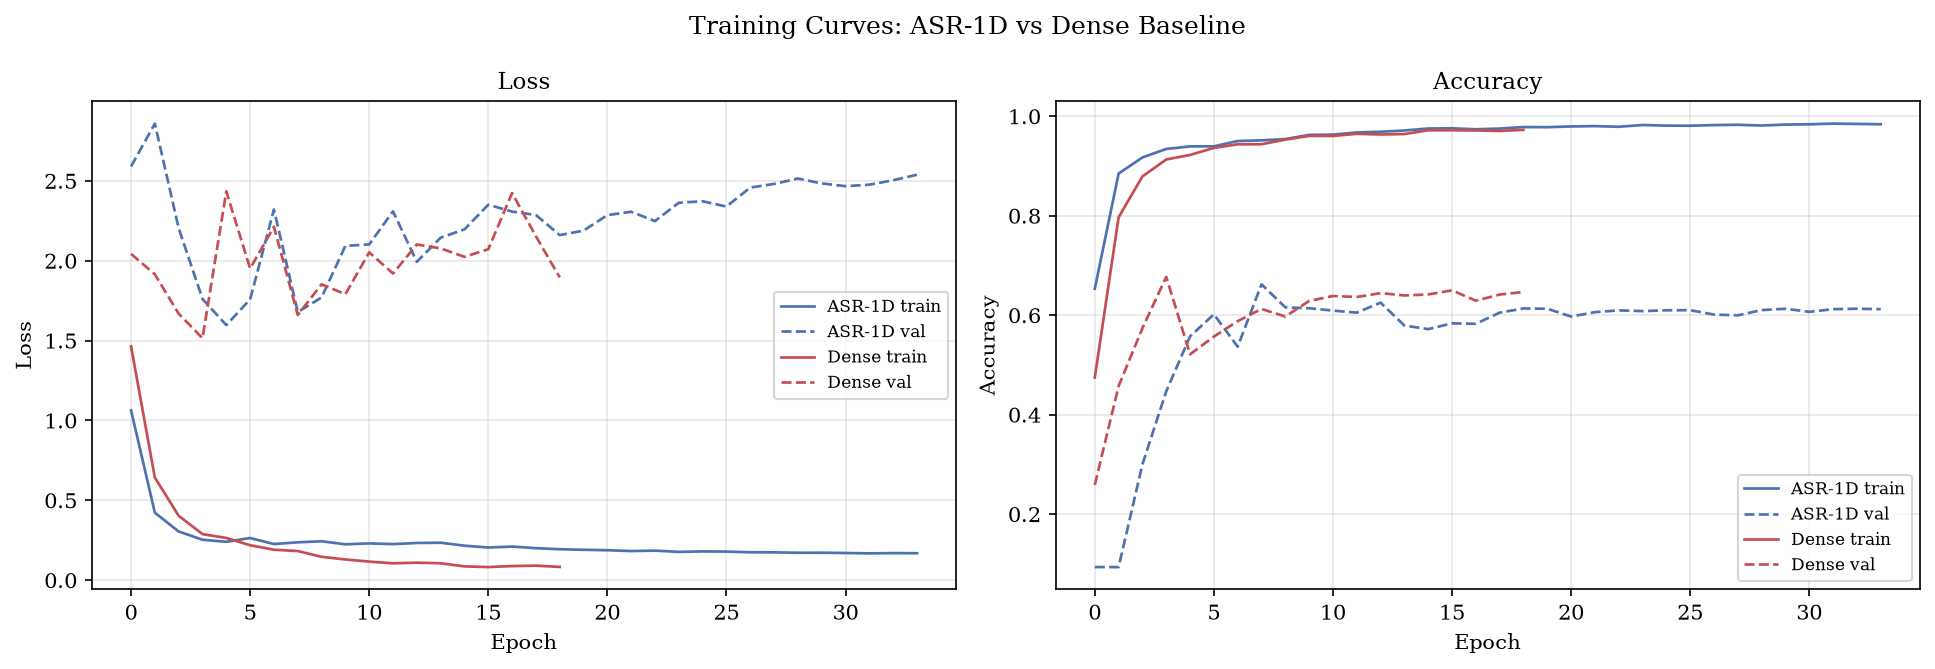

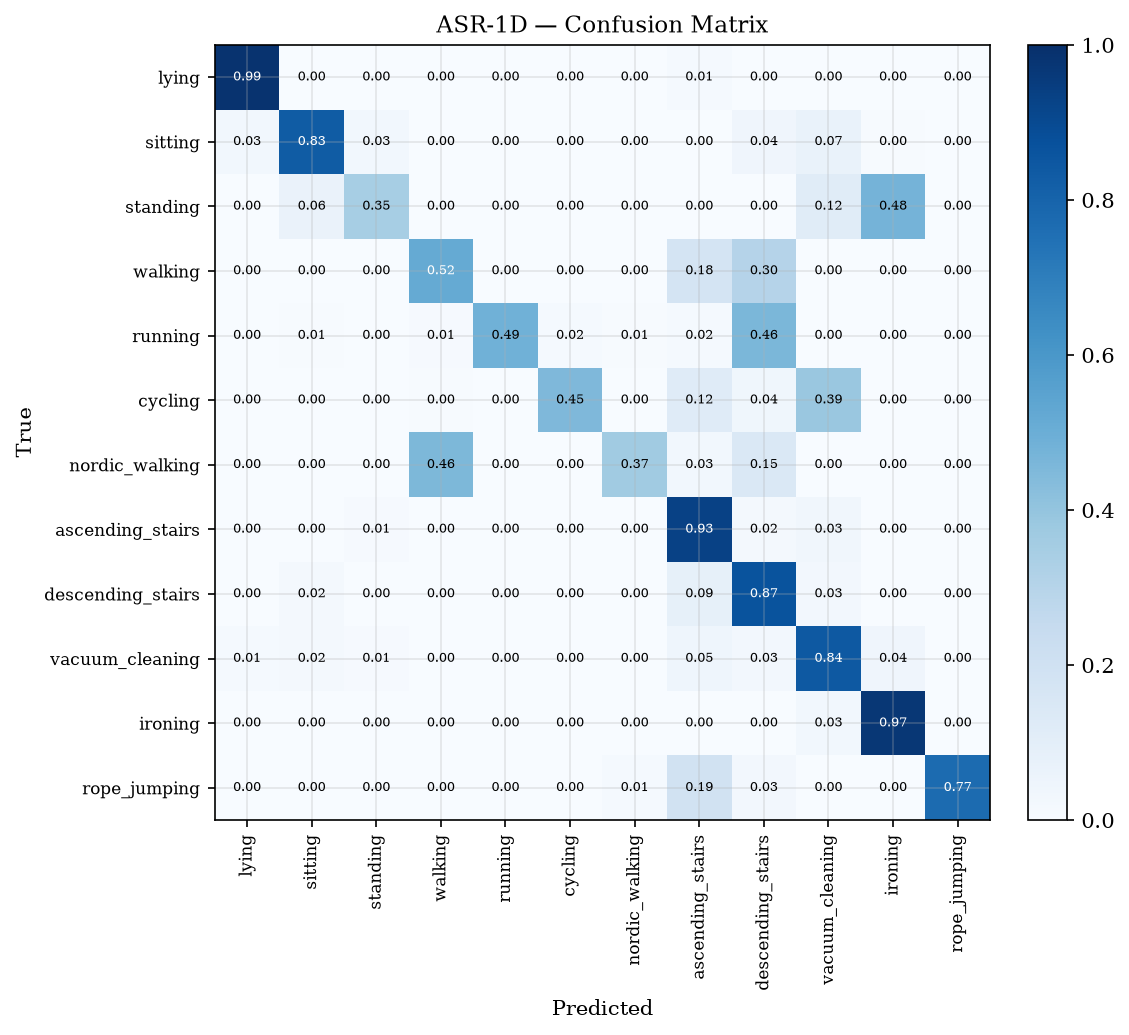

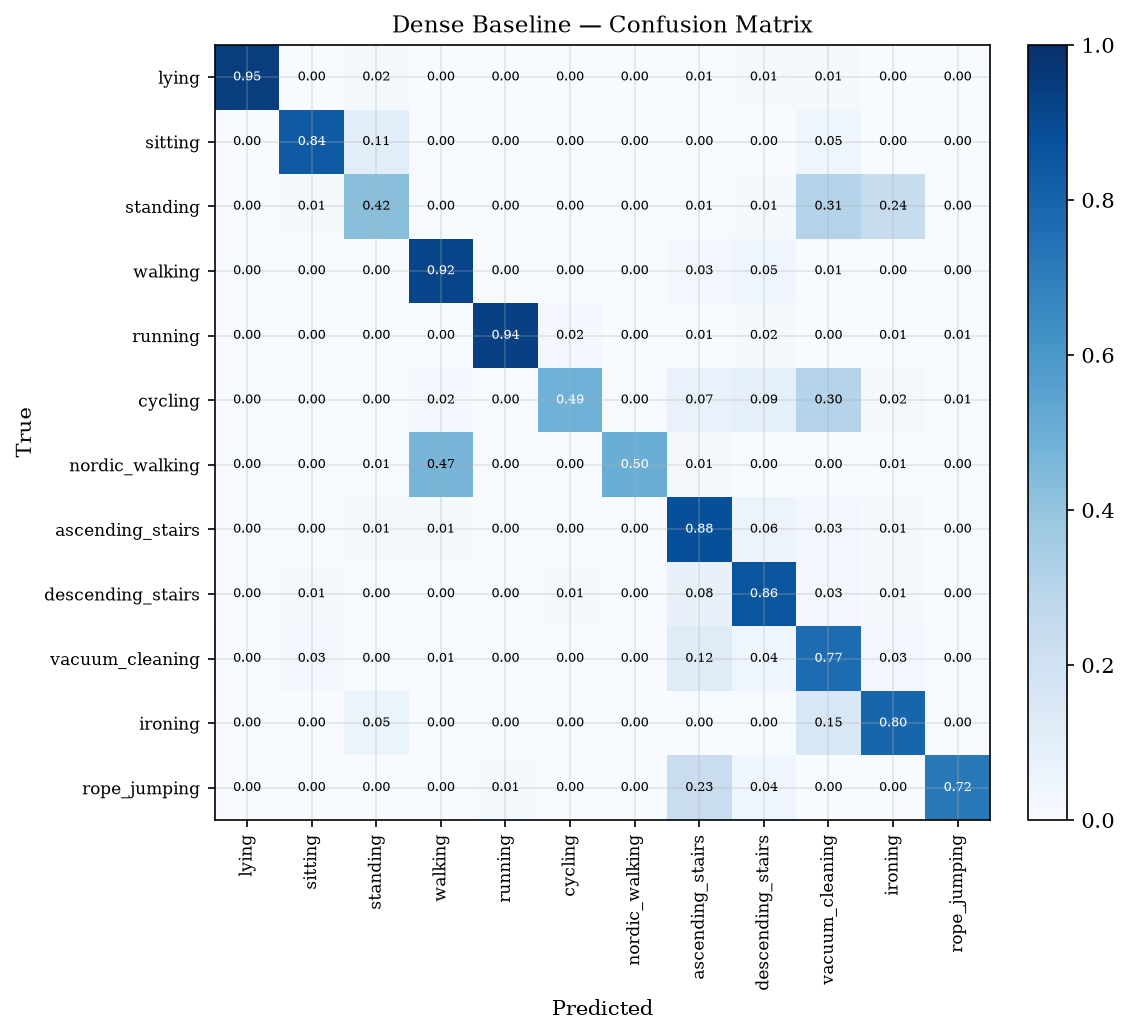

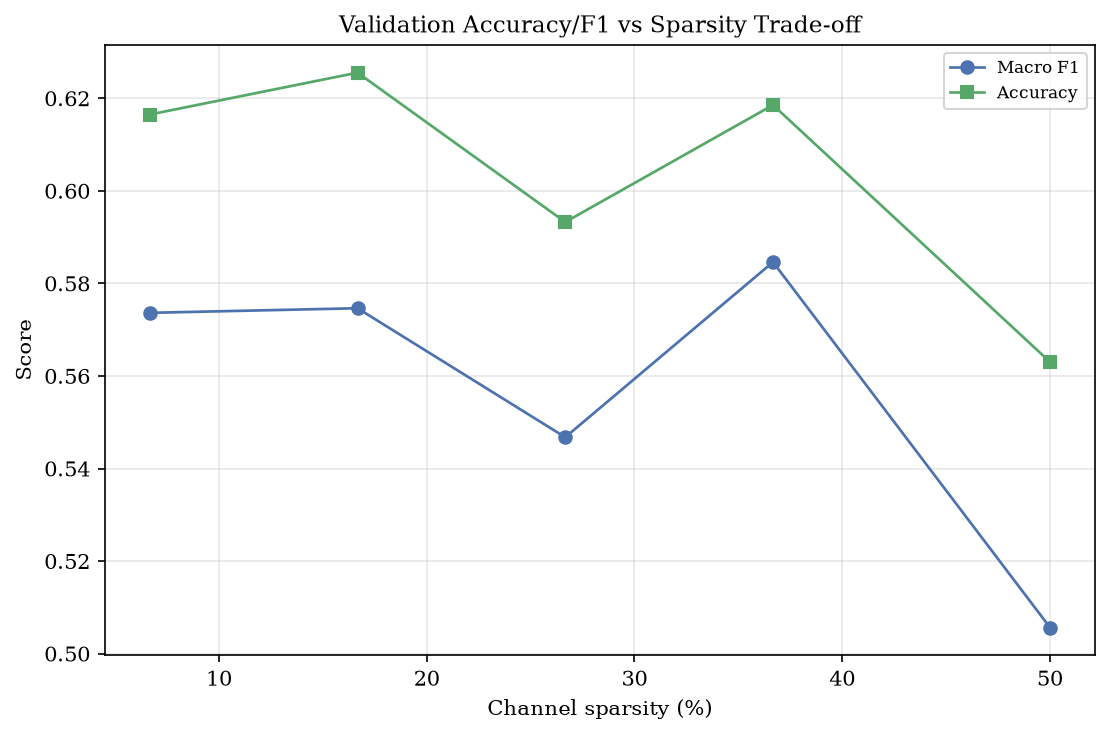

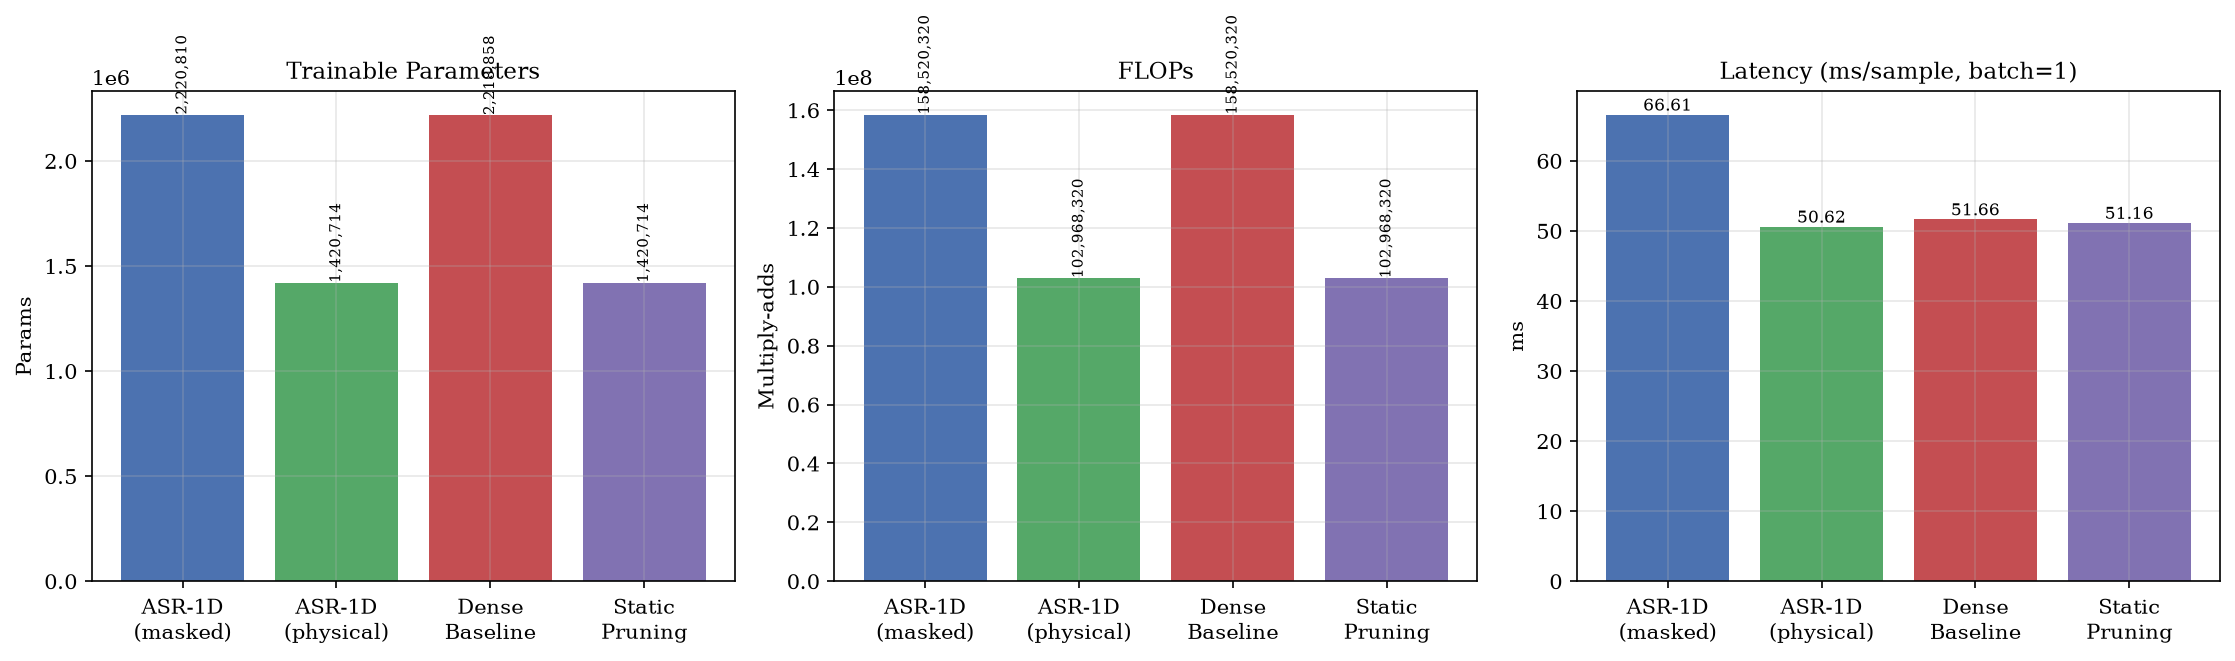

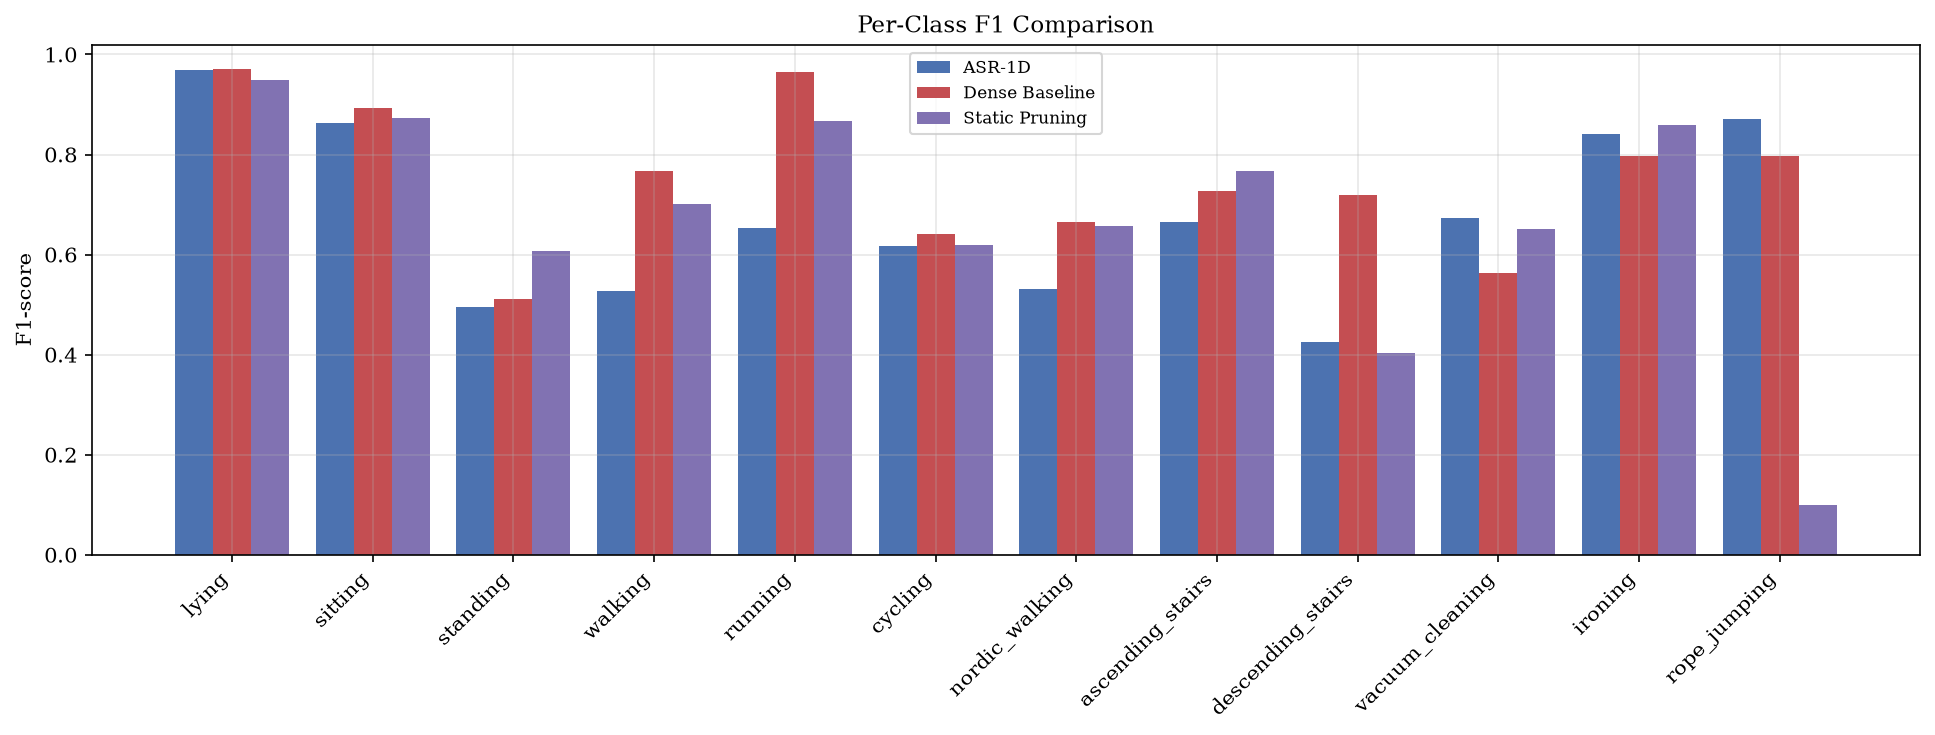

Saved summary table to ./results_summary.csv
                   Model  Macro F1  Params     FLOPs  Latency batch=1 (ms)  Latency batch=64 (ms)  Sparsity (%)
         ASR-1D (masked)  0.677939 2220810 158520320             66.608025               1.040718     18.084016
ASR-1D (physical pruned)  0.678088 1420714 102968320             50.618681               0.790143     18.084016
          Dense Baseline  0.751507 2218858 158520320             51.662030               0.812139      0.000000
          Static Pruning  0.671286 1420714 102968320             51.157144               0.799225     40.000000


,Model,Macro F1,Params,FLOPs,Latency batch=1 (ms),Latency batch=64 (ms),Sparsity (%)
0,ASR-1D (masked),0.677939,2220810,158520320,66.608025,1.040718,18.084016
1,ASR-1D (physical pruned),0.678088,1420714,102968320,50.618681,0.790143,18.084016
2,Dense Baseline,0.751507,2218858,158520320,51.662030,0.812139,0.000000
3,Static Pruning,0.671286,1420714,102968320,51.157144,0.799225,40.000000


In [29]:
# 1. Training curves (loss & accuracy) — ASR-1D vs Dense
plot_training_curves(results["asr_history"], results["dense_history"])

# 2. Confusion matrices
plot_confusion_matrix_heatmap(results["asr_results"]["confusion_matrix"], results["idx2name"],
                               title="ASR-1D — Confusion Matrix")
plot_confusion_matrix_heatmap(results["dense_results"]["confusion_matrix"], results["idx2name"],
                               title="Dense Baseline — Confusion Matrix")

# 3. Accuracy vs sparsity trade-off (pruning sweep)
plot_sparsity_tradeoff(results["sparsity_sweep_results"])

# 4. Efficiency comparison (params, FLOPs, latency bar charts)
plot_efficiency_comparison(results)

# 5. Per-class F1 comparison (3-way)
plot_per_class_f1(results["asr_results"]["report_dict"], results["dense_results"]["report_dict"],
                   results["idx2name"], static_report=results["static_results"]["report_dict"])

# 6. Summary table export (CSV, for pasting into thesis)
summary_df = export_summary_table(results)
summary_df

In [30]:
!pip install nvidia-ml-py3 psutil --quiet

In [31]:
# ===================================================================
# Module 1 & 2: GPU Energy + GPU/RAM Memory (inference-based measurement)
# Reuses already-trained models from `results` — no retraining needed.
# ===================================================================
import threading

try:
    import pynvml
    pynvml.nvmlInit()
    _GPU_AVAILABLE = True
except Exception as e:
    _GPU_AVAILABLE = False
    print(f"[energy] pynvml/NVML not available ({e}) — power/energy will report as NaN. "
          f"Install with: pip install nvidia-ml-py3")

try:
    import psutil
    _PSUTIL_AVAILABLE = True
except ImportError:
    _PSUTIL_AVAILABLE = False
    print("[memory] psutil not available — RAM usage will report as NaN. Install with: pip install psutil")


class GPUPowerSampler:
    """Background thread samples GPU power (W) and memory (MB) every `interval_s` seconds while
    a block of code runs. Energy (Joules) = average power (W) x elapsed time (s)."""
    def __init__(self, interval_s=0.05, gpu_index=0):
        self.interval_s = interval_s
        self.gpu_index = gpu_index
        self._power, self._mem = [], []
        self._running = False
        self._thread = None

    def _loop(self):
        handle = pynvml.nvmlDeviceGetHandleByIndex(self.gpu_index)
        while self._running:
            try:
                self._power.append(pynvml.nvmlDeviceGetPowerUsage(handle) / 1000.0)  # mW -> W
                self._mem.append(pynvml.nvmlDeviceGetMemoryInfo(handle).used / (1024 ** 2))  # -> MB
            except Exception:
                pass
            time.sleep(self.interval_s)

    def __enter__(self):
        self._t0 = time.perf_counter()
        if _GPU_AVAILABLE:
            self._running = True
            self._thread = threading.Thread(target=self._loop, daemon=True)
            self._thread.start()
        return self

    def __exit__(self, *exc):
        self._elapsed_s = time.perf_counter() - self._t0
        if _GPU_AVAILABLE:
            self._running = False
            self._thread.join(timeout=1.0)

    @property
    def avg_power_w(self): return float(np.mean(self._power)) if self._power else float("nan")
    @property
    def peak_power_w(self): return float(np.max(self._power)) if self._power else float("nan")
    @property
    def avg_mem_mb(self): return float(np.mean(self._mem)) if self._mem else float("nan")
    @property
    def peak_mem_mb(self): return float(np.max(self._mem)) if self._mem else float("nan")
    @property
    def energy_j(self): return self.avg_power_w * self._elapsed_s if self._power else float("nan")


def measure_inference_energy(model, input_shape, n_runs=200, batch_size=64):
    """Repeated batched inference (same batch=64 convention as benchmark_throughput() already
    in this notebook) while sampling GPU power/memory in the background."""
    dummy = tf.random.normal((batch_size,) + input_shape)
    _ = model(dummy, training=False)  # warmup, excluded from measurement

    with GPUPowerSampler() as sampler:
        for _ in range(n_runs):
            _ = model(dummy, training=False)

    n_samples = n_runs * batch_size
    ram_mb = (psutil.Process().memory_info().rss / (1024 ** 2)) if _PSUTIL_AVAILABLE else float("nan")
    energy_total = sampler.energy_j
    return {
        "avg_power_w": sampler.avg_power_w,
        "peak_power_w": sampler.peak_power_w,
        "energy_j_per_inference": (energy_total / n_samples) if energy_total == energy_total else float("nan"),
        "peak_gpu_mem_mb": sampler.peak_mem_mb,
        "avg_gpu_mem_mb": sampler.avg_mem_mb,
        "cpu_ram_mb": ram_mb,
    }


# ---- Run for every model already trained in `results` ----
_input_shape = tuple(results["asr_model"].input.shape[1:])  # Keras 3-safe (uses .input.shape, not
                                                              # the removed .input_shape attribute)

_models_to_measure = {
    "ASR-1D (masked)": results["asr_model"],
    "Dense Baseline": results["dense_model"],
    "Static Pruning": results["static_model"],
}
if results["deploy_model"] is not None:
    _models_to_measure["ASR-1D (physical)"] = results["deploy_model"]

energy_memory_rows = []
for name, model in _models_to_measure.items():
    m = measure_inference_energy(model, _input_shape)
    m["Model"] = name
    energy_memory_rows.append(m)
    print(f"{name:20s} avg_power={m['avg_power_w']:.2f}W  "
          f"energy/inf={m['energy_j_per_inference']*1000:.4f} mJ  "
          f"peak_gpu_mem={m['peak_gpu_mem_mb']:.1f}MB")

energy_memory_df = pd.DataFrame(energy_memory_rows)[
    ["Model", "avg_power_w", "peak_power_w", "energy_j_per_inference",
     "peak_gpu_mem_mb", "avg_gpu_mem_mb", "cpu_ram_mb"]
]

# Energy reduction % vs Dense baseline
dense_energy = energy_memory_df.loc[energy_memory_df["Model"] == "Dense Baseline", "energy_j_per_inference"].values[0]
energy_memory_df["energy_reduction_pct_vs_dense"] = (
    (1 - energy_memory_df["energy_j_per_inference"] / dense_energy) * 100
)

energy_memory_df.to_csv("./energy_metrics.csv", index=False)
print("\nSaved: energy_metrics.csv")
energy_memory_df

ASR-1D (masked)      avg_power=133.21W  energy/inf=137.5760 mJ  peak_gpu_mem=4153.7MB
Dense Baseline       avg_power=133.96W  energy/inf=107.0385 mJ  peak_gpu_mem=4153.7MB
Static Pruning       avg_power=133.48W  energy/inf=104.3798 mJ  peak_gpu_mem=4153.7MB
ASR-1D (physical)    avg_power=133.44W  energy/inf=104.3048 mJ  peak_gpu_mem=4153.7MB

Saved: energy_metrics.csv


,Model,avg_power_w,peak_power_w,energy_j_per_inference,peak_gpu_mem_mb,avg_gpu_mem_mb,cpu_ram_mb,energy_reduction_pct_vs_dense
0,ASR-1D (masked),133.212333,133.618,0.137576,4153.6875,4153.6875,10474.128906,-28.529419
1,Dense Baseline,133.955529,134.233,0.107039,4153.6875,4153.6875,10474.132812,0.000000
2,Static Pruning,133.484705,134.220,0.104380,4153.6875,4153.6875,10474.132812,2.483883
3,ASR-1D (physical),133.439300,133.632,0.104305,4153.6875,4153.6875,10474.132812,2.553999


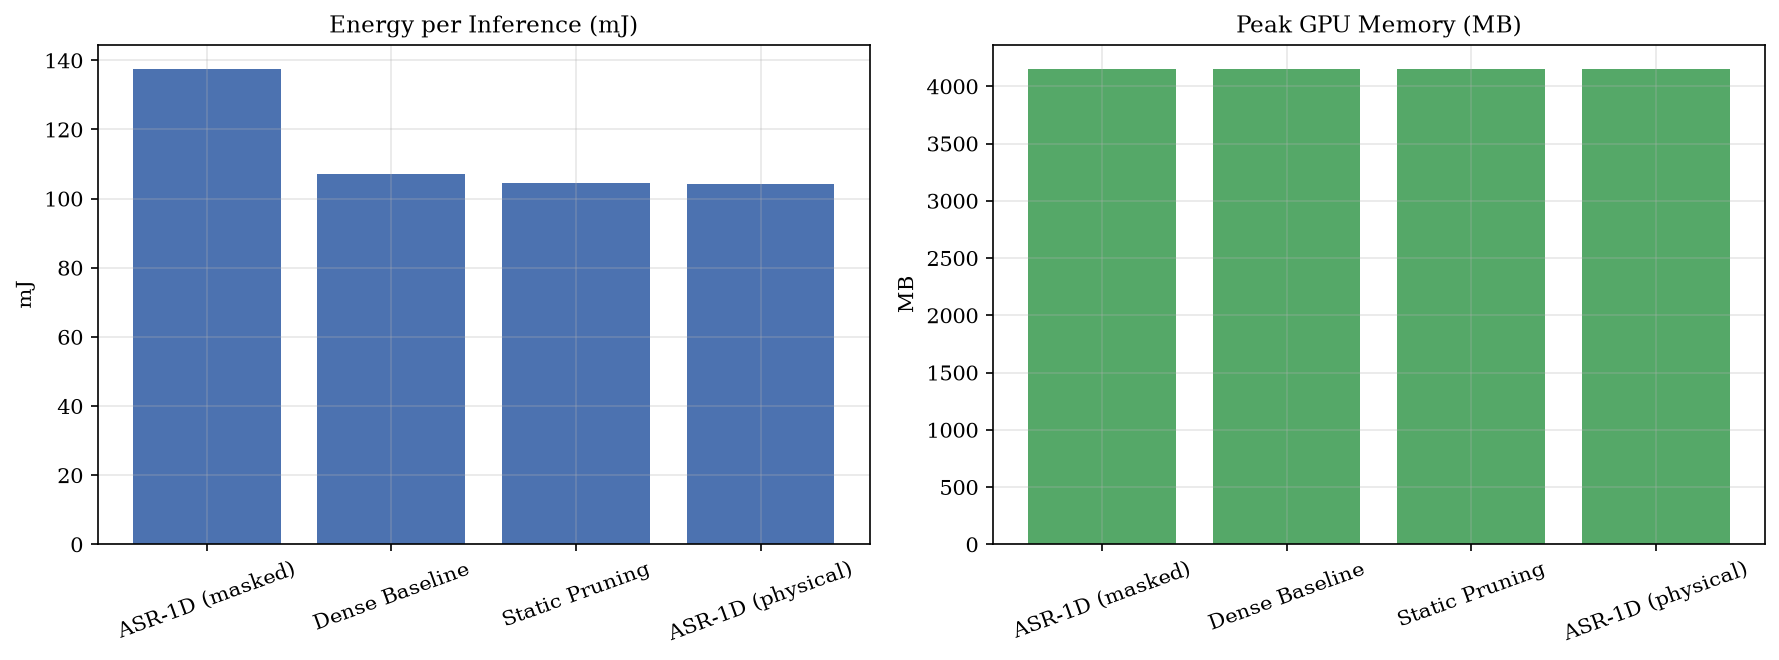

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].bar(energy_memory_df["Model"], energy_memory_df["energy_j_per_inference"] * 1000, color="#4C72B0")
axes[0].set_title("Energy per Inference (mJ)"); axes[0].set_ylabel("mJ"); axes[0].tick_params(axis='x', rotation=20)

axes[1].bar(energy_memory_df["Model"], energy_memory_df["peak_gpu_mem_mb"], color="#55A868")
axes[1].set_title("Peak GPU Memory (MB)"); axes[1].set_ylabel("MB"); axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

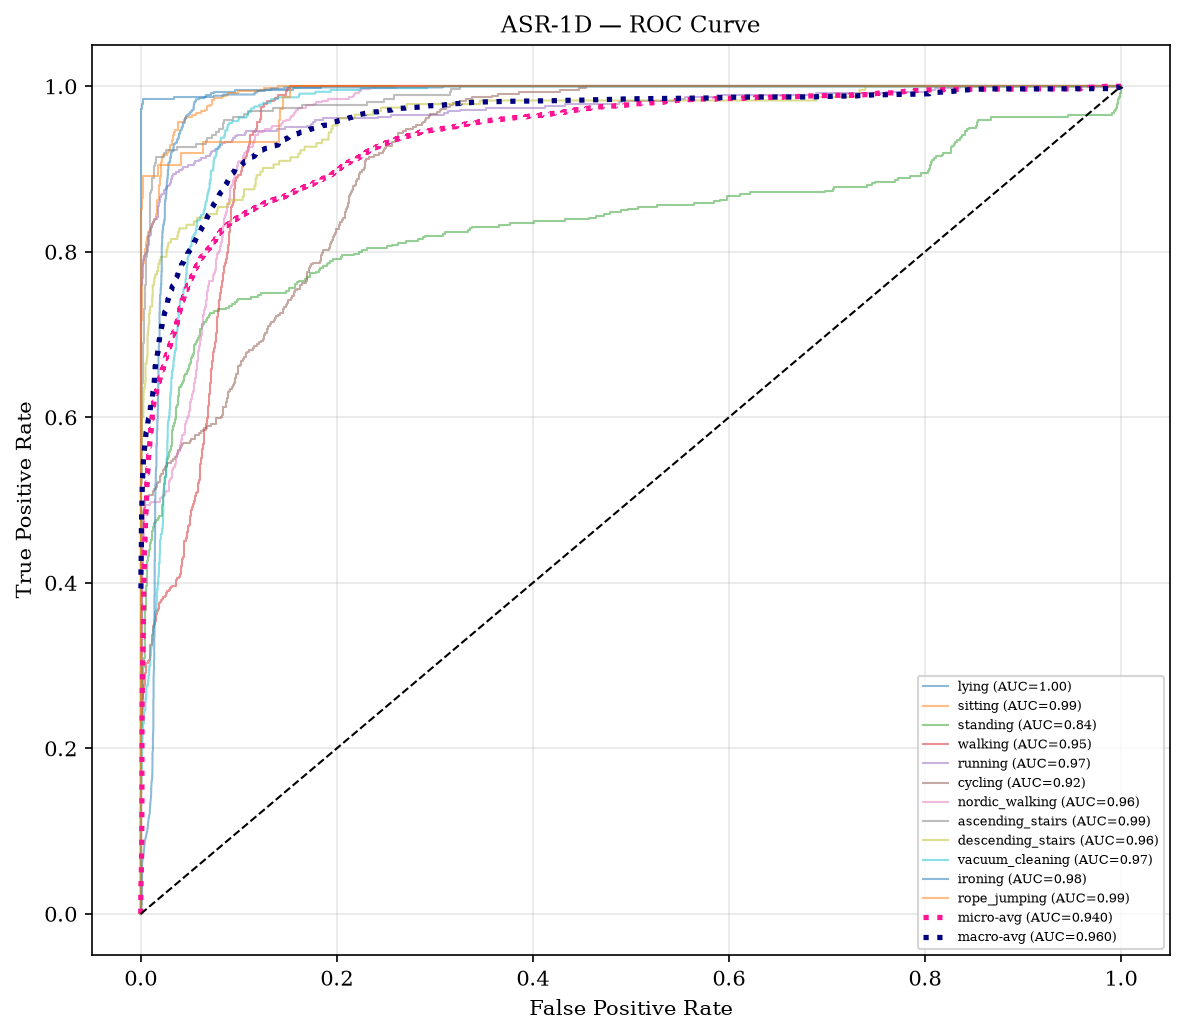

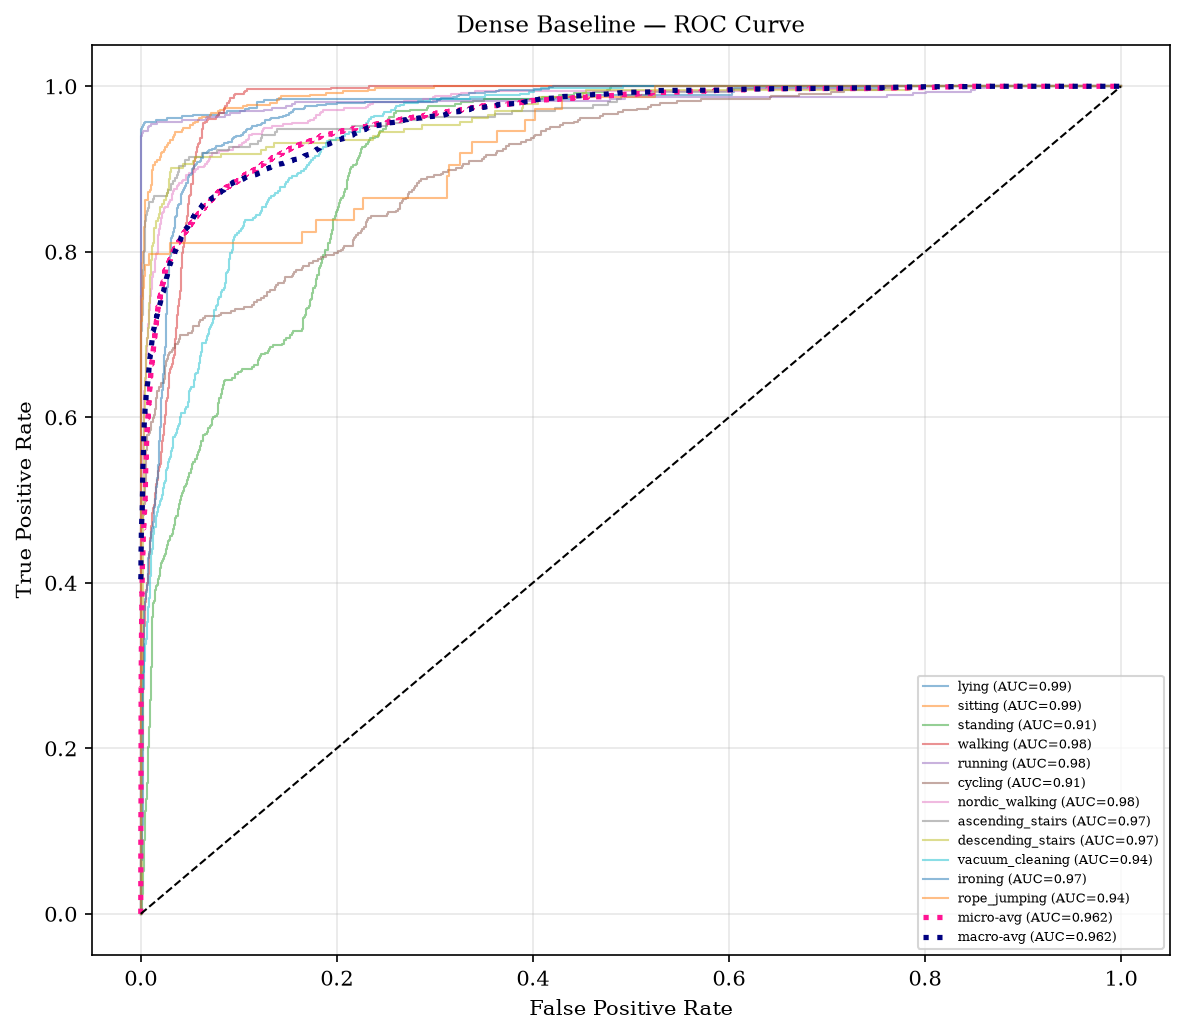

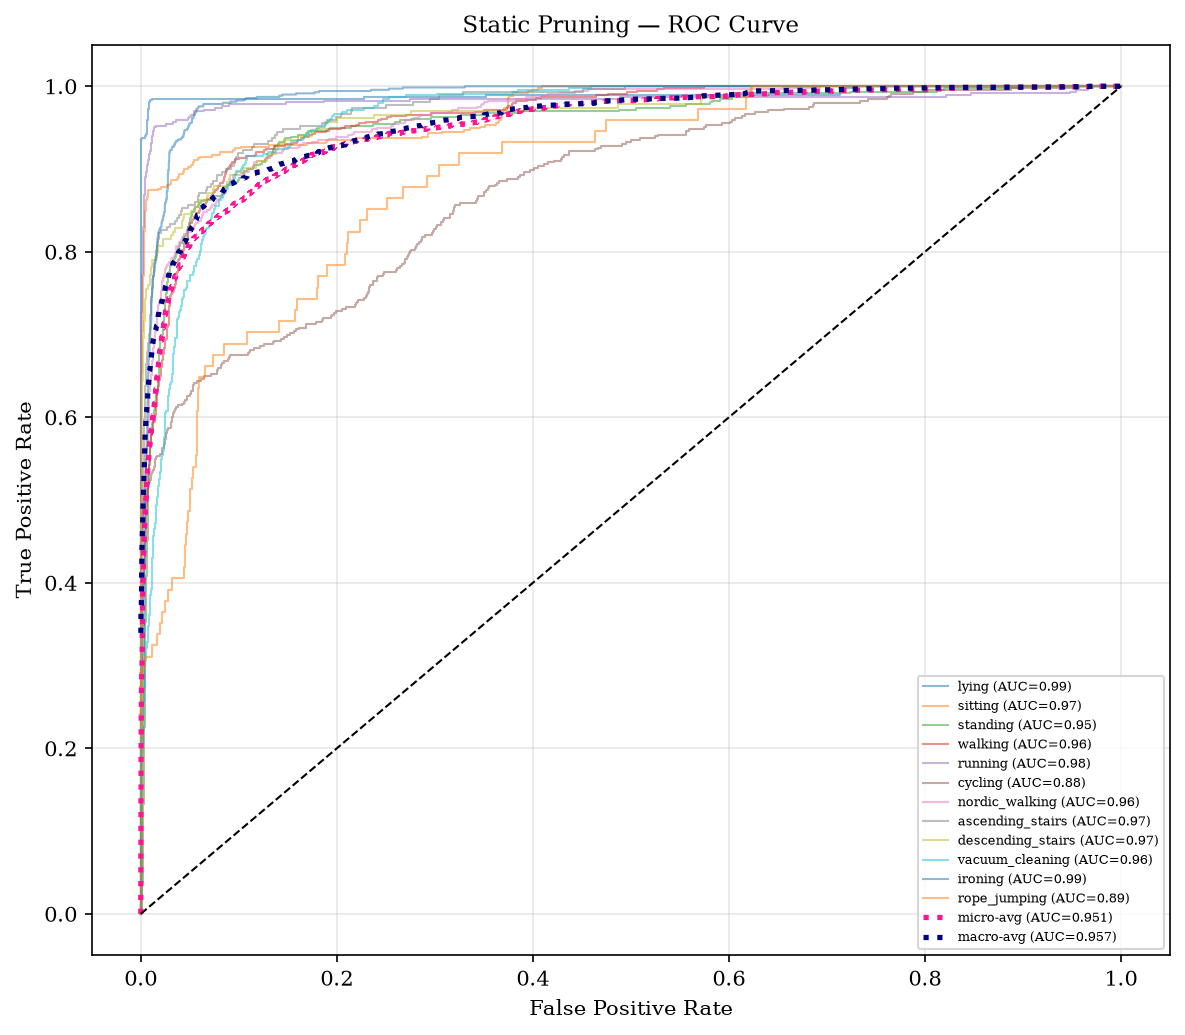


Macro AUC — ASR-1D: 0.9601  |  Dense: 0.9617  |  Static: 0.9566


In [33]:
# ===================================================================
# Module 4: Multi-class ROC Curves + Micro/Macro AUC
# Reuses results["asr_model"] / results["dense_model"] / results["Xte"] / results["yte"]
# ===================================================================
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

def plot_roc_auc(model, Xte, yte, idx2name, title="ROC Curve", figsize=(8, 7)):
    all_classes = sorted(idx2name.keys())
    y_prob = model.predict(Xte, batch_size=256, verbose=0)
    y_true_bin = label_binarize(yte, classes=all_classes)

    fpr, tpr, roc_auc = {}, {}, {}
    valid = []
    for i, cls in enumerate(all_classes):
        if y_true_bin[:, i].sum() == 0:
            continue  # skip classes with zero support in this test split
        fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
        valid.append(i)

    fpr["micro"], tpr["micro"], _ = roc_curve(y_true_bin[:, valid].ravel(), y_prob[:, valid].ravel())
    roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

    all_fpr = np.unique(np.concatenate([fpr[i] for i in valid]))
    mean_tpr = np.zeros_like(all_fpr)
    for i in valid:
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
    mean_tpr /= len(valid)
    fpr["macro"], tpr["macro"] = all_fpr, mean_tpr
    roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

    fig, ax = plt.subplots(figsize=figsize)
    for i in valid:
        ax.plot(fpr[i], tpr[i], lw=1, alpha=0.5, label=f"{idx2name[i]} (AUC={roc_auc[i]:.2f})")
    ax.plot(fpr["micro"], tpr["micro"], color="deeppink", linestyle=":", lw=2.5,
            label=f"micro-avg (AUC={roc_auc['micro']:.3f})")
    ax.plot(fpr["macro"], tpr["macro"], color="navy", linestyle=":", lw=2.5,
            label=f"macro-avg (AUC={roc_auc['macro']:.3f})")
    ax.plot([0, 1], [0, 1], "k--", lw=1)
    ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
    ax.set_title(title); ax.legend(fontsize=6, loc="lower right")
    plt.tight_layout(); plt.show()
    return roc_auc


roc_auc_asr = plot_roc_auc(results["asr_model"], results["Xte"], results["yte"], results["idx2name"],
                            title="ASR-1D — ROC Curve")
roc_auc_dense = plot_roc_auc(results["dense_model"], results["Xte"], results["yte"], results["idx2name"],
                              title="Dense Baseline — ROC Curve")
roc_auc_static = plot_roc_auc(results["static_model"], results["Xte"], results["yte"], results["idx2name"],
                               title="Static Pruning — ROC Curve")

print(f"\nMacro AUC — ASR-1D: {roc_auc_asr['macro']:.4f}  |  "
      f"Dense: {roc_auc_dense['macro']:.4f}  |  Static: {roc_auc_static['macro']:.4f}")

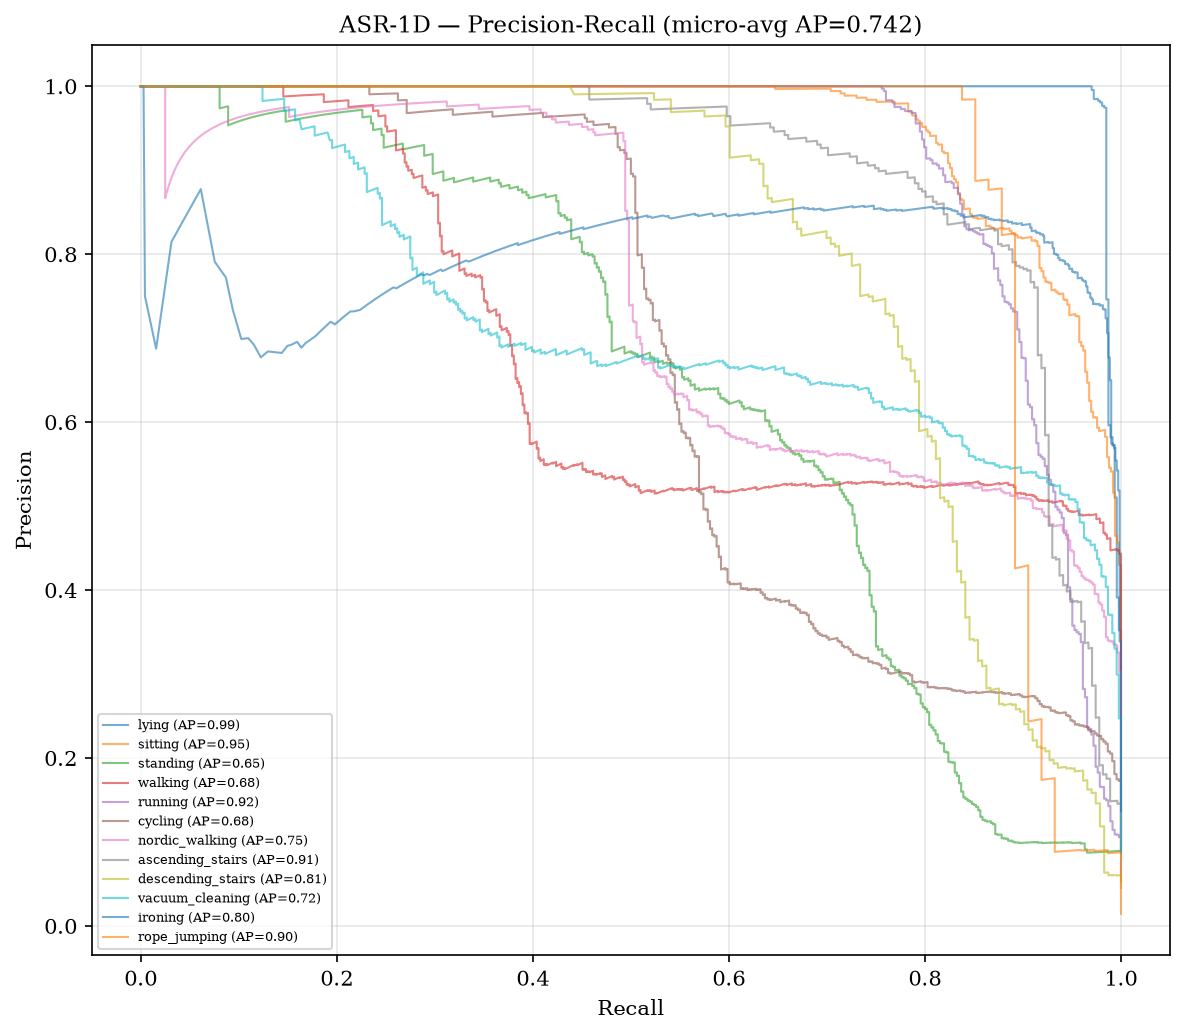

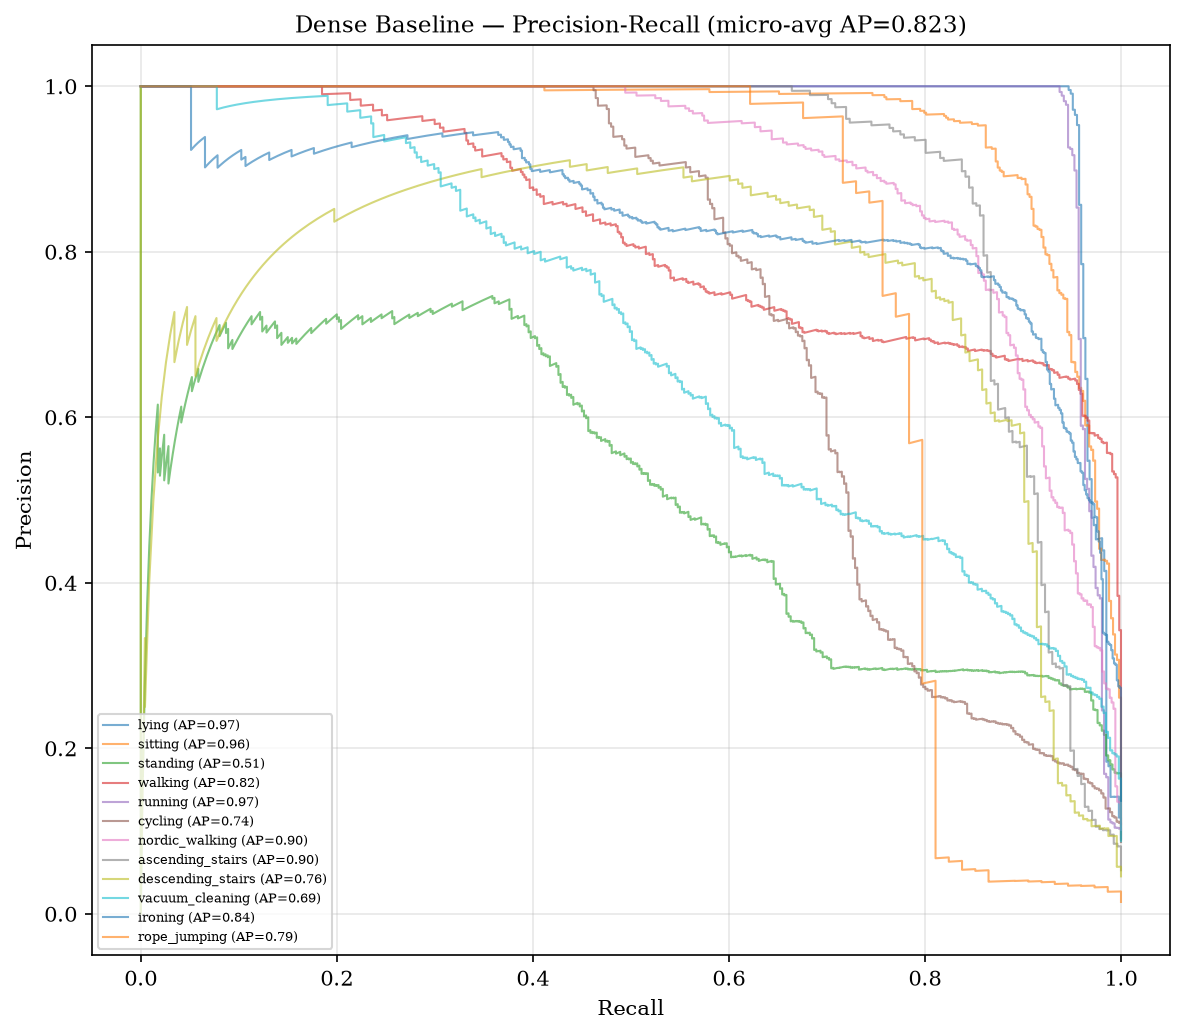

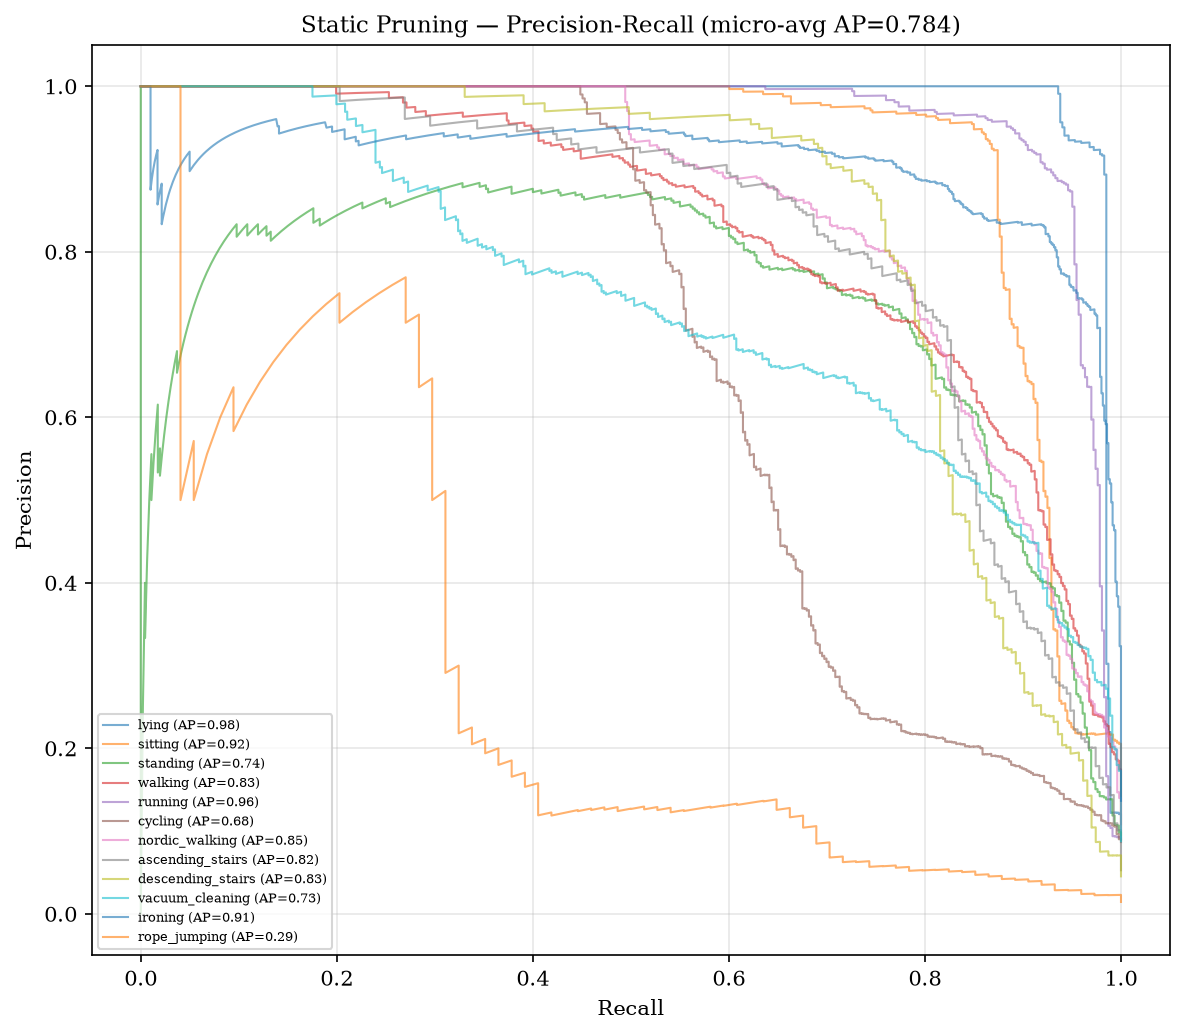


Micro-avg AP — ASR-1D: 0.7417  |  Dense: 0.8227  |  Static: 0.7843


In [34]:
# ===================================================================
# Module 5: Precision-Recall Curves + Average Precision
# ===================================================================
from sklearn.metrics import precision_recall_curve, average_precision_score

def plot_pr_curves(model, Xte, yte, idx2name, title="Precision-Recall Curve", figsize=(8, 7)):
    all_classes = sorted(idx2name.keys())
    y_prob = model.predict(Xte, batch_size=256, verbose=0)
    y_true_bin = label_binarize(yte, classes=all_classes)

    fig, ax = plt.subplots(figsize=figsize)
    ap_scores = {}
    for i, cls in enumerate(all_classes):
        if y_true_bin[:, i].sum() == 0:
            continue
        precision, recall, _ = precision_recall_curve(y_true_bin[:, i], y_prob[:, i])
        ap = average_precision_score(y_true_bin[:, i], y_prob[:, i])
        ap_scores[idx2name[cls]] = ap
        ax.plot(recall, precision, lw=1, alpha=0.6, label=f"{idx2name[cls]} (AP={ap:.2f})")

    valid_cols = [i for i, cls in enumerate(all_classes) if y_true_bin[:, i].sum() > 0]
    micro_ap = average_precision_score(y_true_bin[:, valid_cols], y_prob[:, valid_cols], average="micro")
    ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
    ax.set_title(f"{title} (micro-avg AP={micro_ap:.3f})")
    ax.legend(fontsize=6, loc="lower left")
    plt.tight_layout(); plt.show()
    return ap_scores, micro_ap


ap_asr, micro_ap_asr = plot_pr_curves(results["asr_model"], results["Xte"], results["yte"],
                                       results["idx2name"], title="ASR-1D — Precision-Recall")
ap_dense, micro_ap_dense = plot_pr_curves(results["dense_model"], results["Xte"], results["yte"],
                                           results["idx2name"], title="Dense Baseline — Precision-Recall")
ap_static, micro_ap_static = plot_pr_curves(results["static_model"], results["Xte"], results["yte"],
                                             results["idx2name"], title="Static Pruning — Precision-Recall")

print(f"\nMicro-avg AP — ASR-1D: {micro_ap_asr:.4f}  |  Dense: {micro_ap_dense:.4f}  |  Static: {micro_ap_static:.4f}")

## 14. Extended Research Modules — Energy, Memory, ROC/PR, Ablation, Statistics, Sensitivity, Explainability, Export

Everything below reuses the already-trained models in `results` (Sections 11/13 above) except Modules 7 and 8, which train additional models for statistical/sensitivity analysis and will take noticeably longer to run.

### 14.1 Module 6 — Ablation Study

Saved: ablation_results.csv


,Model,Macro F1,Balanced Accuracy,Params,FLOPs,Latency batch=64 (ms),Sparsity (%),F1 change vs Dense (%),FLOPs reduction vs Dense (%)
0,ASR-1D (masked),0.677939,0.696945,2220810,158520320,1.040718,18.084016,-9.789426,0.000000
1,ASR-1D (physical pruned),0.678088,0.697114,1420714,102968320,0.790143,18.084016,-9.769506,35.044088
2,Dense Baseline,0.751507,0.756420,2218858,158520320,0.812139,0.000000,0.000000,0.000000
3,Static Pruning,0.671286,0.682935,1420714,102968320,0.799225,40.000000,-10.674716,35.044088


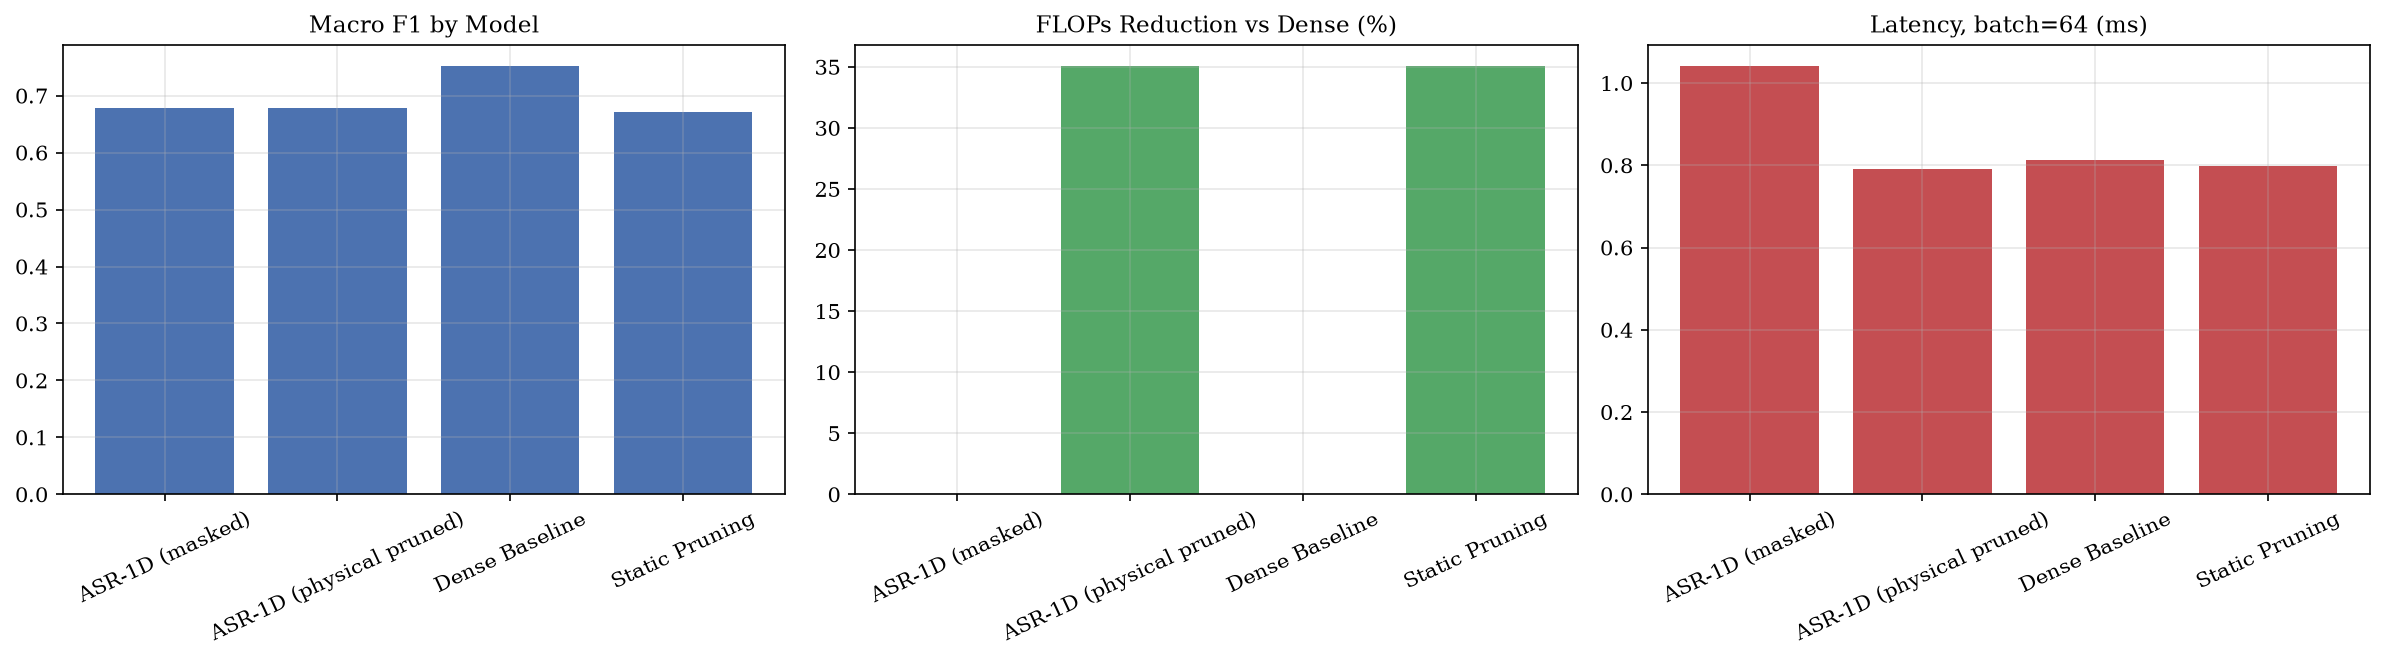

In [35]:
# ===================================================================
# Module 6: Ablation Study — compares every model already trained
# Reuses `results` dict directly, no retraining.
# ===================================================================
from sklearn.metrics import balanced_accuracy_score

def _bal_acc(model, Xte, yte, batch_size=256):
    y_pred = np.argmax(model.predict(Xte, batch_size=batch_size, verbose=0), axis=1)
    return balanced_accuracy_score(yte, y_pred)

ablation_rows = [
    {
        "Model": "ASR-1D (masked)",
        "Macro F1": results["asr_results"]["macro_f1"],
        "Balanced Accuracy": _bal_acc(results["asr_model"], results["Xte"], results["yte"]),
        "Params": results["asr_params"], "FLOPs": results["asr_flops"],
        "Latency batch=64 (ms)": results["asr_throughput_latency"],
        "Sparsity (%)": results["sparsity_stats"]["overall_sparsity"] * 100,
    },
    {
        "Model": "Dense Baseline",
        "Macro F1": results["dense_results"]["macro_f1"],
        "Balanced Accuracy": _bal_acc(results["dense_model"], results["Xte"], results["yte"]),
        "Params": results["dense_params"], "FLOPs": results["dense_flops"],
        "Latency batch=64 (ms)": results["dense_throughput_latency"],
        "Sparsity (%)": 0.0,
    },
    {
        "Model": "Static Pruning",
        "Macro F1": results["static_results"]["macro_f1"],
        "Balanced Accuracy": _bal_acc(results["static_model"], results["Xte"], results["yte"]),
        "Params": results["static_params"], "FLOPs": results["static_flops"],
        "Latency batch=64 (ms)": results["static_throughput_latency"],
        "Sparsity (%)": results["static_target_ratio"] * 100,
    },
]
if results["deploy_model"] is not None:
    ablation_rows.insert(1, {
        "Model": "ASR-1D (physical pruned)",
        "Macro F1": results["deploy_results"]["macro_f1"],
        "Balanced Accuracy": _bal_acc(results["deploy_model"], results["Xte"], results["yte"]),
        "Params": results["deploy_params"], "FLOPs": results["deploy_flops"],
        "Latency batch=64 (ms)": results["deploy_throughput_latency"],
        "Sparsity (%)": results["sparsity_stats"]["overall_sparsity"] * 100,
    })

ablation_df = pd.DataFrame(ablation_rows)
_dense_f1 = ablation_df.loc[ablation_df["Model"] == "Dense Baseline", "Macro F1"].values[0]
_dense_flops = ablation_df.loc[ablation_df["Model"] == "Dense Baseline", "FLOPs"].values[0]
ablation_df["F1 change vs Dense (%)"] = (ablation_df["Macro F1"] / _dense_f1 - 1) * 100
ablation_df["FLOPs reduction vs Dense (%)"] = (1 - ablation_df["FLOPs"] / _dense_flops) * 100

ablation_df.to_csv("./ablation_results.csv", index=False)
print("Saved: ablation_results.csv")
display(ablation_df)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
axes[0].bar(ablation_df["Model"], ablation_df["Macro F1"], color="#4C72B0")
axes[0].set_title("Macro F1 by Model"); axes[0].tick_params(axis="x", rotation=25)

axes[1].bar(ablation_df["Model"], ablation_df["FLOPs reduction vs Dense (%)"], color="#55A868")
axes[1].set_title("FLOPs Reduction vs Dense (%)"); axes[1].tick_params(axis="x", rotation=25)

axes[2].bar(ablation_df["Model"], ablation_df["Latency batch=64 (ms)"], color="#C44E52")
axes[2].set_title("Latency, batch=64 (ms)"); axes[2].tick_params(axis="x", rotation=25)

plt.tight_layout(); plt.savefig("./fig_ablation_comparison.png", bbox_inches="tight"); plt.show()


### 14.2 Module 3 — Complete Performance Table

In [36]:
# ===================================================================
# Module 3: Complete Performance Table (merges ablation + energy/memory + precision/recall)
# ===================================================================
_perf_rows = []
for row in ablation_rows:
    name = row["Model"]
    # find matching per-class report to pull macro precision/recall
    _report_map = {
        "ASR-1D (masked)": results["asr_results"], "ASR-1D (physical pruned)": results["deploy_results"],
        "Dense Baseline": results["dense_results"], "Static Pruning": results["static_results"],
    }
    _res = _report_map.get(name)
    _macro = _res["report_dict"]["macro avg"] if _res else {"precision": np.nan, "recall": np.nan}
    _acc = _res["report_dict"]["accuracy"] if _res else np.nan
    _energy_row = energy_memory_df[energy_memory_df["Model"] == name]
    _energy_row = _energy_row.iloc[0] if len(_energy_row) else None

    _perf_rows.append({
        "Model Name": name,
        "Parameters": row["Params"],
        "Sparsity %": row["Sparsity (%)"],
        "FLOPs": row["FLOPs"],
        "Latency (ms, batch=64)": row["Latency batch=64 (ms)"],
        "Inference Time (ms/sample)": row["Latency batch=64 (ms)"],
        "Training Time": np.nan,  # not captured during the original training run — Keras History
                                   # does not log wall-clock time by default; add a timing callback
                                   # (e.g. record time.perf_counter() at fit() start/end) if needed.
        "GPU Memory (MB, peak)": _energy_row["peak_gpu_mem_mb"] if _energy_row is not None else np.nan,
        "RAM Usage (MB)": _energy_row["cpu_ram_mb"] if _energy_row is not None else np.nan,
        "Power (W, avg)": _energy_row["avg_power_w"] if _energy_row is not None else np.nan,
        "Energy (J/inference)": _energy_row["energy_j_per_inference"] if _energy_row is not None else np.nan,
        "Accuracy": _acc,
        "Precision (macro)": _macro["precision"],
        "Recall (macro)": _macro["recall"],
        "F1-score (macro)": row["Macro F1"],
        "Balanced Accuracy": row["Balanced Accuracy"],
    })

complete_performance_df = pd.DataFrame(_perf_rows)
complete_performance_df.to_csv("./complete_performance_table.csv", index=False)
print("Saved: complete_performance_table.csv")
display(complete_performance_df)


Saved: complete_performance_table.csv


,Model Name,Parameters,Sparsity %,FLOPs,"Latency (ms, batch=64)",Inference Time (ms/sample),Training Time,"GPU Memory (MB, peak)",RAM Usage (MB),"Power (W, avg)",Energy (J/inference),Accuracy,Precision (macro),Recall (macro),F1-score (macro),Balanced Accuracy
0,ASR-1D (masked),2220810,18.084016,158520320,1.040718,1.040718,NaN,4153.6875,10474.128906,133.212333,0.137576,0.682490,0.776290,0.696945,0.677939,0.696945
1,ASR-1D (physical pruned),1420714,18.084016,102968320,0.790143,0.790143,NaN,NaN,NaN,NaN,NaN,0.682685,0.776378,0.697114,0.678088,0.697114
2,Dense Baseline,2218858,0.000000,158520320,0.812139,0.812139,NaN,4153.6875,10474.132812,133.955529,0.107039,0.753891,0.795894,0.756420,0.751507,0.756420
3,Static Pruning,1420714,40.000000,102968320,0.799225,0.799225,NaN,4153.6875,10474.132812,133.484705,0.104380,0.725875,0.784031,0.682935,0.671286,0.682935


### 14.3 Module 9 — Model Explainability (gate-based + activation heatmaps)

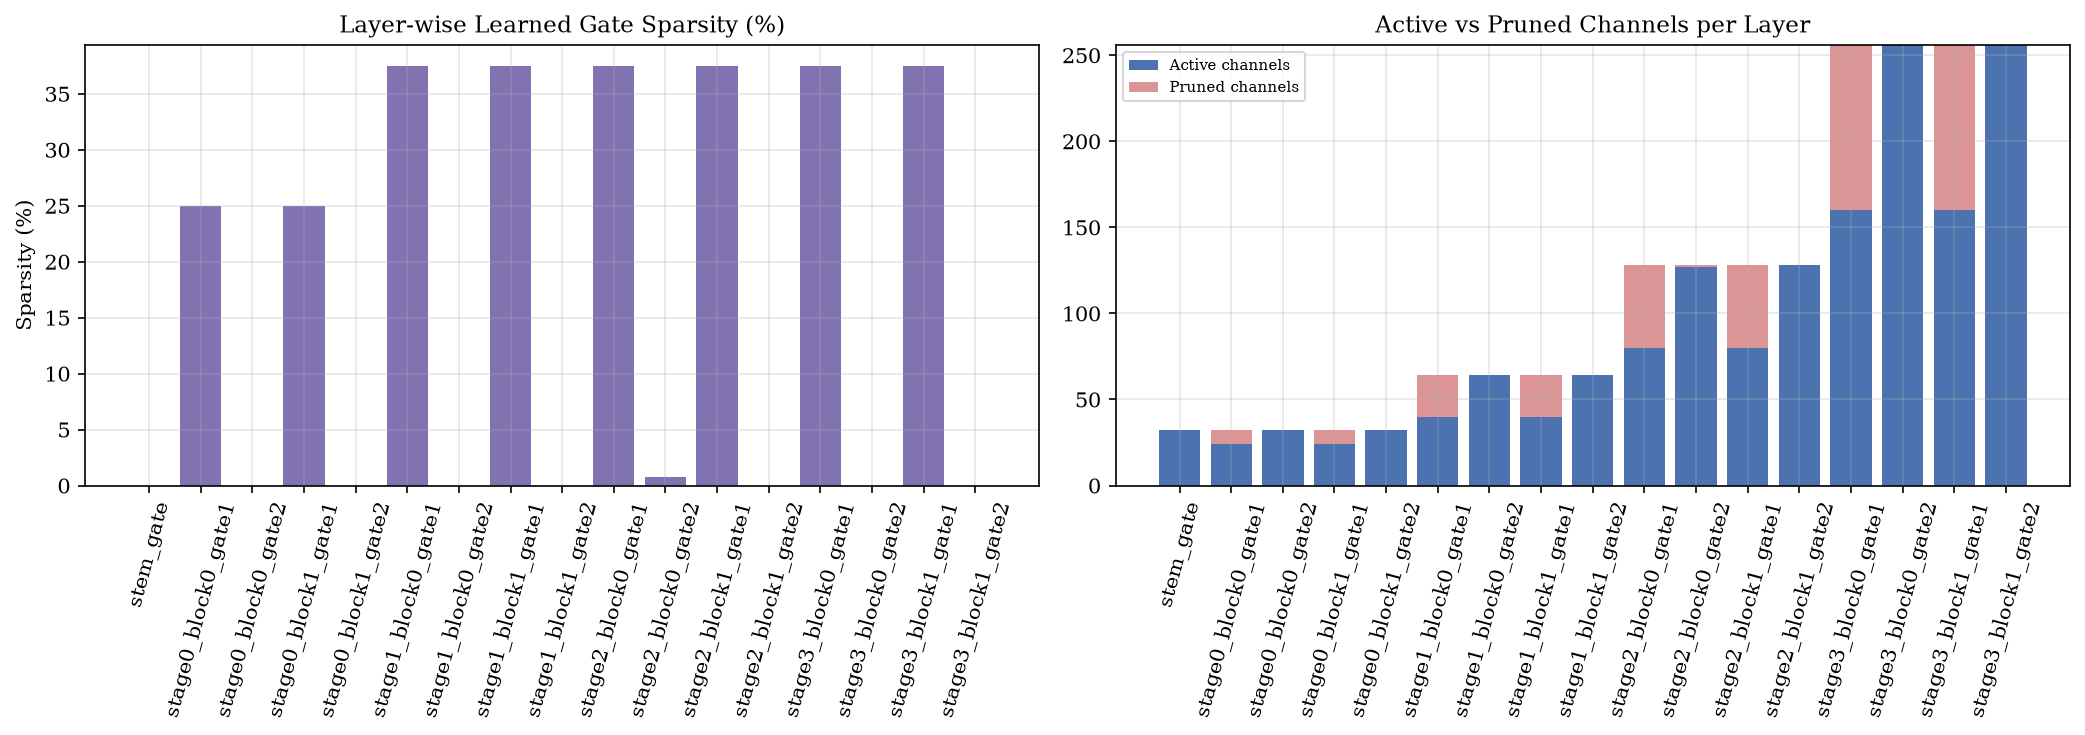

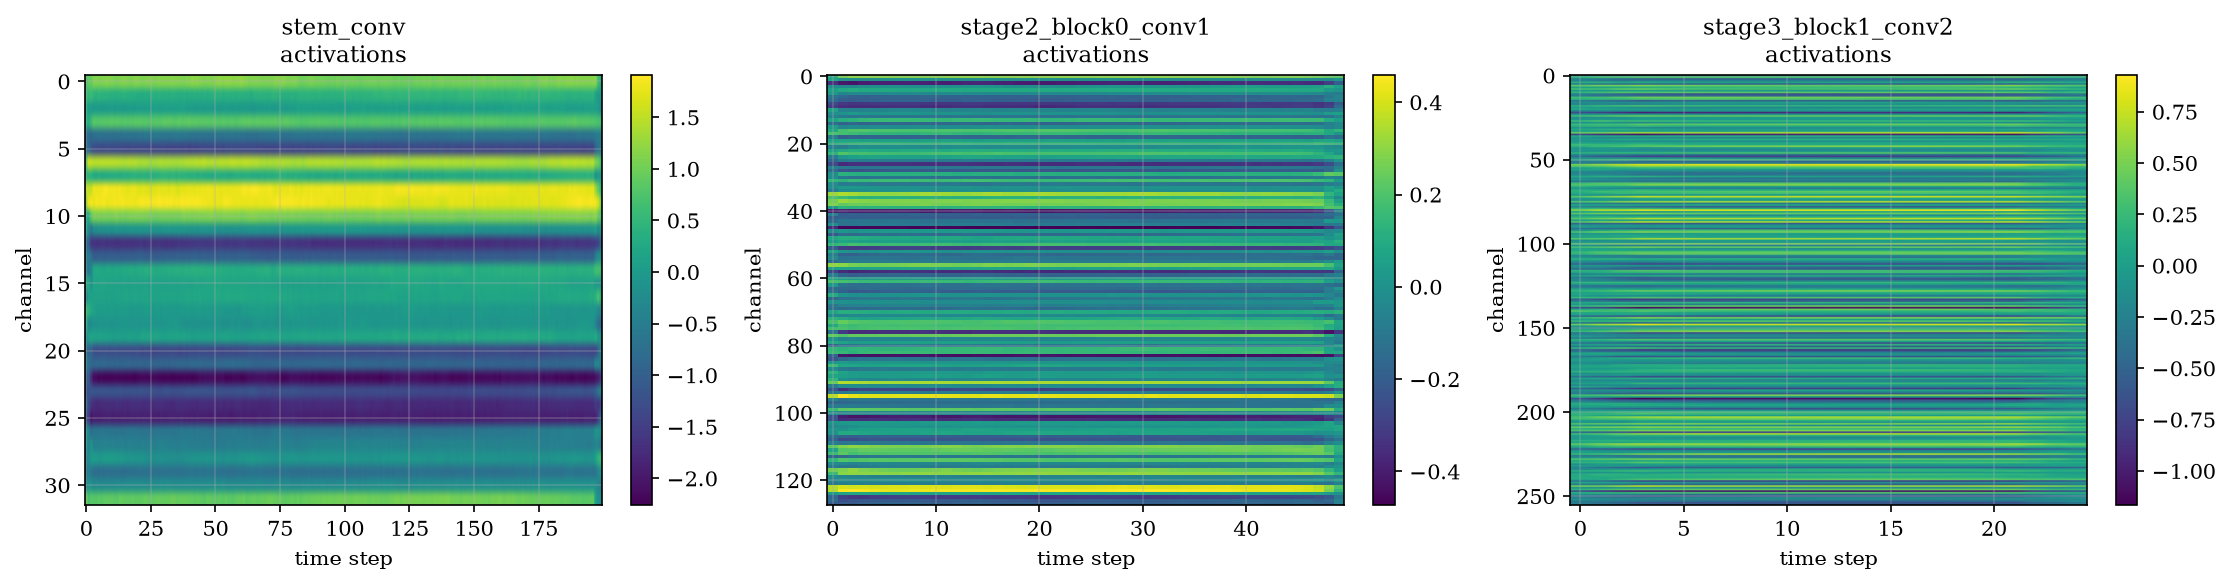

In [37]:
# ===================================================================
# Module 9: Model Explainability — gate-based (SHAP skipped: multi-channel 1D-CNN time-series
# input makes per-timestep Shapley estimation very slow and not very interpretable; layer-wise
# sparsity + activation visualization is the more standard/relevant approach for HAR 1D-CNNs and
# directly reuses what this notebook already computes, no extra dependency).
# ===================================================================

# --- 9a. Layer-wise sparsity (from the ASR-1D gates, already computed in results) ---
_per_layer = results["sparsity_stats"]["per_layer"]
_layer_names = list(_per_layer.keys())
_layer_sparsity = [_per_layer[n]["sparsity"] * 100 for n in _layer_names]
_layer_active = [_per_layer[n]["active"] for n in _layer_names]
_layer_total = [_per_layer[n]["total"] for n in _layer_names]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(_layer_names, _layer_sparsity, color="#8172B2")
axes[0].set_title("Layer-wise Learned Gate Sparsity (%)")
axes[0].set_ylabel("Sparsity (%)"); axes[0].tick_params(axis="x", rotation=75)

axes[1].bar(_layer_names, _layer_active, label="Active channels", color="#4C72B0")
axes[1].bar(_layer_names, [t - a for t, a in zip(_layer_total, _layer_active)],
            bottom=_layer_active, label="Pruned channels", color="#C44E52", alpha=0.6)
axes[1].set_title("Active vs Pruned Channels per Layer")
axes[1].tick_params(axis="x", rotation=75); axes[1].legend(fontsize=7)

plt.tight_layout(); plt.savefig("./fig_gate_layerwise_sparsity.png", bbox_inches="tight"); plt.show()

if results["sparsity_stats"]["overall_sparsity"] == 0.0:
    print("NOTE: overall learned gate sparsity is 0.0% — every channel is above the 'active' "
          "threshold, so the per-layer bars above will show no pruned channels. This reflects "
          "the gate-learning issue discussed earlier; re-run after the weight-decay-exclusion and "
          "sparsity_lambda_max fixes in Config/compile_model() to see whether this changes.")

# --- 9b. Intermediate-layer activation heatmap (one sample test window, ASR-1D model) ---
_conv_layers = [l for l in results["asr_model"].layers if isinstance(l, layers.Conv1D)]
_probe_layers = [_conv_layers[0], _conv_layers[len(_conv_layers) // 2], _conv_layers[-1]] if len(_conv_layers) >= 3 else _conv_layers

if _probe_layers:
    _activation_model = keras.Model(inputs=results["asr_model"].input,
                                     outputs=[l.output for l in _probe_layers])
    _sample = results["Xte"][:1]
    _activations = _activation_model.predict(_sample, verbose=0)
    if not isinstance(_activations, list):
        _activations = [_activations]

    fig, axes = plt.subplots(1, len(_probe_layers), figsize=(5 * len(_probe_layers), 4))
    if len(_probe_layers) == 1:
        axes = [axes]
    for ax, layer, act in zip(axes, _probe_layers, _activations):
        # act shape: (1, time, channels) -> transpose to (channels, time) for the heatmap
        im = ax.imshow(act[0].T, aspect="auto", cmap="viridis")
        ax.set_title(f"{layer.name}\nactivations"); ax.set_xlabel("time step"); ax.set_ylabel("channel")
        plt.colorbar(im, ax=ax, fraction=0.046)
    plt.tight_layout(); plt.savefig("./fig_activation_heatmaps.png", bbox_inches="tight"); plt.show()
else:
    print("No Conv1D layers found to probe for activation heatmaps.")


### 14.4 Module 8 — Hyperparameter Sensitivity Analysis (retrains — slower)

Found existing PAMAP2 data at ./pamap2_raw/PAMAP2_Dataset/Protocol, using it directly.
Loading raw subject files...
Subject files found: [101, 102, 103, 104, 105, 106, 107, 108, 109]
Raw rows: 2,872,533  subjects: 9
After cleaning: 1,921,431 rows
Windows built: (19082, 200, 40)
Window counts per raw activity_id before filtering:
  activity_id= 17 (ironing           ):   2370 windows
  activity_id=  4 (walking           ):   2287 windows
  activity_id=  1 (lying             ):   1914 windows
  activity_id=  3 (standing          ):   1880 windows
  activity_id=  2 (sitting           ):   1836 windows
  activity_id=  7 (nordic_walking    ):   1836 windows
  activity_id= 16 (vacuum_cleaning   ):   1741 windows
  activity_id=  6 (cycling           ):   1624 windows
  activity_id= 12 (ascending_stairs  ):   1151 windows
  activity_id= 13 (descending_stairs ):   1028 windows
  activity_id=  5 (running           ):    948 windows
  activity_id= 24 (rope_jumping      ):    467 windows
Kept 12 a

/home/uswa/Downloads/Uswa/envs/pamap2/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
I0000 00:00:1788523829.267832  201713 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1424484__.349
I0000 00:00:1788523840.946596  201713 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1424484__.349



Epoch 11: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 16: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 21: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
Macro F1: 0.6967
                   precision    recall  f1-score   support

            lying      0.996     0.959     0.977       468
          sitting      0.888     0.856     0.872       493
         standing      0.888     0.448     0.595       460
          walking      0.496     0.427     0.459       557
          running      1.000     0.924     0.961       463
          cycling      1.000     0.466     0.636       446
   nordic_walking      0.968     0.232     0.374       522
 ascending_stairs      0.426     0.908     0.580       271
descending_stairs      0.447     0.841     0.584       233
  vacuum_cleaning      0.506     0.920     0.653       451
          ironing      0.776     0.925     0.844       702
     rope_jumping      0.855     0.797  

/home/uswa/Downloads/Uswa/envs/pamap2/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
I0000 00:00:1788523906.369868  201716 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1675606__.349
I0000 00:00:1788523917.916144  201714 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1675606__.349



Epoch 8: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 13: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 18: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 23: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.
Macro F1: 0.7405
                   precision    recall  f1-score   support

            lying      0.980     0.964     0.972       468
          sitting      0.801     0.970     0.877       493
         standing      0.894     0.313     0.464       460
          walking      0.873     0.494     0.631       557
          running      1.000     0.907     0.951       463
          cycling      0.968     0.480     0.642       446
   nordic_walking      0.961     0.519     0.674       522
 ascending_stairs      0.797     0.882     0.837       271
descending_stairs      0.234     0.923     0.373       233
  vacuum_cleaning      0.681     0.856     0.758       451
          ironing      

/home/uswa/Downloads/Uswa/envs/pamap2/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
I0000 00:00:1788523982.449993  201711 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1921381__.349
I0000 00:00:1788523994.105993  201714 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1921381__.349



Epoch 9: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 14: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 19: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 24: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.
Macro F1: 0.6818
                   precision    recall  f1-score   support

            lying      0.998     0.983     0.990       468
          sitting      0.834     0.777     0.805       493
         standing      0.746     0.102     0.180       460
          walking      0.970     0.461     0.625       557
          running      1.000     0.931     0.964       463
          cycling      0.949     0.460     0.619       446
   nordic_walking      0.989     0.494     0.659       522
 ascending_stairs      0.820     0.860     0.840       271
descending_stairs      0.251     0.901     0.392       233
  vacuum_cleaning      0.445     0.942     0.605       451
          ironing      

/home/uswa/Downloads/Uswa/envs/pamap2/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
I0000 00:00:1788524058.592395  201713 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2170936__.349
I0000 00:00:1788524070.090968  201712 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2170936__.349



Epoch 11: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 20: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
Macro F1: 0.6482
                   precision    recall  f1-score   support

            lying      0.983     0.970     0.976       468
          sitting      0.982     0.864     0.919       493
         standing      0.806     0.478     0.600       460
          walking      0.959     0.167     0.284       557
          running      1.000     0.451     0.622       463
          cycling      0.980     0.437     0.605       446
   nordic_walking      0.900     0.502     0.645       522
 ascending_stairs      0.329     0.727     0.453       271
descending_stairs      0.236     0.777     0.362       233
  vacuum_cleaning      0.485     0.949     0.642       451
          ironing      0.756     0.936     0.836       702
     rope_jumping      0.948     0.743     0.833        74

         accuracy                          0.657      5140

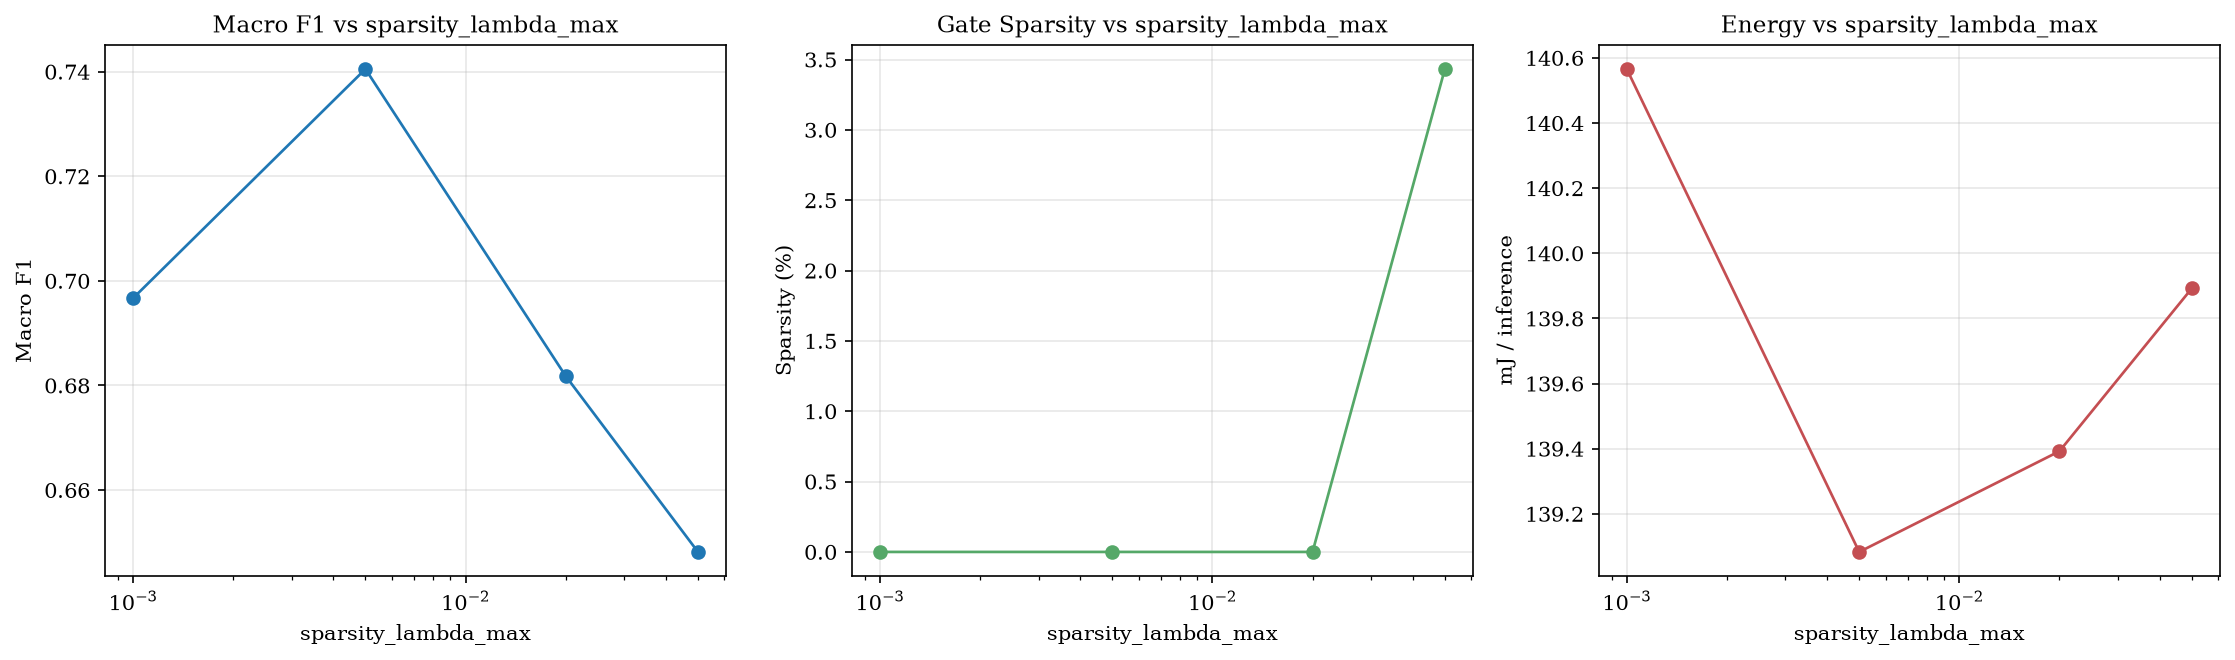

,sparsity_lambda_max,macro_f1,gate_sparsity_pct,energy_j_per_inference
0,0.001,0.696679,0.000000,0.140566
1,0.005,0.740509,0.000000,0.139083
2,0.020,0.681822,0.000000,0.139392
3,0.050,0.648174,3.432377,0.139892


In [38]:
# ===================================================================
# Module 8: Hyperparameter Sensitivity Analysis (sparsity_lambda_max sweep)
# Trains ASR-1D only (Dense/Static aren't affected by this hyperparameter), with a REDUCED
# epoch budget per point so the sweep finishes in reasonable time — this is for observing the
# TREND across values, not for producing final publication-grade single-point accuracy numbers.
# For the final reported ASR-1D result, use the full run in `results` (Section 11), not this sweep.
# ===================================================================
_sensitivity_lambdas = [1e-3, 5e-3, 2e-2, 5e-2]
_sensitivity_rows = []
_prepared_sens = prepare_pamap2(copy.deepcopy(CFG))
(_Xtr_s, _ytr_s), (_Xval_s, _yval_s), (_Xte_s, _yte_s), _label2idx_s, _idx2name_s = _prepared_sens
_input_shape_s = _Xtr_s.shape[1:]

for _lam in _sensitivity_lambdas:
    _cfg_s = copy.deepcopy(CFG)
    _cfg_s.sparsity_lambda_max = _lam
    _cfg_s.epochs = 25             # reduced from 60 — sweep needs the relative trend, not full convergence
    _cfg_s.early_stop_patience = 8
    print(f"\n--- Hyperparameter sensitivity: sparsity_lambda_max={_lam} ---")

    _train_ds_s = make_tf_dataset(_Xtr_s, _ytr_s, _cfg_s, training=True)
    _val_ds_s = make_tf_dataset(_Xval_s, _yval_s, _cfg_s, training=False)
    _model_s, _gates_s = build_asr1d_model(_input_shape_s, len(_label2idx_s), _cfg_s)
    compile_model(_model_s, _cfg_s)
    _model_s.fit(_train_ds_s, validation_data=_val_ds_s, epochs=_cfg_s.epochs,
                 class_weight=get_class_weights(_ytr_s),
                 callbacks=get_callbacks(_cfg_s, _gates_s, ckpt_path=f"sens_{_lam}.weights.h5"),
                 verbose=0)
    _res_s = evaluate_model(_model_s, _Xte_s, _yte_s, _idx2name_s)
    _sp_s = compute_gate_sparsity(_gates_s)
    _energy_s = measure_inference_energy(_model_s, _input_shape_s)
    _sensitivity_rows.append({
        "sparsity_lambda_max": _lam,
        "macro_f1": _res_s["macro_f1"],
        "gate_sparsity_pct": _sp_s["overall_sparsity"] * 100,
        "energy_j_per_inference": _energy_s["energy_j_per_inference"],
    })
    _mf1 = _res_s["macro_f1"]
    _gsp = _sp_s["overall_sparsity"] * 100
    print(f"  macro_f1={_mf1:.4f}  gate_sparsity={_gsp:.1f}%")

sensitivity_df = pd.DataFrame(_sensitivity_rows)
sensitivity_df.to_csv("./hyperparam_sensitivity.csv", index=False)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
axes[0].plot(sensitivity_df["sparsity_lambda_max"], sensitivity_df["macro_f1"], marker="o")
axes[0].set_xscale("log"); axes[0].set_title("Macro F1 vs sparsity_lambda_max")
axes[0].set_xlabel("sparsity_lambda_max"); axes[0].set_ylabel("Macro F1")

axes[1].plot(sensitivity_df["sparsity_lambda_max"], sensitivity_df["gate_sparsity_pct"], marker="o", color="#55A868")
axes[1].set_xscale("log"); axes[1].set_title("Gate Sparsity vs sparsity_lambda_max")
axes[1].set_xlabel("sparsity_lambda_max"); axes[1].set_ylabel("Sparsity (%)")

axes[2].plot(sensitivity_df["sparsity_lambda_max"], sensitivity_df["energy_j_per_inference"] * 1000,
             marker="o", color="#C44E52")
axes[2].set_xscale("log"); axes[2].set_title("Energy vs sparsity_lambda_max")
axes[2].set_xlabel("sparsity_lambda_max"); axes[2].set_ylabel("mJ / inference")

plt.tight_layout(); plt.savefig("./fig_hyperparam_sensitivity.png", bbox_inches="tight"); plt.show()
sensitivity_df


### 14.5 Module 7 — Statistical Analysis (retrains 3 seeds — slowest cell)

In [ ]:
# ===================================================================
# Module 7 (v2.1): Statistical Analysis — paired t-test, Wilcoxon, 95% CI, Cohen's d,
# now on 5 seeds (matching PTB-XL) with per-seed energy measurement and a locked decision
# gate at the end of this cell. This is the slowest cell in the notebook.
# ===================================================================
from scipy import stats

PAMAP2_SEEDS = [42, 123, 2024, 7, 99]   # v2.1: raised from [42, 123, 2024] to match PTB-XL's 5 seeds
print(f"Running multi-seed experiment for statistical significance testing ({len(PAMAP2_SEEDS)} seeds)...")
_prepared_stats = prepare_pamap2(copy.deepcopy(CFG))
multi_df, all_seed_results = run_multi_seed_experiment(PAMAP2_SEEDS, base_cfg=CFG,
                                                         prepared_data=_prepared_stats)

def paired_stats(a, b, name_a, name_b):
    a, b = np.asarray(a, dtype=float), np.asarray(b, dtype=float)
    t_stat, t_p = stats.ttest_rel(a, b)
    try:
        w_stat, w_p = stats.wilcoxon(a, b)
    except ValueError:
        w_stat, w_p = np.nan, np.nan
    diff = a - b
    if len(diff) > 1 and diff.std(ddof=1) > 0:
        ci_low, ci_high = stats.t.interval(0.95, len(diff) - 1, loc=diff.mean(), scale=stats.sem(diff))
    else:
        ci_low, ci_high = np.nan, np.nan
    pooled_std = np.sqrt((a.std(ddof=1) ** 2 + b.std(ddof=1) ** 2) / 2) if len(a) > 1 else np.nan
    cohens_d = diff.mean() / pooled_std if pooled_std and pooled_std > 0 else np.nan
    return {"Comparison": f"{name_a} vs {name_b}", "Mean diff": diff.mean(),
            "t-stat": t_stat, "t p-value": t_p, "Wilcoxon stat": w_stat, "Wilcoxon p-value": w_p,
            "95% CI low": ci_low, "95% CI high": ci_high, "Cohen's d": cohens_d}

statistical_tests_df = pd.DataFrame([
    paired_stats(multi_df["asr_macro_f1"], multi_df["dense_macro_f1"], "ASR-1D", "Dense"),
    paired_stats(multi_df["asr_macro_f1"], multi_df["static_macro_f1"], "ASR-1D", "Static"),
    paired_stats(multi_df["dense_macro_f1"], multi_df["static_macro_f1"], "Dense", "Static"),
])
statistical_tests_df.to_csv("./statistical_tests.csv", index=False)
print(f"\nNOTE: with {len(PAMAP2_SEEDS)} seeds these p-values / CIs are still modest-power -- "
      f"report them as indicative alongside the raw per-seed numbers, not as a substitute for them.")
statistical_tests_df

# ===================================================================
# v2.1 addition -- LOCKED DECISION GATE (mirrors the PTB-XL notebook's final decision gate, so
# both datasets in the thesis are held to the same confirmatory standard). The primary comparator
# is Static, because Static is pruned to the SAME target ratio the adaptive gate chose on
# validation -- it is the compute-matched baseline, exactly as on the PTB-XL side. The decision
# rule below is fixed before it is used to interpret any number.
# ===================================================================
PAMAP2_ACCURACY_MARGIN = 0.0      # ASR must beat Static on mean macro-F1 to pass (superiority)
PAMAP2_LATENCY_TOLERANCE = 1.10   # ASR batch-1 latency must be within 10% of Static's
PAMAP2_ENERGY_TOLERANCE = 1.10    # ASR energy/inference must be within 10% of Static's

_asr_f1 = multi_df["asr_macro_f1"].to_numpy(dtype=float)
_static_f1 = multi_df["static_macro_f1"].to_numpy(dtype=float)
_gate_accuracy = bool(_asr_f1.mean() > _static_f1.mean() + PAMAP2_ACCURACY_MARGIN)

_gate_latency = np.nan
_ratio_lat = np.nan
if "asr_latency_ms" in multi_df and "static_latency_ms" in multi_df:
    _ratio_lat = float(multi_df["asr_latency_ms"].mean() / multi_df["static_latency_ms"].mean())
    _gate_latency = bool(_ratio_lat <= PAMAP2_LATENCY_TOLERANCE)

_gate_energy = np.nan
_ratio_energy = np.nan
if "asr_energy_j_per_inference" in multi_df and "static_energy_j_per_inference" in multi_df:
    _ratio_energy = float(multi_df["asr_energy_j_per_inference"].mean() /
                           multi_df["static_energy_j_per_inference"].mean())
    _gate_energy = bool(_ratio_energy <= PAMAP2_ENERGY_TOLERANCE)

_n_flagged = int(multi_df["static_collapse_flag"].sum())

print("=" * 78)
print("PAMAP2 FINAL DECISION GATE")
print("=" * 78)
print(f"  Seeds                                  : {PAMAP2_SEEDS}")
print(f"  Static Pruning collapse-flagged seeds  : {_n_flagged}/{len(PAMAP2_SEEDS)}"
      + ("  <-- resolve before trusting the numbers below" if _n_flagged else ""))
print(f"  accuracy_superiority_vs_static          : {'PASS' if _gate_accuracy else 'FAIL'} "
      f"(mean ASR={_asr_f1.mean():.4f} vs mean Static={_static_f1.mean():.4f})")
if _gate_latency == _gate_latency:  # not NaN
    print(f"  latency_within_tolerance                : {'PASS' if _gate_latency else 'FAIL'} "
          f"(ratio={_ratio_lat:.3f}, tolerance={PAMAP2_LATENCY_TOLERANCE})")
if _gate_energy == _gate_energy:
    print(f"  energy_within_tolerance                 : {'PASS' if _gate_energy else 'FAIL'} "
          f"(ratio={_ratio_energy:.3f}, tolerance={PAMAP2_ENERGY_TOLERANCE})")
print("-" * 78)
if _gate_accuracy and (_gate_latency in (True, np.nan)) and (_gate_energy in (True, np.nan)) and not _n_flagged:
    print("Overall: evidence supports describing ASR-1D as beneficial on PAMAP2 under this protocol.")
else:
    print("Overall: do NOT describe ASR-1D as a successful efficiency win on PAMAP2 from this run.")
    print("Report it the same way as the PTB-XL result: conditional computation is implemented and")
    print("measured, but a practical accuracy/latency/energy advantage over the compute-matched")
    print("Static baseline is not established here. State that plainly in Chapters 4-6.")
print("=" * 78)

decision_pamap2 = {
    "seeds": PAMAP2_SEEDS,
    "static_collapse_flagged_seeds": _n_flagged,
    "accuracy_superiority_vs_static": _gate_accuracy,
    "latency_within_tolerance": (_gate_latency if _gate_latency == _gate_latency else None),
    "energy_within_tolerance": (_gate_energy if _gate_energy == _gate_energy else None),
}
with open("./pamap2_final_decision.json", "w") as _f:
    json.dump(decision_pamap2, _f, indent=2, default=str)
print("Saved: pamap2_final_decision.json")


Running multi-seed experiment for statistical significance testing (5 seeds)...
Found existing PAMAP2 data at ./pamap2_raw/PAMAP2_Dataset/Protocol, using it directly.
Loading raw subject files...
Subject files found: [101, 102, 103, 104, 105, 106, 107, 108, 109]
Raw rows: 2,872,533  subjects: 9
After cleaning: 1,921,431 rows
Windows built: (19082, 200, 40)
Window counts per raw activity_id before filtering:
  activity_id= 17 (ironing           ):   2370 windows
  activity_id=  4 (walking           ):   2287 windows
  activity_id=  1 (lying             ):   1914 windows
  activity_id=  3 (standing          ):   1880 windows
  activity_id=  2 (sitting           ):   1836 windows
  activity_id=  7 (nordic_walking    ):   1836 windows
  activity_id= 16 (vacuum_cleaning   ):   1741 windows
  activity_id=  6 (cycling           ):   1624 windows
  activity_id= 12 (ascending_stairs  ):   1151 windows
  activity_id= 13 (descending_stairs ):   1028 windows
  activity_id=  5 (running           ):

/home/uswa/Downloads/Uswa/envs/pamap2/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
I0000 00:00:1788524153.116828  201716 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2417149__.349
I0000 00:00:1788524165.330931  201711 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2417149__.349


71/71 - 40s - 569ms/step - acc: 0.6067 - loss: 1.1576 - val_acc: 0.0936 - val_loss: 2.6692 - learning_rate: 0.0010
Epoch 2/60
71/71 - 1s - 16ms/step - acc: 0.8734 - loss: 0.4353 - val_acc: 0.0954 - val_loss: 2.6124 - learning_rate: 0.0010
Epoch 3/60
71/71 - 1s - 15ms/step - acc: 0.9106 - loss: 0.3128 - val_acc: 0.4324 - val_loss: 2.1646 - learning_rate: 0.0010
Epoch 4/60
71/71 - 1s - 16ms/step - acc: 0.9276 - loss: 0.2673 - val_acc: 0.5980 - val_loss: 1.5861 - learning_rate: 0.0010
Epoch 5/60
71/71 - 1s - 16ms/step - acc: 0.9377 - loss: 0.2442 - val_acc: 0.6297 - val_loss: 1.8300 - learning_rate: 0.0010
Epoch 6/60
71/71 - 1s - 11ms/step - acc: 0.9414 - loss: 0.2428 - val_acc: 0.6099 - val_loss: 2.1022 - learning_rate: 0.0010
Epoch 7/60
71/71 - 1s - 10ms/step - acc: 0.9478 - loss: 0.2386 - val_acc: 0.6280 - val_loss: 1.9591 - learning_rate: 0.0010
Epoch 8/60

Epoch 8: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
71/71 - 1s - 15ms/step - acc: 0.9519 - loss: 0.2338 -

/home/uswa/Downloads/Uswa/envs/pamap2/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
I0000 00:00:1788524224.758172  201715 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2479791__.349
I0000 00:00:1788524236.674880  201714 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2479791__.349


target=10% actual=6.7% val_acc=0.6648 val_macro_f1=0.6394


...

target=40% actual=36.7% val_acc=0.6586 val_macro_f1=0.6272


/home/uswa/Downloads/Uswa/envs/pamap2/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
I0000 00:00:1788526345.207189  201716 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_6853918__.349
I0000 00:00:1788526356.834476  201711 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_6853918__.349


target=50% actual=50.0% val_acc=0.6321 val_macro_f1=0.5886
Selected on VALIDATION only: target=40%, actual=36.7%, val_F1=0.6272
Macro F1: 0.7992
                   precision    recall  f1-score   support

            lying      0.991     0.983     0.987       468
          sitting      0.885     0.933     0.908       493
         standing      0.919     0.370     0.527       460
          walking      0.689     0.962     0.803       557
          running      1.000     0.778     0.875       463
          cycling      0.975     0.783     0.868       446
   nordic_walking      0.958     0.485     0.644       522
 ascending_stairs      0.641     0.948     0.765       271
descending_stairs      0.594     0.884     0.710       233
  vacuum_cleaning      0.797     0.847     0.822       451
          ironing      0.745     0.983     0.848       702
     rope_jumping      0.948     0.743     0.833        74

         accuracy                          0.813      5140
        macro avg      0.84

/home/uswa/Downloads/Uswa/envs/pamap2/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
I0000 00:00:1788526417.483352  201716 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_7143364__.280
I0000 00:00:1788526427.816189  201711 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_7143364__.280


71/71 - 33s - 465ms/step - acc: 0.4298 - loss: 1.5727 - val_acc: 0.1664 - val_loss: 2.7752 - learning_rate: 0.0010
Epoch 2/60
71/71 - 1s - 14ms/step - acc: 0.7235 - loss: 0.7644 - val_acc: 0.3525 - val_loss: 2.7987 - learning_rate: 0.0010
Epoch 3/60
71/71 - 1s - 13ms/step - acc: 0.8510 - loss: 0.4875 - val_acc: 0.5912 - val_loss: 1.6742 - learning_rate: 0.0010
Epoch 4/60
71/71 - 1s - 10ms/step - acc: 0.9076 - loss: 0.3250 - val_acc: 0.5116 - val_loss: 2.4051 - learning_rate: 0.0010
Epoch 5/60
71/71 - 1s - 9ms/step - acc: 0.9269 - loss: 0.2502 - val_acc: 0.5462 - val_loss: 2.0982 - learning_rate: 0.0010
Epoch 6/60
71/71 - 1s - 10ms/step - acc: 0.9331 - loss: 0.2167 - val_acc: 0.5421 - val_loss: 2.5397 - learning_rate: 0.0010
Epoch 7/60

Epoch 7: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
71/71 - 1s - 10ms/step - acc: 0.9420 - loss: 0.1926 - val_acc: 0.5667 - val_loss: 2.7887 - learning_rate: 0.0010
Epoch 8/60
71/71 - 1s - 9ms/step - acc: 0.9514 - loss: 0.1561 - v

### 14.6 Module 11 — Consolidated Results Export

In [ ]:
# ===================================================================
# Module 11: Consolidated Results Export
# ===================================================================
_metrics_rows = []
_all_named_results = [("ASR-1D (masked)", results["asr_results"]),
                       ("Dense Baseline", results["dense_results"]),
                       ("Static Pruning", results["static_results"])]
if results["deploy_results"] is not None:
    _all_named_results.append(("ASR-1D (physical)", results["deploy_results"]))

for name, res in _all_named_results:
    m = res["report_dict"]["macro avg"]
    _metrics_rows.append({"Model": name, "Macro F1": res["macro_f1"],
                           "Macro Precision": m["precision"], "Macro Recall": m["recall"],
                           "Accuracy": res["report_dict"]["accuracy"]})
pd.DataFrame(_metrics_rows).to_csv("./metrics.csv", index=False)

memory_metrics_df = energy_memory_df[["Model", "peak_gpu_mem_mb", "avg_gpu_mem_mb", "cpu_ram_mb"]]
memory_metrics_df.to_csv("./memory_metrics.csv", index=False)

summary_df.to_csv("./summary_results.csv", index=False)

print("Exported CSVs:")
import glob
for f in sorted(glob.glob("./*.csv")):
    print(" -", f)

print("\nExported figures:")
for f in sorted(glob.glob("./fig_*.png")):
    print(" -", f)
